# Training Diffusion Head Explainer

The goal of this notebook is to continue our protein folding walkthrough but focus on how the diffusion head converts the embedded protein representation into a training loss and, during inference, the actual predicted protein structure. In [3a_train_foldingcore.ipynb](3a_train_foldingcore.ipynb) we showed how the cached data is processed through the input embedding layers, converted to pairwise representations and cycled through the recycling trunk. We also walked through the distogram head which classifies residue distances into different distance categories. In this notebook we'll start from there and show how those representations are used by the denoiser to generate predicted atom coordinates and how we use those coordinates to calculate loss for training. Diffusion is typically a multi-step process, but we'll show one denoising pass and then show how that same pass becomes one inference sampling step. The predicted coordinates and folding-core features continue into the confidence head in [3c_train_confidencehead.ipynb](3c_train_confidencehead.ipynb).

For this notebook, we'll load in the same two examples we used in the 3a notebook. The atom inputs come from the real cache, while the upstream folding-core outputs are mocked so we can keep the focus on the diffusion head. Note that while the dimensions will match what's shown in the 3a notebook, the upstream values will differ because we're generating mock data for those already-covered representations.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import math

from model.protein_folding import ATOM_SLOTS, ATOM_ELEMENT_VOCAB_SIZE, ATOM_NAME_CHAR_VOCAB_SIZE

In [2]:
seed = 1337
torch.manual_seed(seed)

## Diffusion Data Prep

The data prep section will be a bit different for this notebook as we have to stage the data as if it has just completed the recycling trunk and distogram head. On top of those representations, part of the data that the diffusion head uses is directly processed from the cached data, so we'll do a combination of steps for data prep. We'll first start by loading from the data cache our two examples again, the same ones we used in the 3a notebook. After that we'll walk through mocking up the different embedding representations that the diffusion head would get from the first parts of the protein folding model. For the mocked data, you'll notice that the actual numerical values differ from the 3a notebook but the shapes will be the same.

### Select a Small Batch

We'll start with the data loading and batch selection. This is the same style as used in notebook 3a so we'll go through it in a more compact pattern.

In [3]:
data_root = Path('~/data/protein_folding').expanduser()
shard_root = data_root / 'tokenized'
shard_path = sorted((shard_root / 'train').glob('*.npz'))[0]
shard = np.load(shard_path, allow_pickle=False)
shard_path.name, shard.files

('protein_folding_train_000000.npz',
 ['input_ids',
  'res_type',
  'atom_coords',
  'atom_mask',
  'reference_atom_coords',
  'reference_atom_mask',
  'atom_to_token',
  'atom_element',
  'atom_charge',
  'atom_name_chars',
  'atom_occupancy',
  'atom_altloc',
  'residue_atom_bonds',
  'peptide_bond_mask',
  'token_bonds',
  'ref_space_uid',
  'residue_index',
  'token_index',
  'asym_id',
  'sym_id',
  'entity_id',
  'mol_type',
  'label_seq_ids',
  'residue_mask',
  'lengths'])

In [4]:
batch_size = 2
context_size = 30
atom_slot_count = len(ATOM_SLOTS)
flat_atom_count = context_size * atom_slot_count

batch_size, context_size, atom_slot_count, flat_atom_count

(2, 30, 37, 1110)

In [5]:
residue_mask = torch.tensor(shard['residue_mask'][:batch_size, :context_size], dtype=torch.bool)
atom_coords_slots = torch.tensor(shard['atom_coords'][:batch_size, :context_size], dtype=torch.float32)
atom_mask_slots = torch.tensor(shard['atom_mask'][:batch_size, :context_size], dtype=torch.bool)
reference_atom_coords_slots = torch.tensor(shard['reference_atom_coords'][:batch_size, :context_size], dtype=torch.float32)
reference_atom_mask_slots = torch.tensor(shard['reference_atom_mask'][:batch_size, :context_size], dtype=torch.bool)
atom_to_token_slots = torch.tensor(shard['atom_to_token'][:batch_size, :context_size], dtype=torch.long)
atom_element_slots = torch.tensor(shard['atom_element'][:batch_size, :context_size], dtype=torch.long)
atom_charge_slots = torch.tensor(shard['atom_charge'][:batch_size, :context_size], dtype=torch.float32)
atom_name_chars_slots = torch.tensor(shard['atom_name_chars'][:batch_size, :context_size], dtype=torch.long)
ref_space_uid_slots = torch.tensor(shard['ref_space_uid'][:batch_size, :context_size], dtype=torch.long)
residue_atom_bonds = torch.tensor(shard['residue_atom_bonds'][:batch_size, :context_size], dtype=torch.bool)
peptide_bond_mask = torch.tensor(shard['peptide_bond_mask'][:batch_size, :context_size], dtype=torch.bool)
shard.close()

**Flatten Atom Fields**

The diffusion head uses the flattened atom-token interface. This is the same reshaping we did in 3a that turns the cached `[batch, residue, atom_slot, ...]` fields into `[batch, atom, ...]` fields.

In [6]:
ref_pos = reference_atom_coords_slots.reshape(batch_size, flat_atom_count, 3)
target_atom_coords = atom_coords_slots.reshape(batch_size, flat_atom_count, 3)
atom_attention_mask = reference_atom_mask_slots.reshape(batch_size, flat_atom_count)
atom_to_token = atom_to_token_slots.reshape(batch_size, flat_atom_count)
ref_space_uid = ref_space_uid_slots.reshape(batch_size, flat_atom_count)
atom_element = atom_element_slots.reshape(batch_size, flat_atom_count)
atom_charge = atom_charge_slots.reshape(batch_size, flat_atom_count)
atom_name_chars = atom_name_chars_slots.reshape(batch_size, flat_atom_count, atom_name_chars_slots.size(-1))

atom_attention_mask = atom_attention_mask & (atom_to_token >= 0)
coordinate_atom_mask = atom_mask_slots.reshape(batch_size, flat_atom_count) & atom_attention_mask
safe_atom_to_token = torch.where(atom_attention_mask, atom_to_token.clamp_min(0), torch.zeros_like(atom_to_token))
valid_atom_to_token = torch.where(atom_attention_mask, atom_to_token.clamp_min(0), torch.full_like(atom_to_token, context_size))
token_attention_mask = residue_mask

**Atom Bonds and Attention Mask**

Our last input processing we'll redo from the 3a notebook is to build out our attention masks and residue level atom bonds. These become particularly important for structure prediction. 

In [7]:
atom_bonds = torch.zeros(batch_size, flat_atom_count, flat_atom_count, dtype=torch.bool)
for residue_position in range(context_size):
    atom_start = residue_position * atom_slot_count
    atom_end = atom_start + atom_slot_count
    residue_reference_mask = reference_atom_mask_slots[:, residue_position]
    residue_bonds = residue_atom_bonds[:, residue_position]
    residue_bonds = residue_bonds & residue_reference_mask[:, :, None] & residue_reference_mask[:, None, :]
    atom_bonds[:, atom_start:atom_end, atom_start:atom_end] = residue_bonds

c_index = ATOM_SLOTS.index('C')
n_index = ATOM_SLOTS.index('N')
for residue_position in range(context_size - 1):
    atom_a = residue_position * atom_slot_count + c_index
    atom_b = (residue_position + 1) * atom_slot_count + n_index
    valid_peptide_bond = (
        peptide_bond_mask[:, residue_position]
        & reference_atom_mask_slots[:, residue_position, c_index]
        & reference_atom_mask_slots[:, residue_position + 1, n_index]
    )
    atom_bonds[:, atom_a, atom_b] = valid_peptide_bond
    atom_bonds[:, atom_b, atom_a] = valid_peptide_bond

atom_bonds.shape

torch.Size([2, 1110, 1110])

In [8]:
batch, attention_atom_count = ref_pos.shape[:2]
atom_window_size = 32
atom_positions = torch.arange(attention_atom_count)
local_window = (atom_positions[:, None] - atom_positions[None, :]).abs() <= atom_window_size
same_reference_space = ref_space_uid[:, :, None] == ref_space_uid[:, None, :]
key_mask = atom_attention_mask[:, None, None, :]
query_mask = atom_attention_mask[:, None, :, None]
attention_mask = (local_window[None, None] | atom_bonds[:, None])
attention_mask = attention_mask & (same_reference_space[:, None] | atom_bonds[:, None]) & key_mask

attention_mask.shape, query_mask.shape

(torch.Size([2, 1, 1110, 1110]), torch.Size([2, 1, 1110, 1]))

### Mock Upstream Folding-Core Outputs

Now that we have the file cache values reloaded and processed we'll skip forward to creating the mock data that we'd have at the end of the 3a notebook. The first portion will be the embeddings we would have at the end of the folding core, which is mainly the input embedding and then the recycling trunk. For the diffusion steps, along with setting up some of the same constants/configurations, the variables we will stage from the folding core are: 
* `x_inputs`: the per-residue input features generated by InputsEmbedder
* `pair`: recycled residue-pair representation from the recycling trunk
* `relative_position_features`: pairwise metadata encoding for residue/token/chain relationships generated by the PairEmbedder

In [9]:
res_type_vocab_size = 33
profile_dim = res_type_vocab_size
deletion_dim = 1
atom_dim = 8
pair_dim = 8

inputs_dim = atom_dim + res_type_vocab_size + profile_dim + deletion_dim
pair_mask = (token_attention_mask[:, :, None] & token_attention_mask[:, None, :]).unsqueeze(-1)


inputs_dim, pair_mask.shape, pair_mask

(75,
 torch.Size([2, 30, 30, 1]),
 tensor([[[[ True],
           [ True],
           [ True],
           ...,
           [False],
           [False],
           [False]],
 
          [[ True],
           [ True],
           [ True],
           ...,
           [False],
           [False],
           [False]],
 
          [[ True],
           [ True],
           [ True],
           ...,
           [False],
           [False],
           [False]],
 
          ...,
 
          [[False],
           [False],
           [False],
           ...,
           [False],
           [False],
           [False]],
 
          [[False],
           [False],
           [False],
           ...,
           [False],
           [False],
           [False]],
 
          [[False],
           [False],
           [False],
           ...,
           [False],
           [False],
           [False]]],
 
 
         [[[ True],
           [ True],
           [ True],
           ...,
           [ True],
           [ Tru

In [10]:
x_inputs = torch.randn(batch_size, context_size, inputs_dim) * token_attention_mask.unsqueeze(-1)
x_inputs.shape, x_inputs

(torch.Size([2, 30, 75]),
 tensor([[[ 0.1808, -0.0700, -0.3596,  ...,  2.0089, -0.5370,  0.2228],
          [ 0.6971, -1.4267,  0.9059,  ..., -0.2912, -0.1140, -0.3137],
          [-0.6293,  1.1385, -0.9913,  ..., -0.5556, -0.3983, -0.5819],
          ...,
          [-0.0000, -0.0000, -0.0000,  ...,  0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000],
          [ 0.0000, -0.0000, -0.0000,  ..., -0.0000,  0.0000, -0.0000]],
 
         [[ 1.6110,  0.5486, -2.8114,  ..., -0.3942, -0.0968,  1.3060],
          [-1.2617, -0.0670,  0.2999,  ..., -0.2258, -0.9918, -1.0729],
          [-0.2498, -0.8868,  1.5427,  ...,  1.4538, -2.2956, -1.6489],
          ...,
          [-0.1257,  0.0723, -0.2567,  ...,  0.9110, -0.2684,  2.1700],
          [ 0.1898,  1.2052, -0.5015,  ...,  0.6370, -2.0427, -0.8035],
          [ 0.5114, -1.6066,  1.3145,  ..., -0.1013,  0.0042, -0.3833]]]))

In [11]:
pair = torch.randn(batch_size, context_size, context_size, pair_dim) * pair_mask
pair.shape, pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.4528, -1.2867, -1.6834,  ...,  0.7593, -0.0086,  0.4140],
           [-0.3730,  2.1957, -0.4740,  ...,  0.2775, -0.3522,  0.5804],
           [ 2.2615,  1.2927,  0.7182,  ..., -0.4434,  0.1041,  0.0389],
           ...,
           [ 0.0000, -0.0000, -0.0000,  ..., -0.0000,  0.0000,  0.0000],
           [ 0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000],
           [ 0.0000, -0.0000, -0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-2.3678,  1.2966, -0.4768,  ...,  0.4563, -0.3216,  1.5098],
           [-0.6557, -0.0333, -0.1869,  ..., -0.2232, -0.1270,  0.1994],
           [ 1.1425, -1.9429, -0.7968,  ..., -0.0658,  1.2351, -0.6777],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ..., -0.0000, -0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
           [-0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.0000, -0.0000]],
 
          [[ 0.2660, -1.7164, -0.2632,  ...,  1.8925, -0.

In [12]:
relative_position_features = torch.randn(batch_size, context_size, context_size, pair_dim) * pair_mask
relative_position_features.shape, relative_position_features

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 0.0296, -0.3462,  0.9152,  ..., -0.5038, -0.0654,  0.0264],
           [-0.7482,  0.5345, -1.5790,  ...,  0.7398, -0.2553, -0.3909],
           [-0.4828,  0.0338, -0.1034,  ..., -1.4367,  0.2124,  0.2744],
           ...,
           [ 0.0000, -0.0000,  0.0000,  ..., -0.0000, -0.0000,  0.0000],
           [-0.0000,  0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000],
           [-0.0000, -0.0000,  0.0000,  ..., -0.0000,  0.0000,  0.0000]],
 
          [[ 2.5722,  2.0417, -0.5606,  ...,  1.2111, -1.7337,  1.4323],
           [ 1.0560,  1.1014, -0.5471,  ..., -1.1967,  0.9398,  1.1150],
           [ 0.6226, -0.2834,  0.0685,  ..., -0.2707, -0.1909, -1.8992],
           ...,
           [ 0.0000, -0.0000, -0.0000,  ...,  0.0000,  0.0000, -0.0000],
           [ 0.0000, -0.0000, -0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.0000, -0.0000]],
 
          [[ 1.2007, -0.5920, -0.2890,  ...,  2.2516, -0.

### Representative Distances for Pair Losses

The final part of our data prep is to set up our residue-level distances, related variables, and distogram loss. The calculations for the distance values were shown in the distogram loss calculation section so we'll just quickly recalculate them. After that we'll simulate the distogram loss with a fixed value similar to what the 3a notebook shows. The distance variables will end up being used as we walk through the notebook.

In [13]:
positions = torch.arange(context_size).view(1, context_size).expand(batch_size, context_size)
cb_index = ATOM_SLOTS.index('CB')
ca_index = ATOM_SLOTS.index('CA')
first_valid_atom = reference_atom_mask_slots.float().argmax(dim=-1)
cb_atom_idx = positions * atom_slot_count + cb_index
ca_atom_idx = positions * atom_slot_count + ca_index
distogram_atom_idx = torch.where(
    reference_atom_mask_slots[:, :, cb_index],
    cb_atom_idx,
    torch.where(reference_atom_mask_slots[:, :, ca_index], ca_atom_idx, positions * atom_slot_count + first_valid_atom),
)

rep_atom_gather_index = distogram_atom_idx.clamp_min(0)[..., None].expand(batch_size, context_size, 3)
representative_coords = target_atom_coords.gather(dim=1, index=rep_atom_gather_index)
rep_atom_mask = coordinate_atom_mask.gather(dim=1, index=distogram_atom_idx.clamp_min(0)) & token_attention_mask

rep_deltas = representative_coords[:, :, None, :] - representative_coords[:, None, :, :]
distance_squared = (rep_deltas * rep_deltas).sum(dim=-1)
true_distances = torch.sqrt(distance_squared.clamp_min(0.0) + 1e-8)
distogram_pair_mask = rep_atom_mask[:, :, None] & rep_atom_mask[:, None, :]
diagonal_mask = torch.eye(context_size, dtype=torch.bool).unsqueeze(0)
distogram_pair_mask = distogram_pair_mask & ~diagonal_mask

true_distances.shape, distogram_pair_mask.shape

(torch.Size([2, 30, 30]), torch.Size([2, 30, 30]))

In [14]:
distogram_loss = torch.tensor(2.4)
distogram_loss

tensor(2.4000)

## Atom Centering
<img src="explainer_screenshots/3b_diffusionhead/inputmerge_edmscale.png" width="500">

Before we can start diffusion training, we want to center our target coordinates and generate noise per example. We center the target coordinates so the model learns the protein’s shape instead of its arbitrary position in space. Then we add noise per example so the denoiser can learn how to recover clean coordinates from different corruption levels.

### Center target coordinates

We'll start by focusing on the target coordinates that we've extracted from our file. We'll need to include our coordinate mask so that we only focus on the resolved coordinates and center that set.

To center the targets, we take the sum of the atom positions divided by the atom count to get the average coordinate, or centroid, of the valid atoms. Then we subtract that centroid from every coordinate so the structure is centered around zero. We calculate the following:

$$\mu=\frac{\sum_i m_i x_i}{\sum_i m_i}$$

$$x_i^{centered}=m_i(x_i-\mu)$$

In [15]:
target_center_mask = coordinate_atom_mask.to(target_atom_coords.dtype).unsqueeze(-1)
target_center_mask.shape, target_center_mask

(torch.Size([2, 1110, 1]),
 tensor([[[1.],
          [1.],
          [1.],
          ...,
          [0.],
          [0.],
          [0.]],
 
         [[1.],
          [1.],
          [1.],
          ...,
          [0.],
          [0.],
          [0.]]]))

In [16]:
target_center = (target_atom_coords * target_center_mask).sum(dim=1, keepdim=True)
target_center.shape, target_center

(torch.Size([2, 1, 3]),
 tensor([[[  971.9611,  1035.7631, -7366.8330]],
 
         [[ 5364.5801,  9217.8652,  6272.8457]]]))

In [17]:
target_total_atoms = target_center_mask.sum(dim=1, keepdim=True).clamp_min(1.0)
target_total_atoms.shape, target_total_atoms

(torch.Size([2, 1, 1]),
 tensor([[[218.]],
 
         [[239.]]]))

In [18]:
target_center = target_center / target_total_atoms
target_center.shape, target_center

(torch.Size([2, 1, 3]),
 tensor([[[  4.4585,   4.7512, -33.7928]],
 
         [[ 22.4459,  38.5685,  26.2462]]]))

In [19]:
centered_target = (target_atom_coords - target_center) * target_center_mask
centered_target.shape, centered_target

(torch.Size([2, 1110, 3]),
 tensor([[[15.4715,  4.6908,  3.3178],
          [16.0345,  3.3448,  3.0798],
          [15.1015,  2.2098,  3.5078],
          ...,
          [-0.0000, -0.0000,  0.0000],
          [-0.0000, -0.0000,  0.0000],
          [-0.0000, -0.0000,  0.0000]],
 
         [[ 6.7871, -5.4255,  7.9648],
          [ 7.3431, -4.2545,  7.2378],
          [ 6.2131, -3.2525,  6.9668],
          ...,
          [-0.0000, -0.0000, -0.0000],
          [-0.0000, -0.0000, -0.0000],
          [-0.0000,  0.0000,  0.0000]]]))

### Generate Log-Uniform Noise

Our next step is to generate a log-uniform noise specific to each example. This will also tell the denoiser how corrupted the coordinates are, so the same model can learn different behavior for easy low-noise cleanup versus hard high-noise structure recovery. Recall that in diffusion we run a number of steps to turn noise into a structure based on the input. So in the first few diffusion steps, the coordinates will be basically noise, but in the last few steps they'll be almost fully resolved. The model has to learn what to do in each of these steps, and sigma is how we can train a single model to see all these different levels of corruption. 

In [20]:
sigma_min = 0.1
sigma_max = 20.0
sigma_data = 10.0

In [21]:
uniform = torch.rand(batch_size)
sigma = torch.exp(math.log(sigma_min) + uniform * (math.log(sigma_max) - math.log(sigma_min)))
sigma.shape, sigma

(torch.Size([2]), tensor([ 0.4641, 10.7861]))

### Create centered noise

Now our final component to degrade our targets is a centered noise cloud. We center it based on the flattened atom space, same as centered targets, since the denoiser operates over every reference atom row that exists, even if a coordinate is not in the target space. We'll generate the noise then use the same centering technique we use for the targets with the difference being that we focus on the atom_attention_mask since we want to consider every real residue linked position, not just the ones that are in the target. 

Since we will do so many centerings we'll go ahead and define a function that takes coordinates, takes a mask representation, and returns the centered coordinates. 

In [22]:
noise_init = torch.randn_like(centered_target)
noise = noise_init
noise.shape, noise

(torch.Size([2, 1110, 3]),
 tensor([[[ 1.3497, -0.3459,  0.4090],
          [ 1.2566,  0.4373,  0.9686],
          [-0.3237, -1.1570, -0.1615],
          ...,
          [ 1.6077, -0.4068, -0.0754],
          [ 0.1549, -0.2741,  0.3495],
          [-2.0179,  0.8433,  0.8810]],
 
         [[ 1.0754, -0.8270, -1.0494],
          [-1.0048,  1.4029, -0.1275],
          [ 0.5801, -0.2772,  0.9855],
          ...,
          [ 0.1789,  0.0620, -0.0861],
          [-0.6035, -0.5566,  1.0187],
          [-0.4013,  1.6301,  0.4988]]]))

In [23]:
def masked_center(coords, coord_mask):
    coordinate_values = coord_mask.to(dtype=coords.dtype)[..., None]
    center_dims = tuple(range(1, coords.ndim - 1))
    coordinate_count = coordinate_values.sum(
        dim=center_dims,
        keepdim=True,
    ).clamp_min(1.0)
    coordinate_center = (
        coords * coordinate_values
    ).sum(dim=center_dims, keepdim=True) / coordinate_count
    return (coords - coordinate_center) * coordinate_values

In [24]:
noise = masked_center(noise_init, atom_attention_mask)
noise.shape, noise

(torch.Size([2, 1110, 3]),
 tensor([[[ 1.3187, -0.2905,  0.3507],
          [ 1.2257,  0.4927,  0.9103],
          [-0.3546, -1.1016, -0.2198],
          ...,
          [ 0.0000, -0.0000, -0.0000],
          [ 0.0000, -0.0000,  0.0000],
          [-0.0000,  0.0000,  0.0000]],
 
         [[ 1.1526, -0.8409, -0.9714],
          [-0.9277,  1.3890, -0.0495],
          [ 0.6572, -0.2912,  1.0635],
          ...,
          [ 0.0000,  0.0000, -0.0000],
          [-0.0000, -0.0000,  0.0000],
          [-0.0000,  0.0000,  0.0000]]]))

### Create our noisy/corrupted target

Now that we have our target centered, noise that's been centered, and a level of corruption for each example, we're ready to create our corrupted targets. We do this by taking the noise, multiplying it by the corruption, and adding it to our targets. For training, this gives us one noisy target per batch. For inference, we start from noisy coordinates and then repeatedly update them through the denoiser and sampler steps. 

In [25]:
noisy_atom_coords = centered_target + sigma[:, None, None] * noise
noisy_atom_coords.shape, noisy_atom_coords

(torch.Size([2, 1110, 3]),
 tensor([[[ 16.0834,   4.5560,   3.4806],
          [ 16.6032,   3.5734,   3.5023],
          [ 14.9369,   1.6986,   3.4058],
          ...,
          [  0.0000,  -0.0000,   0.0000],
          [  0.0000,  -0.0000,   0.0000],
          [ -0.0000,   0.0000,   0.0000]],
 
         [[ 19.2186, -14.4958,  -2.5132],
          [ -2.6632,  10.7273,   6.7037],
          [ 13.3020,  -6.3929,  18.4380],
          ...,
          [  0.0000,   0.0000,  -0.0000],
          [ -0.0000,  -0.0000,   0.0000],
          [ -0.0000,   0.0000,   0.0000]]]))

## Structure Denoiser `StructureDenoiser`

Now we're ready for the structure denoiser. The folding core gave us `x_inputs`, the recycled `pair`, and `relative_position_features`. We'll combine those with noisy atom coordinates and the current noise level so the model can predict a cleaner set of atom coordinates.

At a high level, each denoiser pass conditions the residue and pair streams on the noise level. Then it encodes the noisy atom coordinates, scatters atom information back to residue tokens, lets those residue tokens exchange information through pair-biased transformer blocks, and gathers the updates back to atoms to predict a coordinate update. During inference, this same pass is repeated multiple times until a target noise level is reached. 

### EDM Scaling `edm_scaling`
<img src="explainer_screenshots/3b_diffusionhead/inputmerge_edmscale.png" width="500">

The denoiser uses Elucidated Diffusion Model (EDM)-style skip and output scaling. In practice this means the denoiser does not just predict coordinates directly from raw noisy coordinates. It uses `sigma` to calculate input, skip, and output scales, so the model gets numerically stable inputs and the final prediction blends $(\text{skip scale} \cdot \text{noisy coords}) + (\text{output scale} \cdot \text{learned update})$. So `EDM-style scaling` means noise-aware scaling around the denoiser. The scale is static, dependent on `sigma`, so it is not learnable.

We'll first calculate the scalers, then apply the scaling to our noisy atom coordinates.

In [26]:
denominator = torch.sqrt(sigma * sigma + sigma_data * sigma_data)
input_scale = 1.0 / denominator
input_scale

tensor([0.0999, 0.0680])

In [27]:
skip_scale = (sigma_data * sigma_data) / (sigma * sigma + sigma_data * sigma_data)
skip_scale

tensor([0.9979, 0.4622])

In [28]:
output_scale = sigma * sigma_data / denominator
output_scale

tensor([0.4636, 7.3332])

### Scale & Center Inputs

Now that we have our scalers, we can apply the input scale to our noisy atom coordinates. We do this via a simple multiplication and then recentering of the coordinates. For the centering, we'll use the same `masked_center` function we previously created as the calculation is done the same way.

In [29]:
noisy_scaled = input_scale[:, None, None] * noisy_atom_coords
noisy_scaled.shape, noisy_scaled

(torch.Size([2, 1110, 3]),
 tensor([[[ 1.6066,  0.4551,  0.3477],
          [ 1.6585,  0.3570,  0.3498],
          [ 1.4921,  0.1697,  0.3402],
          ...,
          [ 0.0000, -0.0000,  0.0000],
          [ 0.0000, -0.0000,  0.0000],
          [-0.0000,  0.0000,  0.0000]],
 
         [[ 1.3066, -0.9855, -0.1709],
          [-0.1811,  0.7293,  0.4558],
          [ 0.9044, -0.4346,  1.2536],
          ...,
          [ 0.0000,  0.0000, -0.0000],
          [-0.0000, -0.0000,  0.0000],
          [-0.0000,  0.0000,  0.0000]]]))

In [30]:
noisy_scaled = masked_center(noisy_scaled, atom_attention_mask)
noisy_scaled.shape, noisy_scaled

(torch.Size([2, 1110, 3]),
 tensor([[[ 1.6066,  0.4551,  0.3477],
          [ 1.6585,  0.3570,  0.3498],
          [ 1.4921,  0.1697,  0.3402],
          ...,
          [ 0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000]],
 
         [[ 1.3066, -0.9855, -0.1709],
          [-0.1811,  0.7293,  0.4558],
          [ 0.9044, -0.4346,  1.2536],
          ...,
          [ 0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000]]]))

### Diffusion Conditioning `DiffusionConditioning`
<img src="explainer_screenshots/3b_diffusionhead/diffusionconditioning.png" width="300">


Now that we have our noise scaled, we need to reshape the folding-core features into the dimensions the denoiser uses. We turn the current noise level into an embedding, then add it to the residue features so each residue carries information about how corrupted this example is. For the pair side, we concatenate the recycled pair representation with the relative-position features so the denoiser sees both learned residue relationships and the original sequence/metadata relationships. After that, small MLP layers clean up both streams before they go into the atom encoder and token transformer.

#### Noise Embedding

Our first step will be to create an embedding representation of the noise. Since `sigma` can span a wide range, we first work in log space so equal steps represent multiplicative changes in noise instead of raw additive changes initialized as $t=\log(\sigma)$. Then we create sinusoidal features at different frequencies so the model has a richer way to recognize both small and large noise levels as $e(t)=\left[\sin(t f_1),\cos(t f_1),\ldots,\sin(t f_k),\cos(t f_k)\right]$. Finally, we pass those features through a learned MLP projection. This turns the fixed sinusoidal features into the noise vector the denoiser can use to adjust its behavior based on how corrupted the coordinates are without reverting to simple linear multipliers.

In [31]:
time_dim = 8
feature_time_dim = time_dim // 2 # since we need one for sin, one for cos
feature_time_dim

4

In [32]:
frequencies = torch.exp(torch.linspace(math.log(1.0), math.log(1000.0), feature_time_dim))
frequencies

tensor([1.0000e+00, 1.0000e+01, 1.0000e+02, 1.0000e+03])

In [33]:
log_sigma = torch.log(sigma.clamp_min(1e-8))
angles = log_sigma[:, None] * frequencies[None, :]
angles

tensor([[-7.6776e-01, -7.6776e+00, -7.6776e+01, -7.6776e+02],
        [ 2.3783e+00,  2.3783e+01,  2.3783e+02,  2.3783e+03]])

In [34]:
time_features = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)
time_features, time_features.shape

(tensor([[-0.6945, -0.9845, -0.9814, -0.9347,  0.7195,  0.1755,  0.1922,  0.3555],
         [ 0.6913, -0.9758, -0.8048, -0.0714, -0.7225,  0.2188,  0.5935, -0.9974]]),
 torch.Size([2, 8]))

**Noise Embedding MLP**

Now that we have our noise features expanded, we're ready to add in the learnable layer. We'll use an MLP-style projection to insert a nonlinearity and give the model more complexity from which to learn what the noise means. 

In [35]:
noise_embedding_layer = nn.Sequential(
    nn.Linear(time_dim, time_dim),
    nn.GELU(approximate='tanh'),
    nn.Linear(time_dim, time_dim),
)
noise_embedding = noise_embedding_layer(time_features)
noise_embedding.shape, noise_embedding

(torch.Size([2, 8]),
 tensor([[-0.1862, -0.0622,  0.0408,  0.2717, -0.1933, -0.0017, -0.1244, -0.2164],
         [ 0.0029,  0.1614,  0.0321, -0.1896, -0.0135, -0.2341, -0.3440, -0.0870]],
        grad_fn=<AddmmBackward0>))

**Normalize and project from time to our residue space**

Now that we have our noise embedding, we'll do a layer normalization and then linear projection to the same space that our residue stream will be in.

In [36]:
single_dim = 12

In [37]:
noise_norm = nn.LayerNorm(time_dim)
noise_embedding = noise_norm(noise_embedding)
noise_embedding.shape, noise_embedding

(torch.Size([2, 8]),
 tensor([[-0.8349, -0.0210,  0.6543,  2.1686, -0.8812,  0.3758, -0.4293, -1.0325],
         [ 0.5674,  1.6027,  0.7578, -0.6900,  0.4602, -0.9804, -1.6978, -0.0199]],
        grad_fn=<NativeLayerNormBackward0>))

In [38]:
noise_projection = nn.Linear(time_dim, single_dim, bias=False)
noise_embedding = noise_projection(noise_embedding)
noise_embedding.shape, noise_embedding

(torch.Size([2, 12]),
 tensor([[ 0.1542, -0.1747, -0.0911,  0.1411, -0.8641,  0.0231,  0.4927, -0.5134,
           0.1547, -0.1541, -0.8017, -0.0690],
         [ 0.6946, -0.1173,  0.3023,  0.1441,  1.6449, -0.1303,  0.6481, -0.0584,
          -0.2539,  0.6145,  0.3921,  0.6318]], grad_fn=<MmBackward0>))

#### Merge our noise and residue features

Now we're ready to add our noise and residue representations together. Currently our residue representation is the `x_inputs` that we have from our input embedder. We'll do a layer normalization and projection to the residue embedding space. Once we have the projection, we'll then add our noise to it and pass through two layers of a SiLU-based MLP to let the model build a deeper residue representation.

In [39]:
single_norm = nn.LayerNorm(inputs_dim)
conditioned_single = single_norm(x_inputs)
conditioned_single.shape, conditioned_single

(torch.Size([2, 30, 75]),
 tensor([[[ 0.0722, -0.1666, -0.4424,  ...,  1.8133, -0.6113,  0.1122],
          [ 0.6634, -1.3568,  0.8621,  ..., -0.2767, -0.1081, -0.2980],
          [-0.6554,  1.1209, -1.0191,  ..., -0.5813, -0.4232, -0.6077],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[ 1.5734,  0.4646, -3.0423,  ..., -0.5195, -0.2090,  1.2551],
          [-1.4123, -0.0372,  0.3850,  ..., -0.2201, -1.1017, -1.1950],
          [-0.3411, -1.0118,  1.5464,  ...,  1.4527, -2.4952, -1.8142],
          ...,
          [-0.4086, -0.1959, -0.5493,  ...,  0.7050, -0.5618,  2.0574],
          [ 0.0492,  1.0502, -0.6324,  ...,  0.4901, -2.1519, -0.9302],
          [ 0.5744, -1.7439,  1.4535,  ..., -0.0962,  0.0193, -0.4049]]],
        grad_fn=<NativeLayerNormBackward0>))

In [40]:
single_projection = nn.Linear(inputs_dim, single_dim, bias=False)
conditioned_single = single_projection(conditioned_single)
conditioned_single.shape, conditioned_single

(torch.Size([2, 30, 12]),
 tensor([[[-1.5949e-02, -5.2433e-01, -1.0709e+00,  2.3437e-01, -1.7753e-01,
           -3.9243e-01, -2.3378e-01,  4.7393e-01,  4.1441e-01, -5.2194e-01,
           -9.1812e-02, -2.7882e-01],
          [-3.5291e-01, -1.5329e+00, -2.7338e-01, -2.7282e-01,  6.4009e-02,
           -5.0290e-01,  2.7870e-01, -1.0319e-01,  2.3027e-01,  1.2130e-01,
            2.2784e-01,  1.4624e-01],
          [ 4.8902e-02,  1.7711e-01,  5.7337e-01,  3.6700e-01, -1.2204e+00,
            1.4386e-01,  7.6015e-01,  9.6035e-04, -2.5900e-01,  4.9612e-01,
            9.3826e-02, -1.4376e-01],
          [ 4.0911e-02,  1.3475e-01,  3.9669e-01,  3.7781e-01, -4.6117e-01,
           -4.7754e-01,  4.3409e-01,  1.2462e+00, -4.6535e-02,  5.2361e-01,
            6.3337e-02,  1.5749e-01],
          [ 6.5225e-01,  1.0551e+00,  7.8584e-01,  3.3483e-01, -1.7529e-01,
            3.4975e-01, -3.3620e-01, -4.7655e-01,  2.8689e-01,  1.0242e+00,
           -9.5235e-03,  6.3341e-01],
          [ 4.3622e-02, 

**Add noise to the residue projection**

Now that we have normalized and projected our representation, we're ready to add in the noise projection. You'll see that the noise is added the same across all 30 residues.

In [41]:
conditioned_single = conditioned_single + noise_embedding.unsqueeze(1)
conditioned_single.shape, conditioned_single

(torch.Size([2, 30, 12]),
 tensor([[[ 1.3828e-01, -6.9907e-01, -1.1620e+00,  3.7546e-01, -1.0417e+00,
           -3.6930e-01,  2.5893e-01, -3.9484e-02,  5.6912e-01, -6.7602e-01,
           -8.9347e-01, -3.4778e-01],
          [-1.9868e-01, -1.7077e+00, -3.6445e-01, -1.3172e-01, -8.0014e-01,
           -4.7977e-01,  7.7140e-01, -6.1660e-01,  3.8498e-01, -3.2787e-02,
           -5.7382e-01,  7.7283e-02],
          [ 2.0313e-01,  2.3591e-03,  4.8230e-01,  5.0810e-01, -2.0845e+00,
            1.6699e-01,  1.2529e+00, -5.1245e-01, -1.0429e-01,  3.4203e-01,
           -7.0783e-01, -2.1272e-01],
          [ 1.9514e-01, -3.9997e-02,  3.0561e-01,  5.1891e-01, -1.3253e+00,
           -4.5441e-01,  9.2680e-01,  7.3278e-01,  1.0818e-01,  3.6953e-01,
           -7.3832e-01,  8.8533e-02],
          [ 8.0648e-01,  8.8034e-01,  6.9477e-01,  4.7592e-01, -1.0394e+00,
            3.7288e-01,  1.5651e-01, -9.8996e-01,  4.4160e-01,  8.7016e-01,
           -8.1118e-01,  5.6444e-01],
          [ 1.9785e-01, 

**Apply Both MLPs**

Now that we've added noise to our residue embeddings, we'll run two rounds of SiLU-based MLP. We use SiLU here since it is smoother, especially on positive values, and less saturating than tanh, so it tends to keep gradients healthier when values get moderately large. Tanh compresses everything into $[-1, 1]$, which can be useful for bounding outputs, but here we want a flexible feature remixing layer, not a hard squashing layer. 

We do two rounds of MLP to give the model a little depth after the noise embedding is added. Since the noise levels can vary a lot and the proteins can be long, giving two rounds gives the model more depth to build complex relationships. We do provide a residual connection around each MLP to allow gradients to bypass them, helping maintain healthy gradient flow. At the end we'll make sure to apply our residue mask so that we break any gradients that would ultimately flow back to padding.

In [42]:
mlp_multiple = 4
single_mlp1 = nn.Sequential(
    nn.LayerNorm(single_dim),
    nn.Linear(single_dim, mlp_multiple * single_dim),
    nn.SiLU(),
    nn.Linear(mlp_multiple * single_dim, single_dim),
)
conditioned_single_mlp = single_mlp1(conditioned_single)
conditioned_single_mlp.shape, conditioned_single_mlp

(torch.Size([2, 30, 12]),
 tensor([[[ 4.0681e-02,  8.5178e-02, -3.9933e-01, -4.1180e-01,  1.8962e-01,
           -2.0065e-01,  1.8286e-01, -1.5501e-01,  4.4110e-01,  5.7056e-02,
           -2.1083e-01, -5.6506e-02],
          [ 1.4674e-01, -1.1712e-02, -2.9174e-01, -1.2198e-01, -5.4783e-02,
           -1.4831e-01,  4.2548e-01, -2.2093e-01,  3.7359e-01,  3.9883e-02,
           -1.4422e-01,  7.0428e-03],
          [ 1.3483e-01, -1.3325e-01, -1.2250e-01, -9.1926e-02, -1.2272e-01,
           -2.6754e-01,  2.0805e-01, -4.4581e-02,  2.0885e-01, -6.1906e-02,
            9.2405e-02,  6.5194e-02],
          [ 1.1530e-01, -2.2138e-01, -1.9941e-01, -1.6973e-01, -1.4006e-01,
           -4.0918e-01,  1.3512e-01, -1.0598e-01,  3.3328e-01, -1.8055e-01,
            3.2952e-01, -4.3604e-02],
          [ 1.9078e-01, -8.9323e-02, -9.1887e-02, -3.8539e-01,  1.9514e-01,
           -1.6747e-01,  1.1986e-01, -1.5062e-04,  1.8608e-01, -6.2129e-02,
            1.3682e-01, -7.0261e-03],
          [ 3.0817e-01, 

In [43]:
conditioned_single  = conditioned_single + conditioned_single_mlp
conditioned_single.shape, conditioned_single

(torch.Size([2, 30, 12]),
 tensor([[[ 1.7896e-01, -6.1389e-01, -1.5613e+00, -3.6333e-02, -8.5206e-01,
           -5.6995e-01,  4.4179e-01, -1.9449e-01,  1.0102e+00, -6.1897e-01,
           -1.1043e+00, -4.0429e-01],
          [-5.1944e-02, -1.7194e+00, -6.5620e-01, -2.5370e-01, -8.5492e-01,
           -6.2808e-01,  1.1969e+00, -8.3753e-01,  7.5857e-01,  7.0957e-03,
           -7.1804e-01,  8.4325e-02],
          [ 3.3795e-01, -1.3089e-01,  3.5979e-01,  4.1617e-01, -2.2073e+00,
           -1.0055e-01,  1.4609e+00, -5.5703e-01,  1.0456e-01,  2.8013e-01,
           -6.1543e-01, -1.4753e-01],
          [ 3.1043e-01, -2.6138e-01,  1.0620e-01,  3.4918e-01, -1.4654e+00,
           -8.6359e-01,  1.0619e+00,  6.2681e-01,  4.4146e-01,  1.8897e-01,
           -4.0881e-01,  4.4928e-02],
          [ 9.9726e-01,  7.9101e-01,  6.0288e-01,  9.0531e-02, -8.4429e-01,
            2.0541e-01,  2.7637e-01, -9.9011e-01,  6.2768e-01,  8.0803e-01,
           -6.7436e-01,  5.5742e-01],
          [ 5.0601e-01, 

In [44]:
single_mlp2 = nn.Sequential(
    nn.LayerNorm(single_dim),
    nn.Linear(single_dim, mlp_multiple * single_dim),
    nn.SiLU(),
    nn.Linear(mlp_multiple * single_dim, single_dim),
)
conditioned_single_mlp = single_mlp2(conditioned_single)
conditioned_single_mlp.shape, conditioned_single_mlp

(torch.Size([2, 30, 12]),
 tensor([[[ 0.0913,  0.1466,  0.0141, -0.0575, -0.0369, -0.0541,  0.0982,
           -0.1718, -0.3267,  0.2678, -0.1786, -0.1545],
          [-0.0828,  0.0923,  0.0271, -0.0607,  0.0941,  0.1096,  0.3083,
           -0.1740,  0.1010,  0.3163, -0.3403, -0.1051],
          [-0.1517,  0.0895,  0.1137, -0.0117, -0.1719,  0.0349,  0.3470,
           -0.2302,  0.0517,  0.1976, -0.1619, -0.0441],
          [-0.2209,  0.1144,  0.0784, -0.0408, -0.1943, -0.1094,  0.2207,
           -0.2919, -0.0387,  0.4316, -0.3982,  0.0013],
          [ 0.2000,  0.1805,  0.1103,  0.1615, -0.2133,  0.0561,  0.1719,
           -0.2934,  0.0333,  0.0956,  0.0659,  0.0059],
          [-0.0112,  0.0834,  0.0775,  0.2373, -0.2504, -0.0032,  0.1829,
           -0.1169, -0.3576,  0.2219,  0.0842, -0.0792],
          [ 0.0793,  0.1384, -0.0941,  0.1789,  0.1070,  0.1007,  0.4721,
           -0.1370,  0.1089,  0.1540, -0.0991, -0.0350],
          [ 0.0522,  0.1523,  0.0040,  0.1050, -0.0049,  

In [45]:
conditioned_single  = conditioned_single + conditioned_single_mlp
conditioned_single.shape, conditioned_single

(torch.Size([2, 30, 12]),
 tensor([[[ 2.7024e-01, -4.6733e-01, -1.5472e+00, -9.3798e-02, -8.8900e-01,
           -6.2403e-01,  5.4002e-01, -3.6631e-01,  6.8348e-01, -3.5115e-01,
           -1.2829e+00, -5.5878e-01],
          [-1.3477e-01, -1.6271e+00, -6.2913e-01, -3.1440e-01, -7.6082e-01,
           -5.1845e-01,  1.5051e+00, -1.0115e+00,  8.5957e-01,  3.2338e-01,
           -1.0583e+00, -2.0763e-02],
          [ 1.8622e-01, -4.1400e-02,  4.7352e-01,  4.0450e-01, -2.3792e+00,
           -6.5695e-02,  1.8079e+00, -7.8719e-01,  1.5627e-01,  4.7770e-01,
           -7.7736e-01, -1.9164e-01],
          [ 8.9532e-02, -1.4699e-01,  1.8462e-01,  3.0838e-01, -1.6597e+00,
           -9.7303e-01,  1.2826e+00,  3.3488e-01,  4.0276e-01,  6.2061e-01,
           -8.0700e-01,  4.6186e-02],
          [ 1.1973e+00,  9.7155e-01,  7.1323e-01,  2.5205e-01, -1.0576e+00,
            2.6154e-01,  4.4825e-01, -1.2836e+00,  6.6098e-01,  9.0361e-01,
           -6.0849e-01,  5.6329e-01],
          [ 4.9485e-01, 

In [46]:
conditioned_single = conditioned_single * token_attention_mask.unsqueeze(-1)
conditioned_single.shape, conditioned_single

(torch.Size([2, 30, 12]),
 tensor([[[ 2.7024e-01, -4.6733e-01, -1.5472e+00, -9.3798e-02, -8.8900e-01,
           -6.2403e-01,  5.4002e-01, -3.6631e-01,  6.8348e-01, -3.5115e-01,
           -1.2829e+00, -5.5878e-01],
          [-1.3477e-01, -1.6271e+00, -6.2913e-01, -3.1440e-01, -7.6082e-01,
           -5.1845e-01,  1.5051e+00, -1.0115e+00,  8.5957e-01,  3.2338e-01,
           -1.0583e+00, -2.0763e-02],
          [ 1.8622e-01, -4.1400e-02,  4.7352e-01,  4.0450e-01, -2.3792e+00,
           -6.5695e-02,  1.8079e+00, -7.8719e-01,  1.5627e-01,  4.7770e-01,
           -7.7736e-01, -1.9164e-01],
          [ 8.9532e-02, -1.4699e-01,  1.8462e-01,  3.0838e-01, -1.6597e+00,
           -9.7303e-01,  1.2826e+00,  3.3488e-01,  4.0276e-01,  6.2061e-01,
           -8.0700e-01,  4.6186e-02],
          [ 1.1973e+00,  9.7155e-01,  7.1323e-01,  2.5205e-01, -1.0576e+00,
            2.6154e-01,  4.4825e-01, -1.2836e+00,  6.6098e-01,  9.0361e-01,
           -6.0849e-01,  5.6329e-01],
          [ 4.9485e-01, 

#### Project our pair representation

Now that we have our residue representation projected, we can project our pair representation. For the pair though, we do not add noise. Since sigma is a per-example noise level, not pair-specific relationship information, the pair stream already contains residue-to-residue relationship features. Instead of adding the same noise vector to every pair, the model uses the pair stream as structural context while the token stream carries the noise-aware state. Also, the token transformer later uses the noise-aware residue stream together with the pair-biased attention. So the pair still affects denoising, but the explicit noise injection happens on the residue/token side.

For our pair projection we use both our `pair` and `relative_position_features` inputs. We concatenate them together, then normalize and project them down to the pair embedding space. Once we have that we'll again run through two rounds of SiLU-based MLP.

In [47]:
pair_condition_input = torch.cat([pair, relative_position_features], dim=-1)
pair_condition_input.shape, pair_condition_input

(torch.Size([2, 30, 30, 16]),
 tensor([[[[-0.4528, -1.2867, -1.6834,  ..., -0.5038, -0.0654,  0.0264],
           [-0.3730,  2.1957, -0.4740,  ...,  0.7398, -0.2553, -0.3909],
           [ 2.2615,  1.2927,  0.7182,  ..., -1.4367,  0.2124,  0.2744],
           ...,
           [ 0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000],
           [ 0.0000, -0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
           [ 0.0000, -0.0000, -0.0000,  ..., -0.0000,  0.0000,  0.0000]],
 
          [[-2.3678,  1.2966, -0.4768,  ...,  1.2111, -1.7337,  1.4323],
           [-0.6557, -0.0333, -0.1869,  ..., -1.1967,  0.9398,  1.1150],
           [ 1.1425, -1.9429, -0.7968,  ..., -0.2707, -0.1909, -1.8992],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [-0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.0000, -0.0000]],
 
          [[ 0.2660, -1.7164, -0.2632,  ...,  2.2516, -0

In [48]:
pair_norm = nn.LayerNorm(2 * pair_dim)
conditioned_pair = pair_norm(pair_condition_input)
conditioned_pair.shape, conditioned_pair

(torch.Size([2, 30, 30, 16]),
 tensor([[[[-0.6040, -1.7983, -2.3666,  ..., -0.6770, -0.0491,  0.0823],
           [-0.1577,  2.2661, -0.2530,  ...,  0.8923, -0.0466, -0.1746],
           [ 2.5465,  1.3871,  0.6997,  ..., -1.8791,  0.0944,  0.1686],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-2.0771,  0.7557, -0.6152,  ...,  0.6896, -1.5868,  0.8606],
           [-1.1684, -0.4713, -0.6433,  ..., -1.7745,  0.6188,  0.8151],
           [ 1.3421, -1.9880, -0.7510,  ..., -0.1831, -0.0970, -1.9408],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[ 0.1612, -1.7600, -0.3517,  ...,  2.0854, -0

In [49]:
pair_projection = nn.Linear(2 * pair_dim, pair_dim, bias=False)
conditioned_pair = pair_projection(conditioned_pair)
conditioned_pair.shape, conditioned_pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[ 0.0744, -0.3248, -0.8401,  ...,  0.8028,  0.5540, -0.3614],
           [ 0.6734,  0.0156,  0.0597,  ..., -0.3537, -0.8250, -0.0693],
           [ 0.3235,  1.1350, -0.5885,  ...,  0.2565, -1.1692, -0.3996],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-0.7461, -0.5832,  1.1595,  ..., -0.2987,  0.1210,  0.2069],
           [-0.3503,  0.0078,  0.5992,  ...,  0.5116,  0.0247,  0.8210],
           [ 0.1132, -0.5415, -0.2080,  ...,  0.1217,  0.4265, -0.2345],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-0.2984, -0.4903,  0.0364,  ...,  0.4361,  1.

**Apply Both MLPs**

Now that we've combined our pair inputs and projected them down to the pair embedding space, we'll run two rounds of SiLU-based MLP. This gives the pair stream a little depth after the recycled pair and relative-position features have been merged. We'll also use skip connections to allow gradients to bypass the MLP and, again, after the MLPs we'll apply masking.

In [50]:
pair_mlp1 = nn.Sequential(
    nn.LayerNorm(pair_dim),
    nn.Linear(pair_dim, mlp_multiple * pair_dim),
    nn.SiLU(),
    nn.Linear(mlp_multiple * pair_dim, pair_dim),
)
conditioned_pair_mlp = pair_mlp1(conditioned_pair)
conditioned_pair_mlp.shape, conditioned_pair_mlp

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-3.5113e-01, -4.2292e-02, -2.1543e-01,  ...,  1.1681e-01,
            -5.3025e-02,  7.7185e-02],
           [-1.0754e-01,  1.4213e-01,  1.5196e-01,  ...,  1.9714e-01,
             6.2628e-02,  1.3077e-01],
           [ 1.1901e-02,  1.5874e-01, -2.9041e-01,  ...,  1.9032e-01,
             1.3090e-01,  3.7473e-03],
           ...,
           [-1.1511e-01,  6.2294e-02,  7.2106e-02,  ...,  1.3085e-01,
            -7.9138e-03,  3.9907e-02],
           [-1.1511e-01,  6.2294e-02,  7.2106e-02,  ...,  1.3085e-01,
            -7.9138e-03,  3.9907e-02],
           [-1.1511e-01,  6.2294e-02,  7.2106e-02,  ...,  1.3085e-01,
            -7.9138e-03,  3.9907e-02]],
 
          [[-1.4805e-01,  7.8927e-02,  3.0899e-01,  ...,  1.9037e-02,
            -2.9455e-01, -1.8043e-01],
           [-7.2584e-02,  1.1681e-02,  1.0242e-01,  ..., -1.2800e-01,
            -1.6451e-01, -1.6564e-02],
           [-9.9094e-02, -4.5094e-02,  9.6871e-02,  ...,  1.6239e-01,
          

In [51]:
conditioned_pair  = conditioned_pair + conditioned_pair_mlp
conditioned_pair.shape, conditioned_pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.2767, -0.3671, -1.0556,  ...,  0.9196,  0.5010, -0.2842],
           [ 0.5658,  0.1577,  0.2117,  ..., -0.1566, -0.7624,  0.0615],
           [ 0.3354,  1.2937, -0.8789,  ...,  0.4468, -1.0383, -0.3958],
           ...,
           [-0.1151,  0.0623,  0.0721,  ...,  0.1309, -0.0079,  0.0399],
           [-0.1151,  0.0623,  0.0721,  ...,  0.1309, -0.0079,  0.0399],
           [-0.1151,  0.0623,  0.0721,  ...,  0.1309, -0.0079,  0.0399]],
 
          [[-0.8941, -0.5043,  1.4685,  ..., -0.2797, -0.1736,  0.0265],
           [-0.4229,  0.0194,  0.7016,  ...,  0.3836, -0.1398,  0.8045],
           [ 0.0141, -0.5866, -0.1112,  ...,  0.2841,  0.4439, -0.2348],
           ...,
           [-0.1151,  0.0623,  0.0721,  ...,  0.1309, -0.0079,  0.0399],
           [-0.1151,  0.0623,  0.0721,  ...,  0.1309, -0.0079,  0.0399],
           [-0.1151,  0.0623,  0.0721,  ...,  0.1309, -0.0079,  0.0399]],
 
          [[-0.4426, -0.5997,  0.2664,  ...,  0.5560,  1.

In [52]:
pair_mlp2 = nn.Sequential(
    nn.LayerNorm(pair_dim),
    nn.Linear(pair_dim, mlp_multiple * pair_dim),
    nn.SiLU(),
    nn.Linear(mlp_multiple * pair_dim, pair_dim),
)
conditioned_pair_mlp = pair_mlp2(conditioned_pair)
conditioned_pair_mlp.shape, conditioned_pair_mlp

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.1612,  0.2443,  0.3519,  ...,  0.3696, -0.1950,  0.1012],
           [ 0.2589,  0.1092, -0.1353,  ...,  0.4079,  0.1895, -0.1003],
           [-0.1002, -0.0382, -0.0277,  ...,  0.3530,  0.1638,  0.1984],
           ...,
           [-0.2754,  0.3063,  0.2976,  ...,  0.1460, -0.1809, -0.0364],
           [-0.2754,  0.3063,  0.2976,  ...,  0.1460, -0.1809, -0.0364],
           [-0.2754,  0.3063,  0.2976,  ...,  0.1460, -0.1809, -0.0364]],
 
          [[-0.0025,  0.3080,  0.1052,  ..., -0.1171, -0.1221, -0.0290],
           [-0.0726,  0.3419,  0.1461,  ..., -0.0583, -0.1939, -0.1441],
           [-0.1116,  0.2523,  0.3200,  ...,  0.2562, -0.3081, -0.0902],
           ...,
           [-0.2754,  0.3063,  0.2976,  ...,  0.1460, -0.1809, -0.0364],
           [-0.2754,  0.3063,  0.2976,  ...,  0.1460, -0.1809, -0.0364],
           [-0.2754,  0.3063,  0.2976,  ...,  0.1460, -0.1809, -0.0364]],
 
          [[-0.1193,  0.2581,  0.2169,  ...,  0.1922, -0.

In [53]:
conditioned_pair  = conditioned_pair + conditioned_pair_mlp
conditioned_pair.shape, conditioned_pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.4379, -0.1227, -0.7037,  ...,  1.2893,  0.3060, -0.1830],
           [ 0.8247,  0.2670,  0.0764,  ...,  0.2514, -0.5729, -0.0388],
           [ 0.2352,  1.2555, -0.9066,  ...,  0.7998, -0.8744, -0.1974],
           ...,
           [-0.3905,  0.3686,  0.3697,  ...,  0.2768, -0.1888,  0.0035],
           [-0.3905,  0.3686,  0.3697,  ...,  0.2768, -0.1888,  0.0035],
           [-0.3905,  0.3686,  0.3697,  ...,  0.2768, -0.1888,  0.0035]],
 
          [[-0.8966, -0.1963,  1.5737,  ..., -0.3968, -0.2956, -0.0026],
           [-0.4954,  0.3613,  0.8477,  ...,  0.3254, -0.3337,  0.6604],
           [-0.0975, -0.3343,  0.2088,  ...,  0.5403,  0.1358, -0.3250],
           ...,
           [-0.3905,  0.3686,  0.3697,  ...,  0.2768, -0.1888,  0.0035],
           [-0.3905,  0.3686,  0.3697,  ...,  0.2768, -0.1888,  0.0035],
           [-0.3905,  0.3686,  0.3697,  ...,  0.2768, -0.1888,  0.0035]],
 
          [[-0.5619, -0.3415,  0.4833,  ...,  0.7482,  0.

In [54]:
conditioned_pair = conditioned_pair * pair_mask
conditioned_pair.shape, conditioned_pair

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.4379, -0.1227, -0.7037,  ...,  1.2893,  0.3060, -0.1830],
           [ 0.8247,  0.2670,  0.0764,  ...,  0.2514, -0.5729, -0.0388],
           [ 0.2352,  1.2555, -0.9066,  ...,  0.7998, -0.8744, -0.1974],
           ...,
           [-0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.0000,  0.0000],
           [-0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.0000,  0.0000],
           [-0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.0000,  0.0000]],
 
          [[-0.8966, -0.1963,  1.5737,  ..., -0.3968, -0.2956, -0.0026],
           [-0.4954,  0.3613,  0.8477,  ...,  0.3254, -0.3337,  0.6604],
           [-0.0975, -0.3343,  0.2088,  ...,  0.5403,  0.1358, -0.3250],
           ...,
           [-0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.0000,  0.0000],
           [-0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.0000,  0.0000],
           [-0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.0000,  0.0000]],
 
          [[-0.5619, -0.3415,  0.4833,  ...,  0.7482,  0.

### Noisy Atom Encoder `AtomInputEncoder`

<img src="explainer_screenshots/3b_diffusionhead/noisyatomencoder.png" width="800">


Now we move from residue-level features back to atom-level features. The denoiser uses its own atom encoder to encode the noisy coordinates we created. We rebuild the atom identity and reference features, add features from the noisy coordinates, and then let atom attention update each atom row before we scatter the atom information back onto the residue axis.

Note that this is the same class called in `InputsEmbedder` just with a slightly different configuration. In `InputsEmbedder` we instantiate using `AtomInputEncoder(config, structure_prediction=False, output_dim=config.atom_dim)` but here we instantiate using `AtomInputEncoder(config, structure_prediction=True, output_dim=config.single_dim)`. The structure prediction adds the noise coordinate analysis you will see.

#### Rebuild atom identity features

We'll start by doing a set of projections and embeddings for our atom-level features. These projections will look similar to the projections we've previously done but they have their own custom weights. 

In [55]:
noisy_name_char_embedding = nn.Embedding(ATOM_NAME_CHAR_VOCAB_SIZE, atom_dim, padding_idx=0)
noisy_name_feat = noisy_name_char_embedding(atom_name_chars).sum(dim=-2)
noisy_name_feat.shape, noisy_name_feat

(torch.Size([2, 1110, 8]),
 tensor([[[-0.3883,  1.0920, -0.1045,  ..., -0.9343, -2.5186, -2.2984],
          [-3.3207,  1.2221,  1.0651,  ...,  0.0877, -0.7473, -3.3256],
          [-2.9866,  0.7802,  0.5152,  ...,  1.0009,  0.1773, -2.6349],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-0.3883,  1.0920, -0.1045,  ..., -0.9343, -2.5186, -2.2984],
          [-3.3207,  1.2221,  1.0651,  ...,  0.0877, -0.7473, -3.3256],
          [-2.9866,  0.7802,  0.5152,  ...,  1.0009,  0.1773, -2.6349],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<SumBackward1>))

In [56]:
noisy_reference_projection = nn.Linear(3, atom_dim)
noisy_ref_pos_feat = noisy_reference_projection(ref_pos)
noisy_ref_pos_feat.shape, noisy_ref_pos_feat

(torch.Size([2, 1110, 8]),
 tensor([[[-0.5562,  0.0818,  0.3247,  ..., -0.3652, -0.7625, -0.8051],
          [-0.2141, -0.3918,  0.1019,  ..., -0.5615, -0.3157, -0.4988],
          [ 0.2019, -0.9677, -0.1692,  ..., -0.8001,  0.2275, -0.1264],
          ...,
          [-0.2141, -0.3918,  0.1019,  ..., -0.5615, -0.3157, -0.4988],
          [-0.2141, -0.3918,  0.1019,  ..., -0.5615, -0.3157, -0.4988],
          [-0.2141, -0.3918,  0.1019,  ..., -0.5615, -0.3157, -0.4988]],
 
         [[-0.5562,  0.0818,  0.3247,  ..., -0.3652, -0.7625, -0.8051],
          [-0.2141, -0.3918,  0.1019,  ..., -0.5615, -0.3157, -0.4988],
          [ 0.2019, -0.9677, -0.1692,  ..., -0.8001,  0.2275, -0.1264],
          ...,
          [-0.2141, -0.3918,  0.1019,  ..., -0.5615, -0.3157, -0.4988],
          [-0.2141, -0.3918,  0.1019,  ..., -0.5615, -0.3157, -0.4988],
          [-0.2141, -0.3918,  0.1019,  ..., -0.5615, -0.3157, -0.4988]]],
        grad_fn=<ViewBackward0>))

In [57]:
noisy_element_embedding = nn.Embedding(ATOM_ELEMENT_VOCAB_SIZE, atom_dim, padding_idx=0)
noisy_atom_element_feat = noisy_element_embedding(atom_element)
noisy_atom_element_feat.shape, noisy_atom_element_feat

(torch.Size([2, 1110, 8]),
 tensor([[[-1.4649, -1.6146,  0.9306,  ...,  0.6032, -2.1678,  0.6315],
          [ 0.9267, -2.7179, -0.0793,  ...,  0.8918, -1.7235, -1.7894],
          [ 0.9267, -2.7179, -0.0793,  ...,  0.8918, -1.7235, -1.7894],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-1.4649, -1.6146,  0.9306,  ...,  0.6032, -2.1678,  0.6315],
          [ 0.9267, -2.7179, -0.0793,  ...,  0.8918, -1.7235, -1.7894],
          [ 0.9267, -2.7179, -0.0793,  ...,  0.8918, -1.7235, -1.7894],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<EmbeddingBackward0>))

In [58]:
noisy_charge_projection = nn.Linear(1, atom_dim)
noisy_atom_charge_feat = noisy_charge_projection(atom_charge.unsqueeze(-1))
noisy_atom_charge_feat.shape, noisy_atom_charge_feat

(torch.Size([2, 1110, 8]),
 tensor([[[ 0.1487,  0.5252,  0.5533,  ...,  0.9549,  0.4184, -0.7057],
          [ 0.1487,  0.5252,  0.5533,  ...,  0.9549,  0.4184, -0.7057],
          [ 0.1487,  0.5252,  0.5533,  ...,  0.9549,  0.4184, -0.7057],
          ...,
          [ 0.1487,  0.5252,  0.5533,  ...,  0.9549,  0.4184, -0.7057],
          [ 0.1487,  0.5252,  0.5533,  ...,  0.9549,  0.4184, -0.7057],
          [ 0.1487,  0.5252,  0.5533,  ...,  0.9549,  0.4184, -0.7057]],
 
         [[ 0.1487,  0.5252,  0.5533,  ...,  0.9549,  0.4184, -0.7057],
          [ 0.1487,  0.5252,  0.5533,  ...,  0.9549,  0.4184, -0.7057],
          [ 0.1487,  0.5252,  0.5533,  ...,  0.9549,  0.4184, -0.7057],
          ...,
          [ 0.1487,  0.5252,  0.5533,  ...,  0.9549,  0.4184, -0.7057],
          [ 0.1487,  0.5252,  0.5533,  ...,  0.9549,  0.4184, -0.7057],
          [ 0.1487,  0.5252,  0.5533,  ...,  0.9549,  0.4184, -0.7057]]],
        grad_fn=<ViewBackward0>))

In [59]:
noisy_mask_projection = nn.Linear(1, atom_dim)
noisy_attn_mask_feat = noisy_mask_projection(atom_attention_mask.to(ref_pos.dtype).unsqueeze(-1))
noisy_attn_mask_feat.shape, noisy_attn_mask_feat

(torch.Size([2, 1110, 8]),
 tensor([[[ 0.6361, -1.1941, -0.1723,  ...,  0.9442,  0.2949,  0.1936],
          [ 0.6361, -1.1941, -0.1723,  ...,  0.9442,  0.2949,  0.1936],
          [ 0.6361, -1.1941, -0.1723,  ...,  0.9442,  0.2949,  0.1936],
          ...,
          [ 0.3601, -0.4049,  0.5066,  ...,  0.8908,  0.3178,  0.7452],
          [ 0.3601, -0.4049,  0.5066,  ...,  0.8908,  0.3178,  0.7452],
          [ 0.3601, -0.4049,  0.5066,  ...,  0.8908,  0.3178,  0.7452]],
 
         [[ 0.6361, -1.1941, -0.1723,  ...,  0.9442,  0.2949,  0.1936],
          [ 0.6361, -1.1941, -0.1723,  ...,  0.9442,  0.2949,  0.1936],
          [ 0.6361, -1.1941, -0.1723,  ...,  0.9442,  0.2949,  0.1936],
          ...,
          [ 0.3601, -0.4049,  0.5066,  ...,  0.8908,  0.3178,  0.7452],
          [ 0.3601, -0.4049,  0.5066,  ...,  0.8908,  0.3178,  0.7452],
          [ 0.3601, -0.4049,  0.5066,  ...,  0.8908,  0.3178,  0.7452]]],
        grad_fn=<ViewBackward0>))

In [60]:
noisy_space_uid_embedding = nn.Embedding(context_size + 1, atom_dim, padding_idx=0)
noisy_ref_space_uid_feat = noisy_space_uid_embedding(ref_space_uid)
noisy_ref_space_uid_feat.shape, noisy_ref_space_uid_feat

(torch.Size([2, 1110, 8]),
 tensor([[[-1.4360,  0.9420, -0.3547,  ...,  0.0151,  0.3364,  0.4765],
          [-1.4360,  0.9420, -0.3547,  ...,  0.0151,  0.3364,  0.4765],
          [-1.4360,  0.9420, -0.3547,  ...,  0.0151,  0.3364,  0.4765],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-1.4360,  0.9420, -0.3547,  ...,  0.0151,  0.3364,  0.4765],
          [-1.4360,  0.9420, -0.3547,  ...,  0.0151,  0.3364,  0.4765],
          [-1.4360,  0.9420, -0.3547,  ...,  0.0151,  0.3364,  0.4765],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<EmbeddingBackward0>))

In [61]:
noisy_atom_features = (
    noisy_name_feat + 
    noisy_ref_pos_feat + 
    noisy_atom_element_feat +
    noisy_atom_charge_feat + 
    noisy_attn_mask_feat +
    noisy_ref_space_uid_feat )

noisy_atom_features.shape, noisy_atom_features

(torch.Size([2, 1110, 8]),
 tensor([[[-3.0607, -0.1677,  1.1770,  ...,  1.2178, -4.3991, -2.5077],
          [-3.2593, -1.6144,  1.1139,  ...,  2.3323, -1.7368, -5.6494],
          [-2.5092, -2.6322,  0.2930,  ...,  3.0069, -0.2689, -4.5863],
          ...,
          [ 0.2948, -0.2714,  1.1618,  ...,  1.2842,  0.4205, -0.4593],
          [ 0.2948, -0.2714,  1.1618,  ...,  1.2842,  0.4205, -0.4593],
          [ 0.2948, -0.2714,  1.1618,  ...,  1.2842,  0.4205, -0.4593]],
 
         [[-3.0607, -0.1677,  1.1770,  ...,  1.2178, -4.3991, -2.5077],
          [-3.2593, -1.6144,  1.1139,  ...,  2.3323, -1.7368, -5.6494],
          [-2.5092, -2.6322,  0.2930,  ...,  3.0069, -0.2689, -4.5863],
          ...,
          [ 0.2948, -0.2714,  1.1618,  ...,  1.2842,  0.4205, -0.4593],
          [ 0.2948, -0.2714,  1.1618,  ...,  1.2842,  0.4205, -0.4593],
          [ 0.2948, -0.2714,  1.1618,  ...,  1.2842,  0.4205, -0.4593]]],
        grad_fn=<AddBackward0>))

#### Build coordinate-derived features

The structure-prediction atom encoder adds six coordinate channels from the scaled noisy coordinates and the optional previous prediction (which happens when you loop diffusion). In this one-step path, the previous prediction will be set to zero. The features summarize how far the noisy coordinate is from the origin, how far the previous prediction is, how far apart they are from each other, and how aligned they are. This gives the atom encoder coordinate context without treating raw xyz values like ordinary atom identity features. Once we have the different coordinates calculated, we'll concatenate them and use a linear projection to allow the model to learn the different weighting.

In [62]:
pred_r1 = torch.zeros_like(noisy_scaled)
noisy_scaled.shape, pred_r1.shape

(torch.Size([2, 1110, 3]), torch.Size([2, 1110, 3]))

In [63]:
relative_coords = noisy_scaled - pred_r1
relative_coords.shape, relative_coords

(torch.Size([2, 1110, 3]),
 tensor([[[ 1.6066,  0.4551,  0.3477],
          [ 1.6585,  0.3570,  0.3498],
          [ 1.4921,  0.1697,  0.3402],
          ...,
          [ 0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000]],
 
         [[ 1.3066, -0.9855, -0.1709],
          [-0.1811,  0.7293,  0.4558],
          [ 0.9044, -0.4346,  1.2536],
          ...,
          [ 0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000]]]))

In [64]:
r_l_squared = (noisy_scaled * noisy_scaled).sum(dim=-1, keepdim=True)
r_l_squared.shape, r_l_squared

(torch.Size([2, 1110, 1]),
 tensor([[[2.9092],
          [3.0006],
          [2.3709],
          ...,
          [0.0000],
          [0.0000],
          [0.0000]],
 
         [[2.7078],
          [0.7724],
          [2.5782],
          ...,
          [0.0000],
          [0.0000],
          [0.0000]]]))

In [65]:
pred_r1_squared = (pred_r1 * pred_r1).sum(dim=-1, keepdim=True)
pred_r1_squared.shape, pred_r1_squared

(torch.Size([2, 1110, 1]),
 tensor([[[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]],
 
         [[0.],
          [0.],
          [0.],
          ...,
          [0.],
          [0.],
          [0.]]]))

In [66]:
relative_squared = (relative_coords * relative_coords).sum(dim=-1, keepdim=True)
relative_squared.shape, relative_squared

(torch.Size([2, 1110, 1]),
 tensor([[[2.9092],
          [3.0006],
          [2.3709],
          ...,
          [0.0000],
          [0.0000],
          [0.0000]],
 
         [[2.7078],
          [0.7724],
          [2.5782],
          ...,
          [0.0000],
          [0.0000],
          [0.0000]]]))

In [67]:
coord_features = torch.cat(
    [
        torch.sqrt(r_l_squared + 1e-8),
        torch.sqrt(pred_r1_squared + 1e-8),
        torch.sqrt(relative_squared + 1e-8),
        (noisy_scaled * pred_r1).sum(dim=-1, keepdim=True),
        r_l_squared,
        pred_r1_squared,
    ],
    dim=-1,
)
coord_features.shape, coord_features

(torch.Size([2, 1110, 6]),
 tensor([[[1.7056e+00, 1.0000e-04, 1.7056e+00, 0.0000e+00, 2.9092e+00,
           0.0000e+00],
          [1.7322e+00, 1.0000e-04, 1.7322e+00, 0.0000e+00, 3.0006e+00,
           0.0000e+00],
          [1.5398e+00, 1.0000e-04, 1.5398e+00, 0.0000e+00, 2.3709e+00,
           0.0000e+00],
          ...,
          [1.0000e-04, 1.0000e-04, 1.0000e-04, 0.0000e+00, 0.0000e+00,
           0.0000e+00],
          [1.0000e-04, 1.0000e-04, 1.0000e-04, 0.0000e+00, 0.0000e+00,
           0.0000e+00],
          [1.0000e-04, 1.0000e-04, 1.0000e-04, 0.0000e+00, 0.0000e+00,
           0.0000e+00]],
 
         [[1.6455e+00, 1.0000e-04, 1.6455e+00, 0.0000e+00, 2.7078e+00,
           0.0000e+00],
          [8.7888e-01, 1.0000e-04, 8.7888e-01, 0.0000e+00, 7.7243e-01,
           0.0000e+00],
          [1.6057e+00, 1.0000e-04, 1.6057e+00, 0.0000e+00, 2.5782e+00,
           0.0000e+00],
          ...,
          [1.0000e-04, 1.0000e-04, 1.0000e-04, 0.0000e+00, 0.0000e+00,
           0.0

In [68]:
coords_projection = nn.Linear(6, atom_dim, bias=False)
coord_features = coords_projection(coord_features)
coord_features.shape, coord_features

(torch.Size([2, 1110, 8]),
 tensor([[[ 2.8089e-01, -1.6653e+00, -6.9215e-02,  ...,  5.7705e-01,
            1.9453e+00,  1.6122e+00],
          [ 2.7632e-01, -1.7003e+00, -8.1157e-02,  ...,  5.9587e-01,
            1.9903e+00,  1.6486e+00],
          [ 3.0316e-01, -1.4530e+00, -2.1963e-03,  ...,  4.6641e-01,
            1.6749e+00,  1.3930e+00],
          ...,
          [ 7.5727e-05, -9.7904e-05,  2.6941e-06,  ..., -8.2129e-06,
            9.6463e-05,  5.1544e-05],
          [ 7.5727e-05, -9.7904e-05,  2.6941e-06,  ..., -8.2129e-06,
            9.6463e-05,  5.1544e-05],
          [ 7.5727e-05, -9.7904e-05,  2.6941e-06,  ..., -8.2129e-06,
            9.6463e-05,  5.1544e-05]],
 
         [[ 2.9019e-01, -1.5871e+00, -4.3429e-02,  ...,  5.3560e-01,
            1.8453e+00,  1.5312e+00],
          [ 2.8583e-01, -7.1501e-01,  1.3583e-01,  ...,  1.4223e-01,
            7.7129e-01,  6.5322e-01],
          [ 2.9559e-01, -1.5361e+00, -2.7277e-02,  ...,  5.0898e-01,
            1.7803e+00,  1.478

#### Adding coordinates and atom features together

Now that we have our atom features embedded and our coordinates analyzed and projected, we're ready to combine them so that we have a unified representation of the atoms and the coordinates. This is a simple sum and then an atom-level mask applied.

In [69]:
noisy_atom_features = noisy_atom_features + coord_features
noisy_atom_features = noisy_atom_features * atom_attention_mask[..., None]
noisy_atom_features.shape, noisy_atom_features

(torch.Size([2, 1110, 8]),
 tensor([[[-2.7798, -1.8329,  1.1078,  ...,  1.7949, -2.4538, -0.8955],
          [-2.9829, -3.3147,  1.0327,  ...,  2.9282,  0.2535, -4.0008],
          [-2.2061, -4.0852,  0.2908,  ...,  3.4733,  1.4060, -3.1932],
          ...,
          [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
          [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
          [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000]],
 
         [[-2.7705, -1.7548,  1.1336,  ...,  1.7534, -2.5538, -0.9765],
          [-2.9734, -2.3294,  1.2497,  ...,  2.4745, -0.9655, -4.9962],
          [-2.2136, -4.1683,  0.2658,  ...,  3.5159,  1.5114, -3.1077],
          ...,
          [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
          [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
          [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000]]],
        grad_fn=<MulBackward0>))

#### Noisy atom transformer block

Now that we have unified our atom features we'll run them through the same atom-based transformer block we previously used. This block includes the RoPE-based self-attention and SiLU-based MLP. Since we covered it in detail in notebook 3a, we'll move through it more quickly. 

Remember that as with all transformer blocks in this architecture, this set of code is sequentially executed as many times as the layers configuration is set.

In [70]:
atom_heads = 2
batch, attention_atom_count, width = noisy_atom_features.shape
head_dim = atom_dim // atom_heads
rotary_pairs = head_dim // 2
batch, attention_atom_count, width, head_dim, rotary_pairs

(2, 1110, 8, 4, 2)

**Normalize and create Q, K, V**

We'll start our attention by normalizing our incoming `noisy_atom_features` and then projecting it upward to create our per-head query, key, and value tensors. You'll notice that we fork this from the `noisy_atom_features` as we need to preserve the `noisy_atom_features` to add it in later as a residual connection.

In [71]:
noisy_atom_norm = nn.LayerNorm(atom_dim)
atom_state_normalized = noisy_atom_norm(noisy_atom_features)
atom_state_normalized.shape, atom_state_normalized

(torch.Size([2, 1110, 8]),
 tensor([[[-1.2290, -0.8141,  0.4746,  ...,  0.7757, -1.0861, -0.4033],
          [-1.0262, -1.1550,  0.5323,  ...,  1.2680,  0.2299, -1.4213],
          [-0.7729, -1.4427,  0.1171,  ...,  1.2514,  0.5145, -1.1248],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-1.2153, -0.7727,  0.4859,  ...,  0.7560, -1.1209, -0.4336],
          [-0.9516, -0.7107,  0.6283,  ...,  1.0865, -0.2005, -1.7083],
          [-0.7743, -1.4676,  0.1051,  ...,  1.2580,  0.5470, -1.0914],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<NativeLayerNormBackward0>))

In [72]:
noisy_atom_qkv = nn.Linear(atom_dim, 3 * atom_dim)
noisy_query, noisy_key, noisy_value = noisy_atom_qkv(atom_state_normalized).chunk(3, dim=-1)
noisy_query = noisy_query.view(batch, attention_atom_count, atom_heads, head_dim).transpose(1, 2)
noisy_query.shape, noisy_query

(torch.Size([2, 2, 1110, 4]),
 tensor([[[[-0.0739, -0.9093,  0.1758,  0.3003],
           [-0.3360, -1.1499, -0.2568,  0.7307],
           [-0.5749, -1.4818, -0.2207,  0.5087],
           ...,
           [-0.2957, -0.3075, -0.0026,  0.3345],
           [-0.2957, -0.3075, -0.0026,  0.3345],
           [-0.2957, -0.3075, -0.0026,  0.3345]],
 
          [[-0.3429,  0.8813,  0.3827,  0.2676],
           [-0.0650,  0.7435, -0.2365, -0.1703],
           [-0.0219,  0.7922, -0.0220, -0.1709],
           ...,
           [ 0.0472,  0.2960,  0.0822, -0.0676],
           [ 0.0472,  0.2960,  0.0822, -0.0676],
           [ 0.0472,  0.2960,  0.0822, -0.0676]]],
 
 
         [[[-0.0595, -0.8844,  0.1858,  0.3111],
           [-0.1722, -0.9123, -0.1259,  0.8024],
           [-0.5869, -1.4942, -0.2291,  0.4993],
           ...,
           [-0.2957, -0.3075, -0.0026,  0.3345],
           [-0.2957, -0.3075, -0.0026,  0.3345],
           [-0.2957, -0.3075, -0.0026,  0.3345]],
 
          [[-0.3480,  0.8852

In [73]:
noisy_key = noisy_key.view(batch, attention_atom_count, atom_heads, head_dim).transpose(1, 2)
noisy_key.shape, noisy_key

(torch.Size([2, 2, 1110, 4]),
 tensor([[[[-3.3579e-01, -5.9610e-01,  7.8527e-01, -3.5997e-02],
           [-4.7278e-01, -3.2499e-01,  1.0427e-01,  4.2270e-02],
           [-4.9979e-01, -5.2606e-01,  2.0100e-01,  1.8300e-01],
           ...,
           [ 2.3290e-01, -2.2010e-02, -8.0243e-02, -3.4778e-01],
           [ 2.3290e-01, -2.2010e-02, -8.0243e-02, -3.4778e-01],
           [ 2.3290e-01, -2.2010e-02, -8.0243e-02, -3.4778e-01]],
 
          [[ 7.9076e-01,  8.6578e-02,  5.2564e-01,  1.5821e-01],
           [ 7.6883e-01,  5.0693e-01,  6.2205e-01,  6.8429e-01],
           [ 5.3922e-01,  9.1962e-01,  5.2266e-01,  6.2454e-01],
           ...,
           [ 1.9371e-01,  2.4641e-01,  3.2893e-02,  1.2223e-02],
           [ 1.9371e-01,  2.4641e-01,  3.2893e-02,  1.2223e-02],
           [ 1.9371e-01,  2.4641e-01,  3.2893e-02,  1.2223e-02]]],
 
 
         [[[-3.2499e-01, -5.6897e-01,  7.8090e-01, -4.1002e-02],
           [-3.7282e-01, -7.7977e-02,  1.1738e-01, -4.7251e-05],
           [-5.0264

In [74]:
noisy_value = noisy_value.view(batch, attention_atom_count, atom_heads, head_dim).transpose(1, 2)
noisy_value.shape, noisy_value

(torch.Size([2, 2, 1110, 4]),
 tensor([[[[-5.3959e-02,  2.1133e-01,  9.7267e-02,  2.2645e-02],
           [-3.0738e-01,  4.0371e-01,  5.8784e-01,  7.2079e-01],
           [-1.5115e-01,  3.9438e-01,  2.5459e-01,  7.0907e-01],
           ...,
           [-1.6047e-01, -3.1565e-01, -2.9878e-02,  1.1712e-02],
           [-1.6047e-01, -3.1565e-01, -2.9878e-02,  1.1712e-02],
           [-1.6047e-01, -3.1565e-01, -2.9878e-02,  1.1712e-02]],
 
          [[ 1.1189e+00, -7.9300e-04, -7.0814e-01,  5.9200e-01],
           [ 1.1768e+00, -6.6875e-02, -5.4047e-01,  4.6400e-01],
           [ 1.1684e+00, -2.4877e-01, -5.9393e-01,  5.9733e-01],
           ...,
           [ 7.6857e-02,  3.4246e-01, -1.7698e-01,  1.8161e-01],
           [ 7.6857e-02,  3.4246e-01, -1.7698e-01,  1.8161e-01],
           [ 7.6857e-02,  3.4246e-01, -1.7698e-01,  1.8161e-01]]],
 
 
         [[[-6.2753e-02,  1.9605e-01,  1.0403e-01,  2.6328e-02],
           [-3.7885e-01,  2.6587e-01,  6.3750e-01,  7.3772e-01],
           [-1.4435

**Normalize Query and Key**

Next we'll do a normalization layer for the query and key.

In [75]:
noisy_query_norm = nn.LayerNorm(head_dim)
noisy_query = noisy_query_norm(noisy_query)
noisy_query.shape, noisy_query

(torch.Size([2, 2, 1110, 4]),
 tensor([[[[ 0.1121, -1.6598,  0.6417,  0.9059],
           [-0.1244, -1.3449, -0.0057,  1.4750],
           [-0.1853, -1.4516,  0.3093,  1.3277],
           ...,
           [-0.8682, -0.9131,  0.2484,  1.5330],
           [-0.8682, -0.9131,  0.2484,  1.5330],
           [-0.8682, -0.9131,  0.2484,  1.5330]],
 
          [[-1.4693,  1.3408,  0.1964, -0.0679],
           [-0.3366,  1.7111, -0.7711, -0.6034],
           [-0.4388,  1.7095, -0.4389, -0.8319],
           ...,
           [-0.3213,  1.5704, -0.0552, -1.1939],
           [-0.3213,  1.5704, -0.0552, -1.1939],
           [-0.3213,  1.5704, -0.0552, -1.1939]]],
 
 
         [[[ 0.1122, -1.6595,  0.6391,  0.9082],
           [-0.1154, -1.3321, -0.0392,  1.4868],
           [-0.1870, -1.4516,  0.3116,  1.3269],
           ...,
           [-0.8682, -0.9131,  0.2484,  1.5330],
           [-0.8682, -0.9131,  0.2484,  1.5330],
           [-0.8682, -0.9131,  0.2484,  1.5330]],
 
          [[-1.4660,  1.3487

In [76]:
noisy_key_norm = nn.LayerNorm(head_dim)
noisy_key = noisy_key_norm(noisy_key)
noisy_key.shape, noisy_key


(torch.Size([2, 2, 1110, 4]),
 tensor([[[[-0.5589, -1.0604,  1.6008,  0.0186],
           [-1.2766, -0.6680,  1.1000,  0.8446],
           [-0.9622, -1.0367,  1.0250,  0.9739],
           ...,
           [ 1.3915,  0.1564, -0.1258, -1.4221],
           [ 1.3915,  0.1564, -0.1258, -1.4221],
           [ 1.3915,  0.1564, -0.1258, -1.4221]],
 
          [[ 1.4053, -1.0658,  0.4749, -0.8144],
           [ 1.2907, -1.4507, -0.2457,  0.4058],
           [-0.7037,  1.6801, -0.8074, -0.1690],
           ...,
           [ 0.7182,  1.2410, -0.8771, -1.0821],
           [ 0.7182,  1.2410, -0.8771, -1.0821],
           [ 0.7182,  1.2410, -0.8771, -1.0821]]],
 
 
         [[[-0.5632, -1.0428,  1.6109, -0.0049],
           [-1.5989,  0.0298,  1.1089,  0.4602],
           [-0.9414, -1.0566,  1.0211,  0.9769],
           ...,
           [ 1.3915,  0.1564, -0.1258, -1.4221],
           [ 1.3915,  0.1564, -0.1258, -1.4221],
           [ 1.3915,  0.1564, -0.1258, -1.4221]],
 
          [[ 1.4158, -1.0963

**Create atom 3D RoPE angles**

We need to create our 3D RoPE angles since our atoms are in 3 dimensional space. This will require working with an extra axis compared to the RoPE we used in the PLM. Atom RoPE uses reference coordinates plus reference-space ID. This lets the atom attention compare atoms using local 3D/reference-space information instead of only sequence position.

In [77]:
rotary_coordinates = torch.cat([ref_pos, ref_space_uid.to(ref_pos.dtype).unsqueeze(-1)], dim=-1)
rotary_coordinate_index = torch.arange(rotary_pairs) % 4
rotary_frequencies = 1.0 / (10000 ** (torch.arange(rotary_pairs, dtype=torch.float32) / rotary_pairs))
rotary_angles = rotary_coordinates[..., rotary_coordinate_index] * rotary_frequencies.to(ref_pos.dtype)
rotary_cos = torch.cos(rotary_angles)[:, None]
rotary_sin = torch.sin(rotary_angles)[:, None]

**Define RoPE**

You'll notice that this is the same formula as we used in the 3a notebook. Because of that we won't repeat a line-by-line breakdown.

In [78]:
def apply_rotary(tensor):
    tensor_pairs = tensor.view(batch, atom_heads, attention_atom_count, rotary_pairs, 2)
    first, second = tensor_pairs.unbind(dim=-1)
    rotated = torch.stack(
        [
            first * rotary_cos - second * rotary_sin,
            first * rotary_sin + second * rotary_cos,
        ],
        dim=-1,
    )
    return rotated.view(batch, atom_heads, attention_atom_count, head_dim)

**RoPE - Apply to Query**

In [79]:
noisy_query = apply_rotary(noisy_query)
noisy_query.shape, noisy_query

(torch.Size([2, 2, 1110, 4]),
 tensor([[[[-1.5397, -0.6298,  0.6417,  0.9059],
           [-0.1244, -1.3449, -0.0057,  1.4750],
           [ 1.4403, -0.2588,  0.3093,  1.3277],
           ...,
           [-0.8682, -0.9131,  0.2484,  1.5330],
           [-0.8682, -0.9131,  0.2484,  1.5330],
           [-0.8682, -0.9131,  0.2484,  1.5330]],
 
          [[ 0.8092,  1.8171,  0.1964, -0.0679],
           [-0.3366,  1.7111, -0.7711, -0.6034],
           [-1.7296, -0.3514, -0.4389, -0.8319],
           ...,
           [-0.3213,  1.5704, -0.0552, -1.1939],
           [-0.3213,  1.5704, -0.0552, -1.1939],
           [-0.3213,  1.5704, -0.0552, -1.1939]]],
 
 
         [[[-1.5395, -0.6298,  0.6391,  0.9082],
           [-0.1154, -1.3321, -0.0392,  1.4868],
           [ 1.4402, -0.2605,  0.3116,  1.3269],
           ...,
           [-0.8682, -0.9131,  0.2484,  1.5330],
           [-0.8682, -0.9131,  0.2484,  1.5330],
           [-0.8682, -0.9131,  0.2484,  1.5330]],
 
          [[ 0.8177,  1.8165

**RoPE - Apply to Key**

In [80]:
noisy_key = apply_rotary(noisy_key)
noisy_key.shape, noisy_key

(torch.Size([2, 2, 1110, 4]),
 tensor([[[[-1.1826,  0.1961,  1.6008,  0.0186],
           [-1.2766, -0.6680,  1.1000,  0.8446],
           [ 0.9865, -1.0136,  1.0250,  0.9739],
           ...,
           [ 1.3915,  0.1564, -0.1258, -1.4221],
           [ 1.3915,  0.1564, -0.1258, -1.4221],
           [ 1.3915,  0.1564, -0.1258, -1.4221]],
 
          [[-0.5683, -1.6696,  0.4749, -0.8144],
           [ 1.2907, -1.4507, -0.2457,  0.4058],
           [-1.7137, -0.6174, -0.8074, -0.1690],
           ...,
           [ 0.7182,  1.2410, -0.8771, -1.0821],
           [ 0.7182,  1.2410, -0.8771, -1.0821],
           [ 0.7182,  1.2410, -0.8771, -1.0821]]],
 
 
         [[[-1.1672,  0.2056,  1.6109, -0.0049],
           [-1.5989,  0.0298,  1.1089,  0.4602],
           [ 1.0074, -0.9938,  1.0211,  0.9769],
           ...,
           [ 1.3915,  0.1564, -0.1258, -1.4221],
           [ 1.3915,  0.1564, -0.1258, -1.4221],
           [ 1.3915,  0.1564, -0.1258, -1.4221]],
 
          [[-0.5939, -1.6893

**Raw atom attention**

Now that we have the rotary-applied Q and K, we can calculate and scale the unnormalized attention.

In [81]:
noisy_scale = 1.0 / math.sqrt(head_dim)
noisy_scores = noisy_query @ noisy_key.transpose(-2, -1) * noisy_scale
noisy_scores.shape, noisy_scores

(torch.Size([2, 2, 1110, 1110]),
 tensor([[[[ 1.3708,  1.9287,  0.3297,  ..., -1.8050, -1.8050, -1.8050],
           [-0.0491,  1.1484,  1.3356,  ..., -1.2402, -1.2402, -1.2402],
           [-0.6172, -0.1022,  1.6466,  ...,  0.0184,  0.0184,  0.0184],
           ...,
           [ 0.6370,  1.6432,  0.9083,  ..., -1.7812, -1.7812, -1.7812],
           [ 0.6370,  1.6432,  0.9083,  ..., -1.7812, -1.7812, -1.7812],
           [ 0.6370,  1.6432,  0.9083,  ..., -1.7812, -1.7812, -1.7812]],
 
          [[-1.6726, -0.8338, -1.3278,  ...,  1.3687,  1.3687,  1.3687],
           [-1.2702, -1.4861,  0.1225,  ...,  1.6054,  1.6054,  1.6054],
           [ 1.0194, -0.9762,  1.8380,  ..., -0.1966, -0.1966, -0.1966],
           ...,
           [-0.7466, -1.5819, -0.0863,  ...,  1.5292,  1.5292,  1.5292],
           [-0.7466, -1.5819, -0.0863,  ...,  1.5292,  1.5292,  1.5292],
           [-0.7466, -1.5819, -0.0863,  ...,  1.5292,  1.5292,  1.5292]]],
 
 
         [[[ 1.3462,  1.7847,  0.3074,  ..., -1.80

**Atom bond bias**

Now we need to add in a bias for bonded atom pairs. We'll create a learnable layer that we add to our raw attention so that the model can learn how to treat chemically connected atoms differently from merely nearby atoms. In practice, it gives the model a direct signal for covalent structure instead of forcing it to infer bonds only from atom order or coordinates.

*Note that we'll need to adjust the dimensions of our atom bonds variable to match our permutation we made for attention.*

In [82]:
noisy_bond_bias = nn.Linear(1, atom_heads, bias=False)
atom_bond_bias = noisy_bond_bias(atom_bonds.to(noisy_atom_features.dtype).unsqueeze(-1))
atom_bond_bias = atom_bond_bias.permute(0, 3, 1, 2)
atom_bond_bias.shape, atom_bond_bias

(torch.Size([2, 2, 1110, 1110]),
 tensor([[[[ 0.0000, -0.1027,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [-0.1027,  0.0000, -0.1027,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000, -0.1027,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[ 0.0000,  0.2707,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.2707,  0.0000,  0.2707,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.2707,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
 
 
         [[[ 0.0000, -0.1027,  0.0000,  ...,  0.00

In [83]:
noisy_scores = noisy_scores + atom_bond_bias
noisy_scores.shape, noisy_scores

(torch.Size([2, 2, 1110, 1110]),
 tensor([[[[ 1.3708,  1.8260,  0.3297,  ..., -1.8050, -1.8050, -1.8050],
           [-0.1518,  1.1484,  1.2329,  ..., -1.2402, -1.2402, -1.2402],
           [-0.6172, -0.2048,  1.6466,  ...,  0.0184,  0.0184,  0.0184],
           ...,
           [ 0.6370,  1.6432,  0.9083,  ..., -1.7812, -1.7812, -1.7812],
           [ 0.6370,  1.6432,  0.9083,  ..., -1.7812, -1.7812, -1.7812],
           [ 0.6370,  1.6432,  0.9083,  ..., -1.7812, -1.7812, -1.7812]],
 
          [[-1.6726, -0.5631, -1.3278,  ...,  1.3687,  1.3687,  1.3687],
           [-0.9995, -1.4861,  0.3932,  ...,  1.6054,  1.6054,  1.6054],
           [ 1.0194, -0.7054,  1.8380,  ..., -0.1966, -0.1966, -0.1966],
           ...,
           [-0.7466, -1.5819, -0.0863,  ...,  1.5292,  1.5292,  1.5292],
           [-0.7466, -1.5819, -0.0863,  ...,  1.5292,  1.5292,  1.5292],
           [-0.7466, -1.5819, -0.0863,  ...,  1.5292,  1.5292,  1.5292]]],
 
 
         [[[ 1.3462,  1.6820,  0.3074,  ..., -1.80

**Atom attention window**

Recall that we mentioned that the atom attention is based on a window of nearby atoms (and those directly bound). We now have to create a mask where we'll allow an atom to only interact with nearby atoms and not ones far away, while still letting it talk to bonded atoms beyond that window. We'll use a window of 32 to show how this can narrow down the attention space. The final limit we'll apply is the reference-space check. Atoms can attend inside the same `ref_space_uid`, while bonded atoms are still allowed to cross that boundary.

In [84]:
atom_window_size = 32
atom_positions = torch.arange(attention_atom_count)
atom_positions.shape, atom_positions

(torch.Size([1110]), tensor([   0,    1,    2,  ..., 1107, 1108, 1109]))

In [85]:
local_window = (atom_positions[:, None] - atom_positions[None, :]).abs() <= atom_window_size
same_reference_space = ref_space_uid[:, :, None] == ref_space_uid[:, None, :]
noisy_key_mask = atom_attention_mask[:, None, None, :]
noisy_query_mask = atom_attention_mask[:, None, :, None]
noisy_attention_mask = (local_window[None, None] | atom_bonds[:, None])
noisy_attention_mask = noisy_attention_mask & \
    (same_reference_space[:, None] | atom_bonds[:, None]) & \
    noisy_key_mask

noisy_attention_mask.shape, noisy_attention_mask

(torch.Size([2, 1, 1110, 1110]),
 tensor([[[[ True,  True,  True,  ..., False, False, False],
           [ True,  True,  True,  ..., False, False, False],
           [ True,  True,  True,  ..., False, False, False],
           ...,
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False]]],
 
 
         [[[ True,  True,  True,  ..., False, False, False],
           [ True,  True,  True,  ..., False, False, False],
           [ True,  True,  True,  ..., False, False, False],
           ...,
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False]]]]))

**Atom Attention Window Masking**

Now that we have our attention window set, we are ready to apply the attention masking. You'll notice that we have two sets of masks, our attention mask and the query mask. Before softmax, we'll just apply the attention masking. This identifies invalid keys which we want to push their probabilities to zero, so we'll give them a value close to negative infinity. You'll notice invalid queries get a value, but we'll handle that after softmax.

In [86]:
noisy_scores = noisy_scores.masked_fill(~noisy_attention_mask, torch.finfo(noisy_scores.dtype).min)
noisy_scores.shape, noisy_scores

(torch.Size([2, 2, 1110, 1110]),
 tensor([[[[ 1.3708e+00,  1.8260e+00,  3.2972e-01,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-1.5177e-01,  1.1484e+00,  1.2329e+00,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-6.1715e-01, -2.0484e-01,  1.6466e+00,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           ...,
           [-3.4028e+38, -3.4028e+38, -3.4028e+38,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-3.4028e+38, -3.4028e+38, -3.4028e+38,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-3.4028e+38, -3.4028e+38, -3.4028e+38,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38]],
 
          [[-1.6726e+00, -5.6307e-01, -1.3278e+00,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-9.9946e-01, -1.4861e+00,  3.9322e-01,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [ 1.0194e+00, -7.0542e-01,  1.8380e+00,  ..., -3.4028e+38,
      

**Atom attention softmax**

Now that we have our raw attention scores set up, we'll take the softmax to turn our entries into probabilities. After we do this we then have to handle invalid queries. For those, since the whole row is fake we need to zero it out. We'll do this by just multiplying by the query mask.

In [87]:
atom_attention_weights = F.softmax(noisy_scores, dim=-1)
atom_attention_weights = atom_attention_weights * noisy_query_mask.to(noisy_scores.dtype)
atom_attention_weights.shape, atom_attention_weights

(torch.Size([2, 2, 1110, 1110]),
 tensor([[[[0.2250, 0.3547, 0.0794,  ..., 0.0000, 0.0000, 0.0000],
           [0.0664, 0.2437, 0.2652,  ..., 0.0000, 0.0000, 0.0000],
           [0.0397, 0.0600, 0.3822,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.0487, 0.1478, 0.0688,  ..., 0.0000, 0.0000, 0.0000],
           [0.0675, 0.0415, 0.2719,  ..., 0.0000, 0.0000, 0.0000],
           [0.1543, 0.0275, 0.3499,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0805, 0.1126, 0.0285,  ..., 0.0000, 0.0000, 0.0000],
           [0.0192, 0.0349, 0.0788,  ..., 0.0000, 0.000

**Aggregate atom values**

We're now ready to take our attention and use it to weight the values. This gives each query position a weighted blend of the information it attended to. Once we have this blend, we'll then swap our dimensions back and collapse out our head.

In [88]:
atom_attention_weights = atom_attention_weights @ noisy_value
atom_attention_weights = atom_attention_weights.transpose(1, 2).contiguous().view(batch, attention_atom_count, width)
atom_attention_weights.shape, atom_attention_weights

(torch.Size([2, 1110, 8]),
 tensor([[[-0.1652,  0.3158,  0.3186,  ..., -0.1669, -0.6360,  0.6839],
          [-0.1501,  0.3333,  0.2575,  ..., -0.1974, -0.6239,  0.6814],
          [-0.0977,  0.3164,  0.0878,  ..., -0.1908, -0.6257,  0.5756],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-0.1806,  0.1309,  0.2854,  ..., -0.2168, -0.6350,  0.7810],
          [-0.1450,  0.1141,  0.2357,  ..., -0.2435, -0.6414,  0.7890],
          [-0.1129,  0.1892,  0.1389,  ..., -0.2220, -0.6399,  0.6435],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<ViewBackward0>))

**Atom attention output**

As the final step for the atom-focused part of attention we will now project the attention result through a final linear layer to mix the channels one more time.

In [89]:
noisy_atom_output = nn.Linear(atom_dim, atom_dim)
atom_attention_weights = noisy_atom_output(atom_attention_weights)
atom_attention_weights.shape, atom_attention_weights

(torch.Size([2, 1110, 8]),
 tensor([[[ 0.5715, -0.4325,  0.1497,  ...,  0.2949,  0.4973,  0.2846],
          [ 0.5808, -0.4453,  0.1704,  ...,  0.2652,  0.4684,  0.3318],
          [ 0.5271, -0.4022,  0.2152,  ...,  0.1902,  0.3934,  0.3246],
          ...,
          [ 0.1573, -0.2851,  0.2605,  ..., -0.0614,  0.2077,  0.0477],
          [ 0.1573, -0.2851,  0.2605,  ..., -0.0614,  0.2077,  0.0477],
          [ 0.1573, -0.2851,  0.2605,  ..., -0.0614,  0.2077,  0.0477]],
 
         [[ 0.7052, -0.4842,  0.1095,  ...,  0.2583,  0.4889,  0.3686],
          [ 0.7293, -0.5075,  0.1024,  ...,  0.2478,  0.4814,  0.3911],
          [ 0.6343, -0.4593,  0.1684,  ...,  0.2124,  0.4405,  0.3568],
          ...,
          [ 0.1573, -0.2851,  0.2605,  ..., -0.0614,  0.2077,  0.0477],
          [ 0.1573, -0.2851,  0.2605,  ..., -0.0614,  0.2077,  0.0477],
          [ 0.1573, -0.2851,  0.2605,  ..., -0.0614,  0.2077,  0.0477]]],
        grad_fn=<ViewBackward0>))

**Atom attention residual connection**

Now that we have our atom attention output, we'll add our atom-state residual connection to allow for the gradients to skip the attention layers.

In [90]:
noisy_atom_features = noisy_atom_features + atom_attention_weights
noisy_atom_features.shape, noisy_atom_features

(torch.Size([2, 1110, 8]),
 tensor([[[-2.2083, -2.2654,  1.2575,  ...,  2.0898, -1.9565, -0.6109],
          [-2.4022, -3.7600,  1.2032,  ...,  3.1934,  0.7219, -3.6690],
          [-1.6789, -4.4874,  0.5060,  ...,  3.6635,  1.7994, -2.8686],
          ...,
          [ 0.1573, -0.2851,  0.2605,  ..., -0.0614,  0.2077,  0.0477],
          [ 0.1573, -0.2851,  0.2605,  ..., -0.0614,  0.2077,  0.0477],
          [ 0.1573, -0.2851,  0.2605,  ..., -0.0614,  0.2077,  0.0477]],
 
         [[-2.0653, -2.2390,  1.2431,  ...,  2.0117, -2.0649, -0.6079],
          [-2.2441, -2.8369,  1.3521,  ...,  2.7223, -0.4841, -4.6051],
          [-1.5793, -4.6276,  0.4341,  ...,  3.7284,  1.9519, -2.7509],
          ...,
          [ 0.1573, -0.2851,  0.2605,  ..., -0.0614,  0.2077,  0.0477],
          [ 0.1573, -0.2851,  0.2605,  ..., -0.0614,  0.2077,  0.0477],
          [ 0.1573, -0.2851,  0.2605,  ..., -0.0614,  0.2077,  0.0477]]],
        grad_fn=<AddBackward0>))

**Post atom attention normalization**

To help manage the gradients, we'll run a layer normalization before our feed-forward portion of our atom transformer.

In [91]:
noisy_transition_norm = nn.LayerNorm(atom_dim)
noisy_norm = noisy_transition_norm(noisy_atom_features)
noisy_norm.shape, noisy_norm

(torch.Size([2, 1110, 8]),
 tensor([[[-1.0906, -1.1153,  0.4112,  ...,  0.7719, -0.9815, -0.3984],
          [-0.8827, -1.3940,  0.4750,  ...,  1.2244,  0.2937, -1.3597],
          [-0.6538, -1.6254,  0.1020,  ...,  1.1942,  0.5494, -1.0654],
          ...,
          [ 0.6242, -2.1331,  1.2677,  ..., -0.7390,  0.9381, -0.0587],
          [ 0.6242, -2.1331,  1.2677,  ..., -0.7390,  0.9381, -0.0587],
          [ 0.6242, -2.1331,  1.2677,  ..., -0.7390,  0.9381, -0.0587]],
 
         [[-1.0349, -1.1109,  0.4116,  ...,  0.7477, -1.0348, -0.3977],
          [-0.7830, -1.0044,  0.5607,  ...,  1.0726, -0.1254, -1.6651],
          [-0.6221, -1.6681,  0.0688,  ...,  1.1991,  0.5896, -1.0241],
          ...,
          [ 0.6242, -2.1331,  1.2677,  ..., -0.7390,  0.9381, -0.0587],
          [ 0.6242, -2.1331,  1.2677,  ..., -0.7390,  0.9381, -0.0587],
          [ 0.6242, -2.1331,  1.2677,  ..., -0.7390,  0.9381, -0.0587]]],
        grad_fn=<NativeLayerNormBackward0>))

**Atom MLP**

Now that we have our atom state attention embeddings, we'll run them through a SiLU-based feed-forward network to give the transformer a nonlinearity. The SiLU layer pulls negative numbers close to zero, smoothly scales numbers between $[-1,1]$, and allows positive values to pass through mostly unchanged.

In [92]:
mlp_scale = 4
noisy_transition = nn.Sequential(
    nn.Linear(atom_dim, mlp_scale * atom_dim),
    nn.SiLU(),
    nn.Linear(mlp_scale* atom_dim, atom_dim),
)
noisy_norm = noisy_transition(noisy_norm)
noisy_norm.shape, noisy_norm

(torch.Size([2, 1110, 8]),
 tensor([[[-0.0152,  0.2520,  0.0879,  ..., -0.1051, -0.1555, -0.0326],
          [-0.1746,  0.1918,  0.0538,  ...,  0.0198, -0.2016, -0.2656],
          [-0.1312,  0.2579,  0.0147,  ..., -0.0893, -0.0948, -0.3179],
          ...,
          [-0.0908,  0.5602,  0.1290,  ..., -0.1173, -0.0775, -0.0590],
          [-0.0908,  0.5602,  0.1290,  ..., -0.1173, -0.0775, -0.0590],
          [-0.0908,  0.5602,  0.1290,  ..., -0.1173, -0.0775, -0.0590]],
 
         [[-0.0086,  0.2449,  0.0864,  ..., -0.1096, -0.1437, -0.0267],
          [-0.1481,  0.1139,  0.0508,  ...,  0.0512, -0.1855, -0.2196],
          [-0.1297,  0.2616,  0.0104,  ..., -0.0943, -0.0877, -0.3259],
          ...,
          [-0.0908,  0.5602,  0.1290,  ..., -0.1173, -0.0775, -0.0590],
          [-0.0908,  0.5602,  0.1290,  ..., -0.1173, -0.0775, -0.0590],
          [-0.0908,  0.5602,  0.1290,  ..., -0.1173, -0.0775, -0.0590]]],
        grad_fn=<ViewBackward0>))

**Post Atom MLP residual**

Now that we have our atom MLP output, we'll again add a residual back to the atom state to allow gradients to bypass the layer and we'll ensure that our attention masking applies to zero out any invalid atom features that were added by the MLP and residual connections.

In [93]:
noisy_atom_features = noisy_atom_features + noisy_norm
noisy_atom_features = noisy_atom_features * atom_attention_mask[..., None]
noisy_atom_features.shape, noisy_atom_features


(torch.Size([2, 1110, 8]),
 tensor([[[-2.2235, -2.0135,  1.3454,  ...,  1.9847, -2.1120, -0.6435],
          [-2.5768, -3.5682,  1.2569,  ...,  3.2132,  0.5203, -3.9346],
          [-1.8101, -4.2296,  0.5207,  ...,  3.5742,  1.7045, -3.1865],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ..., -0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000,  0.0000,  ..., -0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000,  0.0000,  ..., -0.0000,  0.0000, -0.0000]],
 
         [[-2.0739, -1.9940,  1.3295,  ...,  1.9021, -2.2086, -0.6346],
          [-2.3922, -2.7230,  1.4029,  ...,  2.7735, -0.6696, -4.8247],
          [-1.7090, -4.3660,  0.4445,  ...,  3.6340,  1.8642, -3.0768],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ..., -0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000,  0.0000,  ..., -0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000,  0.0000,  ..., -0.0000,  0.0000, -0.0000]]],
        grad_fn=<MulBackward0>))

### Scatter Atoms To Tokens

After we have our atom-level attention, we need to project the atom features back up to the residue level so that the atom-level path can return to the token path. We'll start by doing a linear projection and a ReLU that zeros out negative values. After that we'll collect the atom features back into residue shape.

**Initial atom state projection**

We'll start with our linear projection and ReLU. We apply ReLU so negative values are zeroed out before the atom features are pooled back onto residue tokens.

In [94]:
noisy_token_projection = nn.Linear(atom_dim, single_dim, bias=False)
projected_noisy_atoms = noisy_token_projection(noisy_atom_features)
projected_noisy_atoms.shape, projected_noisy_atoms

(torch.Size([2, 1110, 12]),
 tensor([[[-0.7412,  0.1522, -0.2453,  ..., -0.3726,  3.1702, -0.2758],
          [ 0.0179, -0.6878, -0.2877,  ...,  0.4922,  4.2971, -0.9035],
          [-0.5552, -1.5647, -0.8780,  ...,  0.5955,  4.6449, -0.7856],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-0.7858,  0.1769, -0.2020,  ..., -0.3958,  3.0912, -0.2009],
          [-0.0447, -0.2344,  0.2694,  ...,  0.4224,  3.9847, -0.3856],
          [-0.5745, -1.6571, -0.9165,  ...,  0.5906,  4.6732, -0.8250],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<UnsafeViewBackward0>))

In [95]:
projected_noisy_atoms = F.relu(projected_noisy_atoms)
projected_noisy_atoms.shape, projected_noisy_atoms

(torch.Size([2, 1110, 12]),
 tensor([[[0.0000, 0.1522, 0.0000,  ..., 0.0000, 3.1702, 0.0000],
          [0.0179, 0.0000, 0.0000,  ..., 0.4922, 4.2971, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.5955, 4.6449, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
         [[0.0000, 0.1769, 0.0000,  ..., 0.0000, 3.0912, 0.0000],
          [0.0000, 0.0000, 0.2694,  ..., 0.4224, 3.9847, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.5906, 4.6732, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
        grad_fn=<ReluBackward0>))

**Scatter atom sums**

We'll now do our per-token summation. We'll get both the atom counts that contribute and the sum of their feature weights. We'll use `scatter_add_` which adds values into an output tensor at positions given by an index tensor. If multiple source rows point to the same index, their values are summed together, which is why it works well for collecting many atom features back onto one residue token.

We'll first do the sums, and then use a similar pattern to do the counts. We'll also apply the attention mask during the sum to ensure we don't include invalid atoms. You'll see that after our summation, we end up with a dimension 1 larger than our context. This extra row is for the invalid atoms that we previously set up using `valid_atom_to_token`. If you look at the sum, you'll see that they're zero, but by isolating them we can drop them later.

In [96]:
noisy_token_sums = projected_noisy_atoms.new_zeros(batch_size, context_size + 1, single_dim)
noisy_token_counts = projected_noisy_atoms.new_zeros(batch_size, context_size + 1, 1)
noisy_token_sums.shape, noisy_token_counts.shape

(torch.Size([2, 31, 12]), torch.Size([2, 31, 1]))

In [97]:
noisy_token_sums.scatter_add_(
    dim=1,
    index=valid_atom_to_token[..., None].expand(batch_size, flat_atom_count, single_dim),
    src=projected_noisy_atoms * atom_attention_mask[..., None],
)
noisy_token_sums.shape, noisy_token_sums

(torch.Size([2, 31, 12]),
 tensor([[[1.7885e-02, 1.5215e-01, 0.0000e+00, 0.0000e+00, 8.0624e-01,
           1.9857e+00, 0.0000e+00, 1.4035e+00, 2.8065e+00, 2.5864e+00,
           1.9594e+01, 0.0000e+00],
          [0.0000e+00, 5.6080e-01, 2.2055e+00, 0.0000e+00, 1.2514e+00,
           5.4815e+00, 0.0000e+00, 5.8198e+00, 2.0083e+00, 7.4897e+00,
           2.7041e+01, 1.1180e+00],
          [9.6932e-01, 4.3855e-01, 3.0225e+00, 6.3659e-01, 9.2293e-01,
           2.5845e+00, 0.0000e+00, 4.6547e+00, 4.1163e+00, 1.6014e+00,
           1.3856e+01, 0.0000e+00],
          [1.0022e+00, 1.5380e+00, 2.1096e+00, 0.0000e+00, 4.7569e-01,
           6.8795e-01, 0.0000e+00, 1.1744e+00, 2.9104e+00, 1.5509e+00,
           8.5146e+00, 0.0000e+00],
          [4.8306e-01, 1.0234e+00, 4.1871e+00, 0.0000e+00, 4.2725e+00,
           4.4151e-01, 0.0000e+00, 3.6238e+00, 3.6854e+00, 3.4112e+00,
           2.9850e+01, 6.8744e-01],
          [1.1255e-01, 2.1363e-01, 2.3016e+00, 0.0000e+00, 2.1836e+00,
           2.

In [98]:
noisy_token_counts.scatter_add_(
    dim=1,
    index=valid_atom_to_token[..., None],
    src=atom_attention_mask.to(projected_noisy_atoms.dtype)[..., None],
)
noisy_token_counts.shape, noisy_token_counts

(torch.Size([2, 31, 1]),
 tensor([[[ 5.],
          [ 8.],
          [ 6.],
          [ 4.],
          [ 8.],
          [11.],
          [ 7.],
          [ 8.],
          [11.],
          [ 9.],
          [ 9.],
          [ 9.],
          [ 6.],
          [ 8.],
          [ 9.],
          [ 8.],
          [ 9.],
          [ 7.],
          [ 9.],
          [11.],
          [ 9.],
          [ 8.],
          [ 8.],
          [ 9.],
          [ 6.],
          [12.],
          [ 8.],
          [ 0.],
          [ 0.],
          [ 0.],
          [ 0.]],
 
         [[11.],
          [ 7.],
          [ 8.],
          [ 9.],
          [10.],
          [ 8.],
          [ 6.],
          [ 4.],
          [ 6.],
          [10.],
          [ 8.],
          [ 7.],
          [ 9.],
          [ 5.],
          [ 8.],
          [12.],
          [ 8.],
          [ 7.],
          [ 6.],
          [ 4.],
          [ 9.],
          [11.],
          [ 4.],
          [11.],
          [11.],
          [12.],
   

In [99]:
noisy_token_features = noisy_token_sums[:, :context_size] / noisy_token_counts[:, :context_size].clamp_min(1.0)
noisy_token_features.shape, noisy_token_features

(torch.Size([2, 30, 12]),
 tensor([[[3.5770e-03, 3.0430e-02, 0.0000e+00, 0.0000e+00, 1.6125e-01,
           3.9714e-01, 0.0000e+00, 2.8070e-01, 5.6131e-01, 5.1728e-01,
           3.9189e+00, 0.0000e+00],
          [0.0000e+00, 7.0100e-02, 2.7569e-01, 0.0000e+00, 1.5643e-01,
           6.8519e-01, 0.0000e+00, 7.2748e-01, 2.5104e-01, 9.3621e-01,
           3.3801e+00, 1.3975e-01],
          [1.6155e-01, 7.3091e-02, 5.0375e-01, 1.0610e-01, 1.5382e-01,
           4.3075e-01, 0.0000e+00, 7.7578e-01, 6.8605e-01, 2.6690e-01,
           2.3093e+00, 0.0000e+00],
          [2.5056e-01, 3.8449e-01, 5.2740e-01, 0.0000e+00, 1.1892e-01,
           1.7199e-01, 0.0000e+00, 2.9361e-01, 7.2761e-01, 3.8772e-01,
           2.1287e+00, 0.0000e+00],
          [6.0383e-02, 1.2792e-01, 5.2339e-01, 0.0000e+00, 5.3406e-01,
           5.5189e-02, 0.0000e+00, 4.5297e-01, 4.6068e-01, 4.2640e-01,
           3.7312e+00, 8.5930e-02],
          [1.0232e-02, 1.9420e-02, 2.0924e-01, 0.0000e+00, 1.9851e-01,
           2.

### Pair-Biased Token Diffusion Transformer `DiffusionTransformerBlock`

<img src="explainer_screenshots/3b_diffusionhead/diffusiontransformerblock.png" width="800">

Now we move back to passing our residue level features through a dedicated transformer block. We'll start by combining a projection of the conditioned residue stream, `conditioned_single`, and adding it to our noisy token features, `noisy_token_features`. Once we have them combined, we'll pass them through a familiar attention layer, though in this case we add a pair bias and skip RoPE. For the pair bias, instead of letting the token scores come only from token features, we add a learned score from the pair representation that comes out of the recycling trunk, so the folding core, as walked through in notebook 3a, can steer which residues should talk to each other while the model denoises coordinates. This ensures that this transformer block works over residue tokens across the protein, and the extra structure signal comes from the pair representation rather than from atom-neighborhood rules. Once we have our attention output, we'll then pass that through a SwiGLU MLP. Since this is a transformer block, this section is run sequentially based on however many layers are configured. 

#### Combine our residue level features

We'll start by combining our residue level features at this point. This will include projecting our noisy residues made in the conditioning step with the token features we just calculated. 

In [100]:
token_input_projection = nn.Linear(single_dim, single_dim)
dt_cond_single = token_input_projection(conditioned_single)
dt_cond_single.shape, dt_cond_single

(torch.Size([2, 30, 12]),
 tensor([[[-3.0045e-01,  8.7342e-02,  5.3613e-01, -8.0454e-01, -9.7763e-01,
           -3.7353e-01,  4.3123e-01,  3.5125e-01,  5.5106e-01,  4.1770e-01,
            4.0171e-01, -5.4146e-01],
          [ 1.1267e-01,  3.1428e-01,  7.6793e-01, -3.2952e-01, -6.9743e-01,
           -2.1282e-01,  9.2462e-01, -4.5907e-02,  3.7213e-01,  1.7666e-01,
           -2.1123e-01, -3.1252e-01],
          [ 3.4631e-01,  2.3480e-01,  1.0998e+00, -5.4275e-01, -4.5186e-01,
           -7.3429e-01,  7.4198e-01,  2.0169e-01, -5.4239e-01, -4.7817e-01,
            3.2985e-01, -2.4744e-01],
          [-1.5293e-01,  2.7575e-01,  9.7735e-01, -4.2155e-01, -7.2792e-01,
           -4.9619e-01,  5.9635e-01, -1.7665e-02, -1.4934e-01, -1.9055e-01,
            4.9197e-01, -6.0024e-01],
          [ 7.0282e-01,  3.3739e-01,  6.6809e-01,  6.7658e-03,  2.5805e-01,
           -4.2763e-01,  7.6827e-01,  6.3586e-01, -4.3684e-01, -8.1220e-01,
            5.4487e-03, -1.3500e-02],
          [-2.4809e-01, 

In [101]:
nodes = dt_cond_single + noisy_token_features
nodes = nodes * token_attention_mask[..., None]
nodes.shape, nodes

(torch.Size([2, 30, 12]),
 tensor([[[-2.9687e-01,  1.1777e-01,  5.3613e-01, -8.0454e-01, -8.1638e-01,
            2.3607e-02,  4.3123e-01,  6.3196e-01,  1.1124e+00,  9.3498e-01,
            4.3206e+00, -5.4146e-01],
          [ 1.1267e-01,  3.8438e-01,  1.0436e+00, -3.2952e-01, -5.4101e-01,
            4.7237e-01,  9.2462e-01,  6.8157e-01,  6.2317e-01,  1.1129e+00,
            3.1689e+00, -1.7277e-01],
          [ 5.0787e-01,  3.0789e-01,  1.6036e+00, -4.3665e-01, -2.9804e-01,
           -3.0355e-01,  7.4198e-01,  9.7746e-01,  1.4365e-01, -2.1127e-01,
            2.6392e+00, -2.4744e-01],
          [ 9.7632e-02,  6.6025e-01,  1.5048e+00, -4.2155e-01, -6.0900e-01,
           -3.2420e-01,  5.9635e-01,  2.7594e-01,  5.7827e-01,  1.9717e-01,
            2.6206e+00, -6.0024e-01],
          [ 7.6321e-01,  4.6531e-01,  1.1915e+00,  6.7658e-03,  7.9211e-01,
           -3.7244e-01,  7.6827e-01,  1.0888e+00,  2.3833e-02, -3.8580e-01,
            3.7366e+00,  7.2429e-02],
          [-2.3785e-01, 

#### Pair-Biased Token Attention `PairBiasedTokenAttention`
Now we'll do our residue level token attention with the pair biasing. You'll see that we have a few new components in this attention including adaptive normalization, pair bias, and learned output gating. For those sections, we'll break out and explain how they're calculated. 

**Adaptive normalization for token attention**

Before we build Q, K, and V, we normalize the current token nodes and then use the noise-conditioned residue stream to shift and scale them, similar to FiLM-style conditioning. This lets the attention block process the same token features differently depending on the current noise level and residue context. We calculate it as 

$$
\tilde{h}_i = \mathrm{LayerNorm}(n_i) \odot (1+\gamma_i)+\beta_i
$$

where $n_i$ is the current denoiser node for residue $i$. The scale $\gamma_i$ and shift $\beta_i$ are learned from the conditioned residue features, so the residue stream decides how to modulate the normalized node before attention.

In [102]:
diffusion_heads = 2
token_head_dim = single_dim // diffusion_heads

In [103]:
adaln_norm = nn.LayerNorm(single_dim)
adaln_norm_nodes = adaln_norm(nodes)
adaln_norm_nodes.shape, adaln_norm_nodes

(torch.Size([2, 30, 12]),
 tensor([[[-5.8445e-01, -2.6877e-01,  4.9752e-02, -9.7097e-01, -9.7999e-01,
           -3.4046e-01, -3.0114e-02,  1.2271e-01,  4.8847e-01,  3.5343e-01,
            2.9311e+00, -7.7067e-01],
          [-5.5320e-01, -2.5889e-01,  4.5514e-01, -1.0321e+00, -1.2612e+00,
           -1.6360e-01,  3.2625e-01,  6.3005e-02, -2.5295e-04,  5.3016e-01,
            2.7571e+00, -8.6237e-01],
          [ 6.2918e-02, -1.6253e-01,  1.2982e+00, -1.0019e+00, -8.4564e-01,
           -8.5186e-01,  3.2686e-01,  5.9233e-01, -3.4769e-01, -7.4782e-01,
            2.4657e+00, -7.8860e-01],
          [-3.1634e-01,  3.1100e-01,  1.2527e+00, -8.9525e-01, -1.1043e+00,
           -7.8670e-01,  2.3976e-01, -1.1751e-01,  2.1959e-01, -2.0535e-01,
            2.4969e+00, -1.0945e+00],
          [ 7.9651e-02, -2.0287e-01,  4.8582e-01, -6.3774e-01,  1.0707e-01,
           -9.9738e-01,  8.4454e-02,  3.8847e-01, -6.2156e-01, -1.0100e+00,
            2.8996e+00, -5.7547e-01],
          [-6.3752e-01, 

In [104]:
adaln_scale = nn.Linear(single_dim, single_dim)
adalan_scale_single =  adaln_scale(conditioned_single)
adalan_scale_single.shape, adalan_scale_single

(torch.Size([2, 30, 12]),
 tensor([[[-0.5121,  0.4958,  0.0110, -0.2137,  0.5193, -0.2910,  0.7914,
           -0.1289, -0.0639,  0.0663, -0.6030, -0.4486],
          [-0.7947,  0.1959, -0.4006, -0.3472,  0.4332, -0.2280,  0.2499,
           -0.4983,  0.4152,  0.5916, -0.3874, -0.0474],
          [-0.3554, -0.2227,  0.3462, -1.0674,  0.3425, -1.0035,  0.6957,
           -0.3171,  0.0063,  0.2117, -0.7571, -0.0253],
          [-0.1234,  0.2554, -0.0389, -0.4557,  0.1465, -0.7124,  0.4818,
           -0.1934,  0.0448, -0.3296, -0.7504, -0.3914],
          [-0.5427,  0.0727,  0.0065, -1.2186,  0.4239, -1.3229,  0.2661,
            0.1422,  0.2630, -0.3105, -1.1440,  0.0792],
          [-0.6107,  0.2998,  0.1843, -0.5200,  0.4219, -0.3195,  0.7280,
           -0.3389, -0.6209,  0.1707, -0.5863,  0.1738],
          [-0.6953, -0.2432, -0.0640, -1.1874,  0.6502, -0.4565,  0.2262,
           -0.2492,  0.3107,  0.9905, -0.3375,  0.4812],
          [-0.5496, -0.4772,  0.0082, -0.8714,  0.1367, -

In [105]:
adaln_shift = nn.Linear(single_dim, single_dim)
adalan_shift_single = adaln_shift(conditioned_single)
adalan_shift_single.shape, adalan_shift_single

(torch.Size([2, 30, 12]),
 tensor([[[-4.0402e-02, -7.9643e-01,  1.1987e-01,  9.7475e-02, -2.8226e-01,
            4.0238e-02, -6.1560e-01,  6.2729e-02, -1.3532e-01, -4.6711e-01,
           -3.7013e-02,  5.8317e-01],
          [-1.4592e-01, -3.0714e-01,  4.9605e-01,  7.7200e-02, -4.7684e-01,
           -2.0382e-01, -6.3361e-01, -3.9970e-01,  5.0331e-01, -2.8154e-01,
           -2.5414e-01,  3.7520e-01],
          [ 5.0866e-01,  5.5977e-01, -2.5518e-01, -4.3507e-01, -6.2436e-01,
           -4.4141e-01,  6.3438e-01, -1.5477e-02,  1.0744e-01, -2.7602e-01,
            2.3480e-01,  2.5957e-01],
          [ 8.2410e-04,  7.3610e-02, -3.2372e-01, -1.4096e-01, -6.8154e-01,
           -1.2664e-01, -1.8594e-01,  2.9036e-01,  4.2641e-02, -9.5395e-02,
            4.5858e-01,  4.1472e-01],
          [ 9.6560e-01,  1.3619e+00,  3.2152e-02, -7.5515e-01,  1.3820e-01,
           -1.1493e+00,  7.4778e-01, -4.5923e-01,  3.3397e-01, -2.0677e-02,
            4.2779e-01, -1.6764e-01],
          [-4.7634e-02, 

In [106]:
normalized_nodes = adaln_norm_nodes * (1.0 + adalan_scale_single) + adalan_shift_single
normalized_nodes.shape, normalized_nodes

(torch.Size([2, 30, 12]),
 tensor([[[-3.2553e-01, -1.1985e+00,  1.7017e-01, -6.6596e-01, -1.7712e+00,
           -2.0116e-01, -6.6954e-01,  1.6963e-01,  3.2192e-01, -9.0246e-02,
            1.1265e+00,  1.5820e-01],
          [-2.5947e-01, -6.1674e-01,  7.6886e-01, -5.9659e-01, -2.2845e+00,
           -3.3012e-01, -2.2583e-01, -3.6809e-01,  5.0295e-01,  5.6227e-01,
            1.4348e+00, -4.4627e-01],
          [ 5.4922e-01,  4.3343e-01,  1.4925e+00, -3.6753e-01, -1.7597e+00,
           -4.3844e-01,  1.1886e+00,  3.8904e-01, -2.4243e-01, -1.1822e+00,
            8.3384e-01, -5.0911e-01],
          [-2.7648e-01,  4.6404e-01,  8.8027e-01, -6.2821e-01, -1.9476e+00,
           -3.5292e-01,  1.6934e-01,  1.9557e-01,  2.7207e-01, -2.3306e-01,
            1.0818e+00, -2.5143e-01],
          [ 1.0020e+00,  1.1443e+00,  5.2113e-01, -6.1577e-01,  2.9065e-01,
           -8.2731e-01,  8.5471e-01, -1.5538e-02, -4.5108e-01, -7.1706e-01,
            1.0318e-02, -7.8869e-01],
          [-2.9584e-01, 

**Create Q, K, V**

We'll start by creating our query, key and value. We typically project, insert the heads, and reshape these all as a single layer, but for this attention we want to do a bias-free projection for the key and value. We do this because the block already adds conditioning through adaptive normalization before Q/K/V, and the attention scores also get a learned pair bias. A separate bias on the key/value projection would add another unconditional offset, but it does not give the model much new structure signal.

In [107]:
pbt_query_proj = nn.Linear(single_dim, single_dim)
pbt_query = pbt_query_proj(normalized_nodes)
pbt_query = pbt_query.view(batch_size, context_size, diffusion_heads, token_head_dim)
pbt_query = pbt_query.permute(0, 2, 1, 3)
pbt_query.shape, pbt_query

(torch.Size([2, 2, 30, 6]),
 tensor([[[[ 2.5378e-01,  5.3063e-01, -1.2219e+00,  2.0700e-01,  7.7780e-01,
             4.5317e-01],
           [-3.3438e-01,  6.1453e-01, -1.5390e+00,  2.0257e-01,  1.1086e+00,
             4.3348e-01],
           [-1.1166e+00, -4.0939e-01,  1.9041e-01, -2.9834e-01,  1.2914e+00,
             5.3410e-01],
           [-5.7282e-01,  3.0251e-02, -7.3823e-01,  8.9913e-02,  1.1178e+00,
             4.9878e-01],
           [-6.8771e-01, -1.9204e-01,  8.0436e-01,  1.6057e-01,  1.9405e-01,
            -2.3099e-01],
           [ 1.3195e-01,  4.3270e-01, -9.1488e-01,  6.1132e-01,  8.7284e-01,
             3.6721e-01],
           [-7.2008e-02, -3.9007e-02,  4.0908e-01,  1.8276e-01,  6.3622e-01,
             1.3682e-01],
           [-7.9037e-01, -5.8847e-02,  1.8248e-01, -1.5014e-01,  1.5340e+00,
             3.0716e-01],
           [-2.0129e-01,  2.8608e-01, -2.8222e-01,  7.3786e-01,  8.4708e-01,
             4.1291e-01],
           [-4.4459e-01,  3.5311e-01, -9.8064

In [108]:
pbt_kv_proj = nn.Linear(single_dim, 2 * single_dim, bias=False)
pbt_key, pbt_value = pbt_kv_proj(normalized_nodes).chunk(2, dim=-1)
pbt_key.shape, pbt_value.shape

(torch.Size([2, 30, 12]), torch.Size([2, 30, 12]))

In [109]:
pbt_key = pbt_key.view(batch_size, context_size, diffusion_heads, token_head_dim)
pbt_key = pbt_key.permute(0, 2, 3, 1)
pbt_key.shape, pbt_key

(torch.Size([2, 2, 6, 30]),
 tensor([[[[ 1.8031e-01,  4.6168e-02, -1.4821e-01, -1.1295e-01, -2.3173e-01,
            -7.1153e-02,  4.8228e-01, -3.4669e-01,  5.2273e-02,  8.4106e-02,
            -1.3674e-01, -9.3805e-02,  1.3013e-01,  1.9949e-01, -4.6067e-01,
            -3.5504e-01, -4.2339e-01, -2.8885e-01, -2.5063e-01, -4.1879e-02,
            -3.1301e-01, -1.2351e-01, -3.0462e-03, -1.5024e-01, -8.9198e-02,
             1.4136e-01,  7.1714e-02,  4.2273e-03,  4.2273e-03,  4.2273e-03],
           [ 3.1990e-01, -3.5467e-02, -2.3664e-01, -1.2196e-01, -5.7731e-01,
            -1.2435e-01,  3.0079e-01, -9.5382e-02, -4.9195e-02, -1.2673e-01,
             1.6388e-01,  1.0039e-01,  1.2932e-01,  2.5749e-01, -8.1040e-02,
            -3.9875e-01, -5.0971e-01, -5.2618e-01, -4.4495e-01, -1.0374e-01,
             1.6188e-01, -7.8840e-03,  2.1005e-01, -3.1085e-01, -1.6271e-01,
             9.7369e-02,  2.7033e-01,  1.5204e-01,  1.5204e-01,  1.5204e-01],
           [ 1.8523e-02,  1.1353e-01, -6.9846e

In [110]:
pbt_value = pbt_value.view(batch_size, context_size, diffusion_heads, token_head_dim)
pbt_value = pbt_value.permute(0, 2, 1, 3)
pbt_value.shape, pbt_value

(torch.Size([2, 2, 30, 6]),
 tensor([[[[-3.2521e-03, -3.0515e-01, -8.5142e-02,  5.9080e-02,  5.2526e-01,
            -1.6778e-01],
           [-2.8336e-01, -3.5531e-01,  2.1318e-01, -1.3722e-01,  1.7684e-01,
             2.1769e-01],
           [ 4.2909e-01, -4.7124e-01,  2.8735e-01, -1.1801e+00,  1.6191e-01,
            -3.9214e-01],
           [-1.5248e-01, -2.4490e-01,  4.1349e-01, -3.8400e-01,  1.1098e-01,
             6.8183e-02],
           [ 3.9869e-01, -4.5570e-01,  2.5630e-01, -8.7690e-01, -2.6079e-01,
            -3.5889e-01],
           [ 1.4545e-01, -2.8343e-01,  4.4149e-01, -5.6819e-02,  1.8469e-01,
             6.7016e-02],
           [ 6.1937e-01, -8.7781e-01,  3.4509e-01, -7.4875e-01,  7.0243e-01,
            -1.7312e-01],
           [ 7.5842e-01, -9.2133e-01,  7.1899e-01, -1.2680e+00,  2.2763e-01,
            -3.7729e-01],
           [ 5.8545e-01, -9.6900e-01,  3.7722e-01, -7.6861e-01,  1.7696e-01,
            -6.4485e-02],
           [-3.5502e-01, -1.7224e-01, -2.1513

**Raw attention**

Now that we have our query and key we can calculate and scale our raw attention.

In [111]:
pbt_scale = 1.0 / math.sqrt(token_head_dim)
pbt_scale

0.4082482904638631

In [112]:
pbt_scores = pbt_query @ pbt_key * pbt_scale
pbt_scores.shape, pbt_scores

(torch.Size([2, 2, 30, 30]),
 tensor([[[[ 2.1390e-01,  1.0083e-01,  4.3486e-01,  ...,  2.5649e-02,
             2.5649e-02,  2.5649e-02],
           [ 2.1766e-01,  1.0225e-01,  5.2400e-01,  ...,  2.0614e-02,
             2.0614e-02,  2.0614e-02],
           [ 6.0181e-02,  2.5660e-01,  3.2318e-01,  ..., -8.9254e-02,
            -8.9254e-02, -8.9254e-02],
           ...,
           [ 5.2084e-02,  2.3725e-02, -3.1827e-02,  ..., -8.4978e-03,
            -8.4978e-03, -8.4978e-03],
           [ 5.2084e-02,  2.3725e-02, -3.1827e-02,  ..., -8.4978e-03,
            -8.4978e-03, -8.4978e-03],
           [ 5.2084e-02,  2.3725e-02, -3.1827e-02,  ..., -8.4978e-03,
            -8.4978e-03, -8.4978e-03]],
 
          [[-1.7060e-01, -1.4935e-01, -7.1053e-02,  ...,  8.4748e-03,
             8.4748e-03,  8.4748e-03],
           [-2.7375e-01, -2.2469e-01, -2.3856e-01,  ...,  1.9914e-03,
             1.9914e-03,  1.9914e-03],
           [-2.7096e-01, -2.3185e-01,  1.9375e-01,  ...,  7.1128e-02,
          

**Add Pair Bias**

Now we can layer in the pair bias. To do this we'll normalize our `conditioned_pair` and then project it to one score bias per attention head. We'll then move the head dimension into the same layout as the attention scores. Once we have that done we can then just add it into the raw attention.

In [113]:
pair_bias_norm = nn.LayerNorm(pair_dim)
pair_bias = pair_bias_norm(conditioned_pair)
pair_bias.shape, pair_bias

(torch.Size([2, 30, 30, 8]),
 tensor([[[[-0.8052, -0.2404, -1.2813,  ...,  2.2895,  0.5277, -0.3484],
           [ 1.3360,  0.3494,  0.0123,  ...,  0.3218, -1.1362, -0.1915],
           [ 0.4294,  1.8049, -1.1098,  ...,  1.1905, -1.0665, -0.1538],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-1.3934, -0.5149,  1.7053,  ..., -0.7664, -0.6395, -0.2719],
           [-1.7321,  0.0340,  1.0368,  ..., -0.0401, -1.3987,  0.6506],
           [-0.2139, -1.0343,  0.8471,  ...,  1.9955,  0.5941, -1.0019],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-1.6978, -1.2021,  0.6531,  ...,  1.2490,  1.

In [114]:
pair_bias_proj = nn.Linear(pair_dim, diffusion_heads, bias=False)
pair_bias = pair_bias_proj(pair_bias)
pair_bias = pair_bias.permute(0, 3, 1, 2)
pair_bias.shape, pair_bias

(torch.Size([2, 2, 30, 30]),
 tensor([[[[-0.2221,  0.2524, -0.2563,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0059, -0.3159,  0.1965,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0574,  0.5017,  0.1708,  ...,  0.0000,  0.0000,  0.0000],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-0.2597, -0.1396,  0.4259,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0559,  0.2753, -0.4751,  ...,  0.0000,  0.0000,  0.0000],
           [-0.2976, -0.4012, -0.5015,  ...,  0.0000,  0.0000,  0.0000],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
 
 
         [[[ 0.0089, -0.2392, -0.2444,  ...,  0.3002, 

In [115]:
pbt_scores = pbt_scores + pair_bias
pbt_scores.shape, pbt_scores

(torch.Size([2, 2, 30, 30]),
 tensor([[[[-8.1476e-03,  3.5326e-01,  1.7861e-01,  ...,  2.5649e-02,
             2.5649e-02,  2.5649e-02],
           [ 2.2352e-01, -2.1365e-01,  7.2052e-01,  ...,  2.0614e-02,
             2.0614e-02,  2.0614e-02],
           [ 1.1755e-01,  7.5831e-01,  4.9394e-01,  ..., -8.9254e-02,
            -8.9254e-02, -8.9254e-02],
           ...,
           [ 5.2084e-02,  2.3725e-02, -3.1827e-02,  ..., -8.4978e-03,
            -8.4978e-03, -8.4978e-03],
           [ 5.2084e-02,  2.3725e-02, -3.1827e-02,  ..., -8.4978e-03,
            -8.4978e-03, -8.4978e-03],
           [ 5.2084e-02,  2.3725e-02, -3.1827e-02,  ..., -8.4978e-03,
            -8.4978e-03, -8.4978e-03]],
 
          [[-4.3035e-01, -2.8894e-01,  3.5490e-01,  ...,  8.4748e-03,
             8.4748e-03,  8.4748e-03],
           [-2.1782e-01,  5.0587e-02, -7.1368e-01,  ...,  1.9914e-03,
             1.9914e-03,  1.9914e-03],
           [-5.6855e-01, -6.3310e-01, -3.0778e-01,  ...,  7.1128e-02,
          

**Token attention mask and softmax**

To ensure only real residues are used as keys, we'll apply the attention mask to push padded positions to extreme negatives and then convert our features into probabilities with softmax. As before, the large negatives become zero when softmax is applied. 

In [116]:
pbt_scores = pbt_scores.masked_fill(
    ~token_attention_mask[:, None, None, :], 
    torch.finfo(pbt_scores.dtype).min)
pbt_scores.shape, pbt_scores

(torch.Size([2, 2, 30, 30]),
 tensor([[[[-8.1476e-03,  3.5326e-01,  1.7861e-01,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [ 2.2352e-01, -2.1365e-01,  7.2052e-01,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [ 1.1755e-01,  7.5831e-01,  4.9394e-01,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           ...,
           [ 5.2084e-02,  2.3725e-02, -3.1827e-02,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [ 5.2084e-02,  2.3725e-02, -3.1827e-02,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [ 5.2084e-02,  2.3725e-02, -3.1827e-02,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38]],
 
          [[-4.3035e-01, -2.8894e-01,  3.5490e-01,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-2.1782e-01,  5.0587e-02, -7.1368e-01,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-5.6855e-01, -6.3310e-01, -3.0778e-01,  ..., -3.4028e+38,
          

In [117]:
pbt_weights = F.softmax(pbt_scores, dim=-1)
pbt_weights.shape, pbt_weights

(torch.Size([2, 2, 30, 30]),
 tensor([[[[0.0350, 0.0503, 0.0422,  ..., 0.0000, 0.0000, 0.0000],
           [0.0419, 0.0271, 0.0689,  ..., 0.0000, 0.0000, 0.0000],
           [0.0385, 0.0731, 0.0561,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0406, 0.0395, 0.0374,  ..., 0.0000, 0.0000, 0.0000],
           [0.0406, 0.0395, 0.0374,  ..., 0.0000, 0.0000, 0.0000],
           [0.0406, 0.0395, 0.0374,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.0221, 0.0255, 0.0485,  ..., 0.0000, 0.0000, 0.0000],
           [0.0294, 0.0385, 0.0179,  ..., 0.0000, 0.0000, 0.0000],
           [0.0160, 0.0150, 0.0208,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0364, 0.0364, 0.0376,  ..., 0.0000, 0.0000, 0.0000],
           [0.0364, 0.0364, 0.0376,  ..., 0.0000, 0.0000, 0.0000],
           [0.0364, 0.0364, 0.0376,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0195, 0.0438, 0.0468,  ..., 0.0432, 0.0356, 0.0555],
           [0.0133, 0.0394, 0.0283,  ..., 0.0298, 0.0447, 0

**Token attention value aggregation**

We're now ready to take our attention and use it to weight the values. This gives each query position a weighted blend of the information it attended to. Once we have this blend, we'll then swap our dimensions back and collapse out our head.

In [118]:
pbt_weights.shape, pbt_weights

(torch.Size([2, 2, 30, 30]),
 tensor([[[[0.0350, 0.0503, 0.0422,  ..., 0.0000, 0.0000, 0.0000],
           [0.0419, 0.0271, 0.0689,  ..., 0.0000, 0.0000, 0.0000],
           [0.0385, 0.0731, 0.0561,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0406, 0.0395, 0.0374,  ..., 0.0000, 0.0000, 0.0000],
           [0.0406, 0.0395, 0.0374,  ..., 0.0000, 0.0000, 0.0000],
           [0.0406, 0.0395, 0.0374,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.0221, 0.0255, 0.0485,  ..., 0.0000, 0.0000, 0.0000],
           [0.0294, 0.0385, 0.0179,  ..., 0.0000, 0.0000, 0.0000],
           [0.0160, 0.0150, 0.0208,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0364, 0.0364, 0.0376,  ..., 0.0000, 0.0000, 0.0000],
           [0.0364, 0.0364, 0.0376,  ..., 0.0000, 0.0000, 0.0000],
           [0.0364, 0.0364, 0.0376,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0195, 0.0438, 0.0468,  ..., 0.0432, 0.0356, 0.0555],
           [0.0133, 0.0394, 0.0283,  ..., 0.0298, 0.0447, 0

In [119]:
pbt_weights = pbt_weights @ pbt_value
pbt_weights = pbt_weights.transpose(1, 2).contiguous().view(batch_size, context_size, single_dim)
pbt_weights.shape, pbt_weights

(torch.Size([2, 30, 12]),
 tensor([[[ 0.2711, -0.4599,  0.2517, -0.4828,  0.1869, -0.1900, -0.1312,
           -0.4382, -0.2286,  0.3966, -0.4384,  0.6496],
          [ 0.2921, -0.4554,  0.2540, -0.5153,  0.1856, -0.2243, -0.1386,
           -0.3884, -0.2323,  0.3647, -0.4170,  0.6350],
          [ 0.2550, -0.4415,  0.2598, -0.4778,  0.1780, -0.1735, -0.1367,
           -0.4371, -0.1831,  0.3827, -0.4385,  0.6357],
          [ 0.3031, -0.4627,  0.2729, -0.5178,  0.1983, -0.2138, -0.1111,
           -0.3869, -0.2520,  0.3870, -0.4076,  0.6395],
          [ 0.3068, -0.4356,  0.2801, -0.4668,  0.1978, -0.2077, -0.1309,
           -0.4578, -0.2080,  0.3964, -0.4387,  0.6268],
          [ 0.2731, -0.4550,  0.2555, -0.4825,  0.1910, -0.1930, -0.0950,
           -0.4488, -0.2767,  0.4030, -0.4505,  0.6860],
          [ 0.2777, -0.4477,  0.2900, -0.4610,  0.2268, -0.1724, -0.1056,
           -0.4033, -0.2425,  0.3800, -0.4206,  0.6378],
          [ 0.2676, -0.4311,  0.2570, -0.4799,  0.1912, -

**Gated token attention output**

After attention mixes information across residue tokens, we gate the features before turning them into the node update. The first gate is learned from the normalized token state, so each residue can decide which attended channels are worth keeping. After the output projection, we apply a second gate from the noise-conditioned residue stream, so the final update can change depending on the current denoising step.

$$
\begin{aligned}
u_i &= W_o\left(\sigma(W_g h_i)\odot a_i\right) \\
\Delta n_i &= \sigma(W_c c_i)\odot u_i
\end{aligned}
$$

Here, $a_i$ is the attended token feature, $h_i$ is the normalized token state, and $c_i$ is the noise-conditioned residue feature.

In [120]:
pbt_first_gate = nn.Linear(single_dim, single_dim, bias=False)
pbt_gated = pbt_first_gate(normalized_nodes)
pbt_gated.shape, pbt_gated

(torch.Size([2, 30, 12]),
 tensor([[[-4.7156e-01, -4.9446e-01,  1.0487e-01, -6.0323e-02, -5.9231e-02,
           -5.9882e-01, -3.9725e-01,  5.2193e-02, -5.1464e-02,  1.2994e-01,
           -5.8303e-01, -5.8842e-01],
          [-2.4129e-01, -2.9586e-01,  1.9803e-01,  1.7170e-01, -3.1477e-01,
           -6.2527e-01, -2.3509e-01,  2.4668e-02, -2.3103e-01,  1.6644e-01,
           -8.6494e-01, -7.5285e-01],
          [ 4.2829e-01, -2.7565e-01,  8.7939e-01, -4.0725e-02, -3.2088e-01,
            6.1964e-01, -3.9076e-01,  1.8397e-01, -4.7858e-01,  3.7392e-01,
            1.4169e-01, -2.3636e-01],
          [ 2.5047e-02, -3.8551e-01,  4.2188e-01,  1.9767e-01, -5.1370e-01,
           -1.7063e-01, -3.4044e-01, -1.2156e-01, -1.4750e-01,  1.6194e-01,
           -2.6092e-01, -3.6693e-01],
          [ 6.7441e-01,  3.0373e-01,  3.7178e-01, -2.2450e-01, -2.1742e-01,
            6.4426e-01,  4.1832e-01,  3.5828e-01, -4.1206e-01, -1.3875e-01,
            3.3252e-03,  4.1491e-01],
          [-6.3399e-01, 

In [121]:
pbt_gated = torch.sigmoid(pbt_gated)
pbt_gated.shape, pbt_gated

(torch.Size([2, 30, 12]),
 tensor([[[0.3842, 0.3788, 0.5262, 0.4849, 0.4852, 0.3546, 0.4020, 0.5130,
           0.4871, 0.5324, 0.3582, 0.3570],
          [0.4400, 0.4266, 0.5493, 0.5428, 0.4220, 0.3486, 0.4415, 0.5062,
           0.4425, 0.5415, 0.2963, 0.3202],
          [0.6055, 0.4315, 0.7067, 0.4898, 0.4205, 0.6501, 0.4035, 0.5459,
           0.3826, 0.5924, 0.5354, 0.4412],
          [0.5063, 0.4048, 0.6039, 0.5493, 0.3743, 0.4574, 0.4157, 0.4696,
           0.4632, 0.5404, 0.4351, 0.4093],
          [0.6625, 0.5754, 0.5919, 0.4441, 0.4459, 0.6557, 0.6031, 0.5886,
           0.3984, 0.4654, 0.5008, 0.6023],
          [0.3466, 0.4457, 0.4764, 0.5007, 0.4666, 0.3637, 0.3902, 0.5306,
           0.4908, 0.4856, 0.3622, 0.3451],
          [0.5850, 0.6065, 0.5963, 0.3262, 0.6701, 0.6412, 0.4525, 0.7292,
           0.4220, 0.5015, 0.5176, 0.5081],
          [0.6060, 0.4784, 0.6481, 0.4598, 0.4411, 0.6438, 0.3625, 0.6376,
           0.4095, 0.4977, 0.4506, 0.4468],
          [0.4442, 0.5

In [122]:
pbt_gated = pbt_gated * pbt_weights
pbt_gated.shape, pbt_gated

(torch.Size([2, 30, 12]),
 tensor([[[ 0.1042, -0.1742,  0.1324, -0.2341,  0.0907, -0.0674, -0.0528,
           -0.2248, -0.1113,  0.2112, -0.1570,  0.2319],
          [ 0.1285, -0.1943,  0.1396, -0.2797,  0.0783, -0.0782, -0.0612,
           -0.1966, -0.1028,  0.1975, -0.1236,  0.2033],
          [ 0.1544, -0.1905,  0.1836, -0.2341,  0.0748, -0.1128, -0.0552,
           -0.2386, -0.0700,  0.2267, -0.2348,  0.2804],
          [ 0.1534, -0.1873,  0.1648, -0.2844,  0.0742, -0.0978, -0.0462,
           -0.1817, -0.1167,  0.2091, -0.1774,  0.2617],
          [ 0.2032, -0.2506,  0.1658, -0.2073,  0.0882, -0.1362, -0.0790,
           -0.2695, -0.0829,  0.1845, -0.2197,  0.3775],
          [ 0.0947, -0.2028,  0.1217, -0.2416,  0.0891, -0.0702, -0.0371,
           -0.2381, -0.1358,  0.1957, -0.1632,  0.2368],
          [ 0.1625, -0.2716,  0.1729, -0.1504,  0.1520, -0.1105, -0.0478,
           -0.2941, -0.1023,  0.1906, -0.2177,  0.3241],
          [ 0.1622, -0.2063,  0.1666, -0.2206,  0.0844, -

In [123]:
pbt_output_proj = nn.Linear(single_dim, single_dim, bias=False)
pbt_attention_update = pbt_output_proj(pbt_gated)
pbt_attention_update.shape, pbt_attention_update

(torch.Size([2, 30, 12]),
 tensor([[[-1.3230e-01,  7.1977e-02,  1.6187e-01, -7.3206e-02,  1.0693e-01,
            5.4253e-02, -1.7926e-01,  3.8708e-02,  1.4341e-01,  9.0273e-04,
            4.9113e-02,  1.5332e-01],
          [-1.4791e-01,  5.9737e-02,  1.6281e-01, -4.9485e-02,  1.1427e-01,
            6.3645e-02, -1.7762e-01,  3.1200e-02,  1.6012e-01, -1.3092e-02,
            6.5052e-02,  1.5954e-01],
          [-1.1587e-01,  7.2799e-02,  2.0533e-01, -8.8686e-02,  8.0036e-02,
            6.1458e-02, -2.1428e-01,  6.1515e-02,  1.7771e-01,  2.8191e-02,
            8.2425e-02,  1.8044e-01],
          [-1.4161e-01,  7.9699e-02,  1.9486e-01, -6.6488e-02,  9.8705e-02,
            7.6760e-02, -1.8489e-01,  3.9985e-02,  1.6034e-01,  9.5368e-03,
            7.2576e-02,  1.6116e-01],
          [-1.4447e-01,  9.6625e-02,  2.2875e-01, -1.1724e-01,  6.7273e-02,
            3.7378e-02, -2.4064e-01,  7.6208e-02,  1.8603e-01,  3.0449e-02,
            1.1580e-01,  1.9320e-01],
          [-1.4148e-01, 

In [124]:
pbt_output_gate = nn.Linear(single_dim, single_dim)
pbt_out_gated = pbt_output_gate(conditioned_single)
pbt_out_gated.shape, pbt_out_gated

(torch.Size([2, 30, 12]),
 tensor([[[ 2.8378e-01,  2.4560e-01,  9.5581e-01, -3.2897e-01,  4.0591e-01,
            3.6339e-01, -5.5965e-01, -8.9745e-01,  4.7491e-01, -8.9168e-01,
           -1.6997e-02,  2.1462e-01],
          [ 4.5197e-01, -2.6384e-01,  7.0263e-01, -2.4649e-01, -1.9602e-02,
            2.7980e-01, -4.0282e-02, -7.1874e-02,  1.3289e-01, -5.3114e-01,
            8.4986e-02,  2.3635e-01],
          [ 5.5035e-01, -6.3723e-01,  1.0253e-01, -2.2083e-01,  1.8531e-01,
            1.3907e-02, -8.0953e-02, -7.7209e-01, -3.9243e-01, -1.6337e-01,
            1.5429e-01,  6.2746e-01],
          [ 4.8058e-01, -3.9510e-01,  5.2649e-01, -3.3947e-01,  4.5373e-01,
           -6.5879e-02, -5.1603e-02, -7.4595e-01,  2.8537e-01, -3.5045e-01,
            2.4904e-01,  8.6479e-01],
          [ 7.8102e-02, -7.6197e-01, -2.8905e-01,  4.4141e-01,  3.3328e-01,
           -3.6791e-01,  3.0614e-01, -5.8086e-01, -2.8868e-01, -1.4430e-01,
           -3.6958e-03,  5.4937e-01],
          [ 5.3391e-01, 

In [125]:
pbt_out_gated = torch.sigmoid(pbt_out_gated)
pbt_out_gated.shape, pbt_out_gated

(torch.Size([2, 30, 12]),
 tensor([[[0.5705, 0.5611, 0.7223, 0.4185, 0.6001, 0.5899, 0.3636, 0.2896,
           0.6165, 0.2908, 0.4958, 0.5534],
          [0.6111, 0.4344, 0.6688, 0.4387, 0.4951, 0.5695, 0.4899, 0.4820,
           0.5332, 0.3703, 0.5212, 0.5588],
          [0.6342, 0.3459, 0.5256, 0.4450, 0.5462, 0.5035, 0.4798, 0.3160,
           0.4031, 0.4592, 0.5385, 0.6519],
          [0.6179, 0.4025, 0.6287, 0.4159, 0.6115, 0.4835, 0.4871, 0.3217,
           0.5709, 0.4133, 0.5619, 0.7037],
          [0.5195, 0.3182, 0.4282, 0.6086, 0.5826, 0.4090, 0.5759, 0.3587,
           0.4283, 0.4640, 0.4991, 0.6340],
          [0.6304, 0.4837, 0.6730, 0.3423, 0.5573, 0.5279, 0.3080, 0.3283,
           0.5920, 0.2998, 0.4158, 0.6714],
          [0.6435, 0.3303, 0.4067, 0.4562, 0.4832, 0.5260, 0.6261, 0.5367,
           0.3930, 0.3973, 0.4650, 0.4569],
          [0.5616, 0.4387, 0.4980, 0.4674, 0.3904, 0.5383, 0.6155, 0.4325,
           0.4909, 0.3462, 0.4911, 0.4883],
          [0.6851, 0.4

In [126]:
pbt_attention_update = pbt_out_gated * pbt_attention_update
pbt_attention_update.shape, pbt_attention_update

(torch.Size([2, 30, 12]),
 tensor([[[-7.5474e-02,  4.0385e-02,  1.1692e-01, -3.0636e-02,  6.4169e-02,
            3.2002e-02, -6.5184e-02,  1.1209e-02,  8.8418e-02,  2.6248e-04,
            2.4348e-02,  8.4853e-02],
          [-9.0390e-02,  2.5951e-02,  1.0888e-01, -2.1709e-02,  5.6574e-02,
            3.6246e-02, -8.7022e-02,  1.5040e-02,  8.5372e-02, -4.8472e-03,
            3.3907e-02,  8.9151e-02],
          [-7.3488e-02,  2.5179e-02,  1.0793e-01, -3.9467e-02,  4.3715e-02,
            3.0943e-02, -1.0281e-01,  1.9440e-02,  7.1640e-02,  1.2947e-02,
            4.4386e-02,  1.1763e-01],
          [-8.7498e-02,  3.2078e-02,  1.2250e-01, -2.7655e-02,  6.0361e-02,
            3.7116e-02, -9.0061e-02,  1.2863e-02,  9.1534e-02,  3.9413e-03,
            4.0783e-02,  1.1340e-01],
          [-7.5055e-02,  3.0748e-02,  9.7961e-02, -7.1352e-02,  3.9190e-02,
            1.5289e-02, -1.3859e-01,  2.7338e-02,  7.9681e-02,  1.4128e-02,
            5.7791e-02,  1.2249e-01],
          [-8.9188e-02, 

In [127]:
pbt_attention_update = pbt_attention_update * token_attention_mask.unsqueeze(-1)
pbt_attention_update.shape, pbt_attention_update

(torch.Size([2, 30, 12]),
 tensor([[[-7.5474e-02,  4.0385e-02,  1.1692e-01, -3.0636e-02,  6.4169e-02,
            3.2002e-02, -6.5184e-02,  1.1209e-02,  8.8418e-02,  2.6248e-04,
            2.4348e-02,  8.4853e-02],
          [-9.0390e-02,  2.5951e-02,  1.0888e-01, -2.1709e-02,  5.6574e-02,
            3.6246e-02, -8.7022e-02,  1.5040e-02,  8.5372e-02, -4.8472e-03,
            3.3907e-02,  8.9151e-02],
          [-7.3488e-02,  2.5179e-02,  1.0793e-01, -3.9467e-02,  4.3715e-02,
            3.0943e-02, -1.0281e-01,  1.9440e-02,  7.1640e-02,  1.2947e-02,
            4.4386e-02,  1.1763e-01],
          [-8.7498e-02,  3.2078e-02,  1.2250e-01, -2.7655e-02,  6.0361e-02,
            3.7116e-02, -9.0061e-02,  1.2863e-02,  9.1534e-02,  3.9413e-03,
            4.0783e-02,  1.1340e-01],
          [-7.5055e-02,  3.0748e-02,  9.7961e-02, -7.1352e-02,  3.9190e-02,
            1.5289e-02, -1.3859e-01,  2.7338e-02,  7.9681e-02,  1.4128e-02,
            5.7791e-02,  1.2249e-01],
          [-8.9188e-02, 

#### Post Attention Residual Connection
As in most transformers, we'll have a residual connection around attention to facilitate gradient flow. We'll add that in here. 

In [128]:
nodes = nodes + pbt_attention_update
nodes.shape, nodes

(torch.Size([2, 30, 12]),
 tensor([[[-3.7234e-01,  1.5816e-01,  6.5304e-01, -8.3517e-01, -7.5221e-01,
            5.5608e-02,  3.6604e-01,  6.4317e-01,  1.2008e+00,  9.3525e-01,
            4.3449e+00, -4.5661e-01],
          [ 2.2281e-02,  4.1034e-01,  1.1525e+00, -3.5122e-01, -4.8444e-01,
            5.0861e-01,  8.3759e-01,  6.9661e-01,  7.0854e-01,  1.1080e+00,
            3.2028e+00, -8.3619e-02],
          [ 4.3438e-01,  3.3307e-01,  1.7115e+00, -4.7612e-01, -2.5432e-01,
           -2.7261e-01,  6.3918e-01,  9.9690e-01,  2.1529e-01, -1.9832e-01,
            2.6836e+00, -1.2981e-01],
          [ 1.0134e-02,  6.9233e-01,  1.6273e+00, -4.4921e-01, -5.4864e-01,
           -2.8709e-01,  5.0629e-01,  2.8881e-01,  6.6980e-01,  2.0111e-01,
            2.6614e+00, -4.8683e-01],
          [ 6.8815e-01,  4.9606e-01,  1.2894e+00, -6.4586e-02,  8.3130e-01,
           -3.5716e-01,  6.2968e-01,  1.1162e+00,  1.0351e-01, -3.7167e-01,
            3.7944e+00,  1.9491e-01],
          [-3.2704e-01, 

#### SwiGLU MLP with Adaptive Normalization `ConditionedTransition`

For the MLP stage of the transformer, we'll use SwiGLU but, instead of a standard layer normalization before it, we'll use the same adaptive normalization we used in attention. Since it's the same, we'll do the normalization in a more compact manner. 

**Adaptive Layer Normalization**

We start by doing the same level of adaptive layer normalization. 

In [129]:
pbt_transition_norm = nn.LayerNorm(single_dim)
pbt_transition_scale = nn.Linear(single_dim, single_dim)
pbt_transition_shift = nn.Linear(single_dim, single_dim)
pbt_transition_norm_nodes = (
    pbt_transition_norm(nodes) * 
    (1.0 + pbt_transition_scale(conditioned_single)) +
    pbt_transition_shift(conditioned_single)
    )
pbt_transition_norm_nodes.shape, pbt_transition_norm_nodes

(torch.Size([2, 30, 12]),
 tensor([[[ 5.9093e-02, -3.2125e-01,  4.7708e-01, -9.6887e-01, -7.7037e-01,
           -3.1582e-01,  4.0478e-01, -2.5212e-01,  6.3826e-01,  5.6543e-02,
            3.7985e+00,  3.7453e-02],
          [-6.2959e-02, -7.8457e-01,  7.3418e-02, -1.0543e+00, -1.3930e+00,
           -2.0393e-01,  2.7526e-01, -7.2728e-01,  1.2122e-01,  1.0506e+00,
            3.5977e+00, -4.5456e-01],
          [ 6.8746e-01, -2.4248e-01,  7.5616e-01, -1.6511e+00, -1.4604e+00,
           -1.0619e+00,  7.5768e-01,  7.7209e-01,  4.5296e-01, -1.1204e+00,
            3.5256e+00, -7.2971e-02],
          [ 4.5420e-01,  3.0454e-01,  9.5481e-01, -5.5212e-01, -1.8372e+00,
           -8.4763e-01,  2.9520e-01, -6.7478e-01,  1.3686e+00, -4.0137e-01,
            3.2159e+00, -1.7237e-01],
          [-3.9146e-01, -3.9724e-01,  1.8339e-02, -7.0976e-01, -6.8856e-01,
           -9.8577e-01,  3.1228e-01,  5.4927e-01,  1.2078e-02, -6.8293e-01,
            4.9469e+00, -3.4564e-01],
          [ 3.7560e-01, 

**SwiGLU MLP**

Next we'll do the SwiGLU MLP where we project up to our gate and value, use SiLU to add gated nonlinearity, and then project back down. 

In [130]:
pbt_transition_upproj = nn.Linear(single_dim, 4 * single_dim)
pbt_t_gate, pbt_t_values = pbt_transition_upproj(pbt_transition_norm_nodes).chunk(2, dim=-1)
pbt_t_gate.shape, pbt_t_values.shape

(torch.Size([2, 30, 24]), torch.Size([2, 30, 24]))

In [131]:
pbt_t_update = F.silu(pbt_t_gate) * pbt_t_values
pbt_t_update.shape, pbt_t_update

(torch.Size([2, 30, 24]),
 tensor([[[ 0.6732,  0.0186,  0.1225,  ...,  0.1561, -0.0390, -0.0750],
          [ 0.6464, -0.0019,  0.0591,  ...,  0.1837, -0.0307, -0.2773],
          [ 1.4605, -0.0512,  0.2216,  ...,  0.1352, -0.1227, -0.0394],
          ...,
          [-0.0092, -0.0115,  0.0541,  ...,  0.0508,  0.0029,  0.0146],
          [-0.0092, -0.0115,  0.0541,  ...,  0.0508,  0.0029,  0.0146],
          [-0.0092, -0.0115,  0.0541,  ...,  0.0508,  0.0029,  0.0146]],
 
         [[ 0.5311,  0.0755, -0.0649,  ...,  0.2281,  0.0996,  0.2084],
          [ 0.1775, -0.2351, -0.1067,  ...,  0.1026, -0.0406, -0.1117],
          [ 0.0456,  0.0500, -0.0255,  ...,  0.3998,  0.1480, -0.5486],
          ...,
          [ 0.0410,  0.1135,  0.0516,  ...,  0.1395,  0.0736,  0.6280],
          [ 0.0187,  0.2052, -0.1616,  ...,  0.0604,  0.0988,  0.0341],
          [ 0.1684, -0.0879,  0.0026,  ...,  0.3611,  0.0117, -0.1933]]],
        grad_fn=<MulBackward0>))

In [132]:
pbt_transition_downproj = nn.Linear(2 * single_dim, single_dim, bias=False)
pbt_t_update = pbt_transition_downproj(pbt_t_update)
pbt_t_update.shape, pbt_t_update

(torch.Size([2, 30, 12]),
 tensor([[[ 1.0838e-01, -1.8190e-01, -4.4711e-02, -4.4698e-03, -5.0314e-02,
           -2.7322e-01,  2.6000e-02,  2.6137e-02, -1.7826e-01, -1.3822e-01,
            5.0944e-02, -2.3185e-01],
          [ 7.2978e-02, -2.0497e-01, -1.9798e-01, -2.2329e-02, -9.1893e-02,
           -2.4812e-01,  7.5840e-02,  1.0747e-01, -1.6606e-01, -1.1093e-01,
            9.1295e-02, -2.4870e-01],
          [ 7.7725e-02,  7.6921e-02, -1.7347e-01,  2.8050e-01, -2.5928e-01,
           -3.6088e-01, -2.9980e-03,  1.7528e-01, -3.9017e-01, -2.2547e-01,
            1.8106e-03, -2.3665e-01],
          [ 2.7425e-02, -1.0560e-01, -4.1545e-02,  1.5148e-01, -4.6567e-02,
           -2.7928e-01,  1.7458e-02,  1.0820e-01, -1.6254e-01, -2.6499e-01,
           -3.2374e-02, -1.3524e-02],
          [ 2.2613e-01, -4.8962e-02, -2.3590e-01,  1.9888e-01, -1.5755e-01,
           -3.8739e-01,  4.9505e-02,  5.3844e-02, -3.7661e-01, -3.0802e-01,
            2.1306e-02, -5.0423e-01],
          [ 7.7763e-02, 

**MLP Output Gating**

Before we deliver the output, we'll do a final gating which lets the noise-conditioned residue stream decide, channel by channel, how much of the transition MLP update should actually be added to each token.

In [133]:
pbt_t_output_gate = nn.Linear(single_dim, single_dim)
pbt_t_output = pbt_t_output_gate(conditioned_single)
pbt_t_output = torch.sigmoid(pbt_t_output)

pbt_t_output.shape, pbt_t_output

(torch.Size([2, 30, 12]),
 tensor([[[0.4843, 0.5183, 0.5558, 0.4130, 0.5836, 0.3207, 0.4367, 0.3402,
           0.5462, 0.3922, 0.5853, 0.5219],
          [0.5493, 0.5031, 0.5579, 0.3811, 0.6117, 0.2368, 0.6122, 0.3975,
           0.5053, 0.4095, 0.6600, 0.5678],
          [0.5252, 0.5535, 0.5042, 0.4598, 0.7905, 0.2540, 0.4626, 0.4988,
           0.3164, 0.3485, 0.4341, 0.3495],
          [0.4351, 0.4462, 0.5607, 0.5697, 0.6355, 0.3668, 0.4598, 0.5183,
           0.4153, 0.4787, 0.5905, 0.4712],
          [0.5851, 0.5992, 0.5065, 0.4316, 0.6896, 0.3487, 0.4056, 0.4361,
           0.3370, 0.5060, 0.2793, 0.4225],
          [0.5027, 0.4182, 0.4765, 0.3921, 0.6022, 0.3268, 0.4375, 0.4712,
           0.4250, 0.4301, 0.4570, 0.3733],
          [0.5385, 0.5900, 0.5460, 0.3987, 0.6865, 0.1853, 0.6015, 0.3960,
           0.4540, 0.4100, 0.5276, 0.4618],
          [0.5460, 0.6669, 0.4830, 0.4344, 0.7083, 0.2008, 0.4812, 0.4745,
           0.4545, 0.4033, 0.4578, 0.5679],
          [0.5810, 0.5

In [134]:
ptb_transition_update = pbt_t_output * pbt_t_update
ptb_transition_update = ptb_transition_update * token_attention_mask.unsqueeze(-1)

ptb_transition_update.shape, ptb_transition_update

(torch.Size([2, 30, 12]),
 tensor([[[ 5.2491e-02, -9.4275e-02, -2.4852e-02, -1.8459e-03, -2.9361e-02,
           -8.7627e-02,  1.1356e-02,  8.8919e-03, -9.7361e-02, -5.4213e-02,
            2.9817e-02, -1.2100e-01],
          [ 4.0089e-02, -1.0311e-01, -1.1045e-01, -8.5106e-03, -5.6212e-02,
           -5.8764e-02,  4.6426e-02,  4.2725e-02, -8.3917e-02, -4.5428e-02,
            6.0253e-02, -1.4121e-01],
          [ 4.0823e-02,  4.2577e-02, -8.7462e-02,  1.2898e-01, -2.0496e-01,
           -9.1646e-02, -1.3867e-03,  8.7427e-02, -1.2346e-01, -7.8588e-02,
            7.8590e-04, -8.2698e-02],
          [ 1.1934e-02, -4.7117e-02, -2.3296e-02,  8.6290e-02, -2.9592e-02,
           -1.0244e-01,  8.0276e-03,  5.6085e-02, -6.7508e-02, -1.2685e-01,
           -1.9116e-02, -6.3729e-03],
          [ 1.3231e-01, -2.9340e-02, -1.1948e-01,  8.5830e-02, -1.0865e-01,
           -1.3507e-01,  2.0080e-02,  2.3480e-02, -1.2693e-01, -1.5586e-01,
            5.9515e-03, -2.1305e-01],
          [ 3.9089e-02, 

#### Post MLP Residual Connection
Now that our MLP is complete, we'll run another residual connection to support the healthy gradient flow.

In [135]:
nodes = nodes + ptb_transition_update 
nodes.shape, nodes

(torch.Size([2, 30, 12]),
 tensor([[[-3.1985e-01,  6.3882e-02,  6.2819e-01, -8.3702e-01, -7.8158e-01,
           -3.2018e-02,  3.7740e-01,  6.5206e-01,  1.1034e+00,  8.8103e-01,
            4.3747e+00, -5.7761e-01],
          [ 6.2371e-02,  3.0722e-01,  1.0421e+00, -3.5974e-01, -5.4065e-01,
            4.4985e-01,  8.8402e-01,  7.3934e-01,  6.2463e-01,  1.0626e+00,
            3.2631e+00, -2.2483e-01],
          [ 4.7520e-01,  3.7565e-01,  1.6241e+00, -3.4714e-01, -4.5928e-01,
           -3.6425e-01,  6.3779e-01,  1.0843e+00,  9.1830e-02, -2.7691e-01,
            2.6844e+00, -2.1251e-01],
          [ 2.2067e-02,  6.4521e-01,  1.6040e+00, -3.6292e-01, -5.7823e-01,
           -3.8953e-01,  5.1432e-01,  3.4489e-01,  6.0230e-01,  7.4261e-02,
            2.6423e+00, -4.9320e-01],
          [ 8.2046e-01,  4.6672e-01,  1.1700e+00,  2.1244e-02,  7.2266e-01,
           -4.9223e-01,  6.4976e-01,  1.1396e+00, -2.3421e-02, -5.2753e-01,
            3.8004e+00, -1.8139e-02],
          [-2.8795e-01, 

### Post Diffusion Transformer Normalization & Atom State Update
After our diffusion transformer has run through all its layers, we'll do a simple layer normalization. After the layer normalization, we'll project the output up to the atom dimensions, match the residue embedding with the linked atoms, and update the noisy atom features with it. 

#### Layer Normalization
The first step is to do a simple layer normalization to pull the output into the same numeric space. 

In [136]:
token_norm = nn.LayerNorm(single_dim)
nodes = token_norm(nodes)
nodes.shape, nodes

(torch.Size([2, 30, 12]),
 tensor([[[-0.5862, -0.2981,  0.1255, -0.9744, -0.9328, -0.3701, -0.0628,
            0.1434,  0.4822,  0.3153,  2.9378, -0.7797],
          [-0.5737, -0.3168,  0.4542, -1.0166, -1.2064, -0.1672,  0.2884,
            0.1366,  0.0162,  0.4757,  2.7845, -0.8750],
          [ 0.0355, -0.0734,  1.2918, -0.8638, -0.9864, -0.8825,  0.2133,
            0.7016, -0.3838, -0.7870,  2.4513, -0.7166],
          [-0.4021,  0.2874,  1.3483, -0.8281, -1.0663, -0.8575,  0.1426,
           -0.0449,  0.2399, -0.3443,  2.4972, -0.9722],
          [ 0.1605, -0.1614,  0.4785, -0.5669,  0.0715, -1.0341,  0.0051,
            0.4510, -0.6075, -1.0663,  2.8724, -0.6027],
          [-0.6748, -0.1162,  0.1439, -0.9600, -0.9888, -0.8717, -0.0469,
            0.7347, -0.0743,  0.8000,  2.6935, -0.6393],
          [-0.0267, -1.0408,  0.6008, -1.1602,  0.3746, -0.8949,  0.0730,
            0.7115, -0.8896, -0.6883,  2.5113,  0.4292],
          [-0.2928, -0.1914,  1.8872, -0.6272, -0.8573, -

#### Atom State Updates
Now we'll do our atom state updates. For this we need to project the nodes output to the atom dimensions, then select out the residue embeddings for the appropriate atoms. We do this by taking our atom-to-token index, reshaping it to match the flattened atom dimensions, then using gather to index out the residue weights. Once we have them in the right format, we'll add them to `noisy_atom_features` to represent the atom state.  

This is a key step where we're taking our noisy atom features and starting to clean them up. In this step, each noisy atom state receives a learned update from the residue token it belongs to, which helps the atom decoder predict cleaner coordinates.

In [137]:
token_to_atom = nn.Linear(single_dim, atom_dim, bias=False)
token_updates = token_to_atom(nodes)
token_updates.shape, token_updates

(torch.Size([2, 30, 8]),
 tensor([[[ 3.9658e-01,  7.8655e-01, -6.8855e-01, -6.4254e-02, -6.4560e-01,
           -4.0796e-01, -5.5899e-01,  3.3043e-01],
          [ 4.0776e-01,  9.0285e-01, -5.1101e-01, -7.9254e-02, -8.0879e-01,
           -4.2264e-01, -4.8072e-01,  5.2594e-01],
          [ 1.8629e-01,  7.0796e-01, -4.2054e-01, -4.1775e-01, -1.0949e+00,
           -9.3627e-01, -3.0548e-01,  3.5241e-01],
          [ 4.3449e-01,  5.1770e-01, -4.0573e-01,  1.7316e-02, -9.4390e-01,
           -7.9044e-01, -1.8429e-01,  2.5031e-01],
          [ 2.0845e-01,  9.5323e-01, -5.1962e-01, -3.1426e-01, -7.8110e-01,
           -1.0162e+00, -5.3418e-01,  3.6719e-01],
          [ 1.8371e-01,  9.9473e-01, -4.9689e-01, -2.9543e-01, -6.8402e-01,
           -4.6996e-01, -1.9997e-01,  4.1401e-01],
          [ 2.2228e-01,  9.4993e-01, -2.7087e-01, -5.6891e-01, -9.0194e-01,
           -8.1920e-01, -6.5703e-01,  4.1708e-01],
          [ 3.0575e-01,  6.2368e-01, -1.3686e-01, -2.8175e-01, -1.0806e+00,
          

In [138]:
atom_token_index = safe_atom_to_token.unsqueeze(-1).expand(batch_size, flat_atom_count, atom_dim)
atom_token_index.shape, atom_token_index

(torch.Size([2, 1110, 8]),
 tensor([[[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]]]))

In [139]:
token_updates = token_updates.gather(dim=1, index=atom_token_index)
token_updates.shape, token_updates

(torch.Size([2, 1110, 8]),
 tensor([[[ 0.3966,  0.7866, -0.6886,  ..., -0.4080, -0.5590,  0.3304],
          [ 0.3966,  0.7866, -0.6886,  ..., -0.4080, -0.5590,  0.3304],
          [ 0.3966,  0.7866, -0.6886,  ..., -0.4080, -0.5590,  0.3304],
          ...,
          [ 0.3966,  0.7866, -0.6886,  ..., -0.4080, -0.5590,  0.3304],
          [ 0.3966,  0.7866, -0.6886,  ..., -0.4080, -0.5590,  0.3304],
          [ 0.3966,  0.7866, -0.6886,  ..., -0.4080, -0.5590,  0.3304]],
 
         [[ 0.2149,  0.8493, -1.2464,  ..., -0.1353, -0.9018,  0.1561],
          [ 0.2149,  0.8493, -1.2464,  ..., -0.1353, -0.9018,  0.1561],
          [ 0.2149,  0.8493, -1.2464,  ..., -0.1353, -0.9018,  0.1561],
          ...,
          [ 0.2149,  0.8493, -1.2464,  ..., -0.1353, -0.9018,  0.1561],
          [ 0.2149,  0.8493, -1.2464,  ..., -0.1353, -0.9018,  0.1561],
          [ 0.2149,  0.8493, -1.2464,  ..., -0.1353, -0.9018,  0.1561]]],
        grad_fn=<GatherBackward0>))

In [140]:
atom_state = noisy_atom_features + token_updates
atom_state.shape, atom_state

(torch.Size([2, 1110, 8]),
 tensor([[[-1.8269, -1.2269,  0.6568,  ...,  1.5767, -2.6710, -0.3131],
          [-2.1803, -2.7816,  0.5684,  ...,  2.8052, -0.0387, -3.6042],
          [-1.4135, -3.4430, -0.1678,  ...,  3.1663,  1.1455, -2.8560],
          ...,
          [ 0.3966,  0.7866, -0.6886,  ..., -0.4080, -0.5590,  0.3304],
          [ 0.3966,  0.7866, -0.6886,  ..., -0.4080, -0.5590,  0.3304],
          [ 0.3966,  0.7866, -0.6886,  ..., -0.4080, -0.5590,  0.3304]],
 
         [[-1.8590, -1.1448,  0.0831,  ...,  1.7669, -3.1103, -0.4785],
          [-2.1772, -1.8737,  0.1565,  ...,  2.6383, -1.5714, -4.6686],
          [-1.4941, -3.5167, -0.8019,  ...,  3.4988,  0.9624, -2.9207],
          ...,
          [ 0.2149,  0.8493, -1.2464,  ..., -0.1353, -0.9018,  0.1561],
          [ 0.2149,  0.8493, -1.2464,  ..., -0.1353, -0.9018,  0.1561],
          [ 0.2149,  0.8493, -1.2464,  ..., -0.1353, -0.9018,  0.1561]]],
        grad_fn=<AddBackward0>))

### Atom Decoder and Coordinate Update `AtomAttentionBlock`
<img src="explainer_screenshots/3b_diffusionhead/atomattention.png" width="500">

Now that we've applied the residue-level updates to our atoms, we're ready to do another set of atom-level updates. We'll run the same atom-level attention that we ran previously in this notebook and during the input encoder. This will run multi-head attention with RoPE and, since we've walked through it before, we'll do a quicker pass through. 

#### Attention

**Normalize and create Q, K, V**

We'll start our attention by normalizing the current `atom_state` we just updated and then projecting it upward to create our per-head query, key, and value tensors. You'll notice that we fork this from the `atom_state` as we need to preserve the `atom_state` to add it in later as a residual connection.

In [141]:
atom_decoder_norm = nn.LayerNorm(atom_dim)
atom_state_normalized = atom_decoder_norm(atom_state)
atom_state_normalized.shape, atom_state_normalized

(torch.Size([2, 1110, 8]),
 tensor([[[-0.9669, -0.6853,  0.1986,  ...,  0.6303, -1.3630, -0.2565],
          [-0.8531, -1.1117,  0.3292,  ...,  1.2913,  0.0681, -1.4655],
          [-0.5808, -1.3716, -0.0954,  ...,  1.2038,  0.4164, -1.1429],
          ...,
          [ 0.9662,  1.7153, -1.1180,  ..., -0.5791, -0.8692,  0.8392],
          [ 0.9662,  1.7153, -1.1180,  ..., -0.5791, -0.8692,  0.8392],
          [ 0.9662,  1.7153, -1.1180,  ..., -0.5791, -0.8692,  0.8392]],
 
         [[-0.9148, -0.5907, -0.0336,  ...,  0.7303, -1.4825, -0.2884],
          [-0.7258, -0.6054,  0.1997,  ...,  1.1838, -0.4855, -1.7137],
          [-0.5839, -1.3603, -0.3181,  ...,  1.3327,  0.3591, -1.1315],
          ...,
          [ 0.6401,  1.6732, -1.7397,  ...,  0.0698, -1.1785,  0.5443],
          [ 0.6401,  1.6732, -1.7397,  ...,  0.0698, -1.1785,  0.5443],
          [ 0.6401,  1.6732, -1.7397,  ...,  0.0698, -1.1785,  0.5443]]],
        grad_fn=<NativeLayerNormBackward0>))

In [142]:
atom_decoder_qkv = nn.Linear(atom_dim, 3 * atom_dim)
ad_query, ad_key, ad_value = atom_decoder_qkv(atom_state_normalized).chunk(3, dim=-1)
ad_query = ad_query.view(batch, attention_atom_count, atom_heads, head_dim).transpose(1, 2)
ad_query.shape, ad_query


(torch.Size([2, 2, 1110, 4]),
 tensor([[[[-2.1488e-01, -4.1394e-01, -5.7998e-01,  1.5045e-01],
           [ 5.8408e-01, -1.9214e-01, -6.4045e-01,  1.7634e-01],
           [ 4.3316e-01, -1.9944e-01, -4.1832e-01,  1.1541e-01],
           ...,
           [-1.0024e+00,  1.0094e-01,  2.4012e-01,  2.7818e-01],
           [-1.0024e+00,  1.0094e-01,  2.4012e-01,  2.7818e-01],
           [-1.0024e+00,  1.0094e-01,  2.4012e-01,  2.7818e-01]],
 
          [[ 7.5333e-02,  3.0034e-02,  1.0041e-01, -1.5533e-01],
           [ 2.2271e-01, -4.4942e-01,  6.8557e-01,  3.5843e-01],
           [ 3.6292e-01, -6.2351e-01,  9.2951e-01,  1.2097e-01],
           ...,
           [-3.6269e-01, -1.1675e-03, -1.0381e-01, -1.2959e+00],
           [-3.6269e-01, -1.1675e-03, -1.0381e-01, -1.2959e+00],
           [-3.6269e-01, -1.1675e-03, -1.0381e-01, -1.2959e+00]]],
 
 
         [[[-2.4344e-01, -3.5710e-01, -6.0243e-01,  2.2377e-01],
           [ 4.3096e-01, -1.5084e-01, -6.9240e-01,  2.0022e-01],
           [ 4.2841

In [143]:
ad_key = ad_key.view(batch, attention_atom_count, atom_heads, head_dim).transpose(1, 2)
ad_key.shape, ad_key

(torch.Size([2, 2, 1110, 4]),
 tensor([[[[ 1.1588, -0.0989, -0.1463,  1.3240],
           [ 0.6289,  0.2221,  0.3608,  0.8913],
           [ 0.4457,  0.1768,  0.6102,  0.9144],
           ...,
           [ 0.5687, -0.1291,  0.2338, -0.0186],
           [ 0.5687, -0.1291,  0.2338, -0.0186],
           [ 0.5687, -0.1291,  0.2338, -0.0186]],
 
          [[-0.2771,  1.1393, -0.4950,  0.5120],
           [-0.5056,  0.9298, -0.4511,  0.7804],
           [-0.8285,  0.8111, -0.6315,  0.8343],
           ...,
           [-0.3702, -0.4251, -0.3758, -0.5731],
           [-0.3702, -0.4251, -0.3758, -0.5731],
           [-0.3702, -0.4251, -0.3758, -0.5731]]],
 
 
         [[[ 1.2082, -0.0994, -0.2632,  1.1447],
           [ 1.0246,  0.2206,  0.0522,  0.7549],
           [ 0.4443,  0.1760,  0.5272,  0.7689],
           ...,
           [ 0.6835, -0.1013, -0.2116, -0.5019],
           [ 0.6835, -0.1013, -0.2116, -0.5019],
           [ 0.6835, -0.1013, -0.2116, -0.5019]],
 
          [[-0.2115,  1.1997

In [144]:
ad_value = ad_value.view(batch, attention_atom_count, atom_heads, head_dim).transpose(1, 2)
ad_value.shape, ad_value

(torch.Size([2, 2, 1110, 4]),
 tensor([[[[-0.1061, -0.2891,  0.1355, -0.6935],
           [ 0.1894, -0.2153,  0.8717, -0.3526],
           [ 0.0331, -0.4166,  0.9873, -0.2959],
           ...,
           [-0.7595,  0.2815, -0.1144, -0.3456],
           [-0.7595,  0.2815, -0.1144, -0.3456],
           [-0.7595,  0.2815, -0.1144, -0.3456]],
 
          [[-0.3995, -0.3455, -0.0822,  0.5144],
           [-0.1031, -0.1525, -0.5022, -0.4323],
           [ 0.1665, -0.0970, -0.4557, -0.5341],
           ...,
           [-0.3775,  0.7170,  0.1463,  1.3352],
           [-0.3775,  0.7170,  0.1463,  1.3352],
           [-0.3775,  0.7170,  0.1463,  1.3352]]],
 
 
         [[[-0.1027, -0.2958,  0.0625, -0.7486],
           [ 0.2475,  0.0172,  0.5668, -0.4438],
           [ 0.0187, -0.4733,  0.9608, -0.3503],
           ...,
           [-0.7043,  0.1050, -0.1997, -0.5886],
           [-0.7043,  0.1050, -0.1997, -0.5886],
           [-0.7043,  0.1050, -0.1997, -0.5886]],
 
          [[-0.4712, -0.3714

**Normalize Query and Key**

Next we'll do a normalization layer for the query and key.

In [145]:
ad_query_norm = nn.LayerNorm(head_dim)
ad_query = ad_query_norm(ad_query)
ad_query.shape, ad_query

(torch.Size([2, 2, 1110, 4]),
 tensor([[[[ 0.1826, -0.5485, -1.1583,  1.5243],
           [ 1.3314, -0.3850, -1.3763,  0.4298],
           [ 1.3992, -0.5658, -1.2457,  0.4122],
           ...,
           [-1.7184,  0.3729,  0.6367,  0.7088],
           [-1.7184,  0.3729,  0.6367,  0.7088],
           [-1.7184,  0.3729,  0.6367,  0.7088]],
 
          [[ 0.6257,  0.1738,  0.8759, -1.6754],
           [ 0.0445, -1.5820,  1.1645,  0.3729],
           [ 0.2968, -1.4727,  1.3131, -0.1372],
           ...,
           [ 0.1530,  0.8607,  0.6597, -1.6734],
           [ 0.1530,  0.8607,  0.6597, -1.6734],
           [ 0.1530,  0.8607,  0.6597, -1.6734]]],
 
 
         [[[ 0.0045, -0.3743, -1.1919,  1.5617],
           [ 1.1433, -0.2311, -1.5104,  0.5982],
           [ 1.2919, -0.5057, -1.3327,  0.5466],
           ...,
           [-1.6328,  0.4568,  0.1225,  1.0536],
           [-1.6328,  0.4568,  0.1225,  1.0536],
           [-1.6328,  0.4568,  0.1225,  1.0536]],
 
          [[ 0.4546,  0.4691

In [146]:
ad_key_norm = nn.LayerNorm(head_dim)
ad_key = ad_key_norm(ad_key)
ad_key.shape, ad_key

(torch.Size([2, 2, 1110, 4]),
 tensor([[[[ 0.8755, -0.9614, -1.0307,  1.1166],
           [ 0.4017, -1.1828, -0.6424,  1.4235],
           [-0.3407, -1.3464,  0.2747,  1.4124],
           ...,
           [ 1.5094, -1.0912,  0.2614, -0.6797],
           [ 1.5094, -1.0912,  0.2614, -0.6797],
           [ 1.5094, -1.0912,  0.2614, -0.6797]],
 
          [[-0.7647,  1.4151, -1.1001,  0.4497],
           [-1.0372,  1.1082, -0.9557,  0.8847],
           [-1.1223,  0.9810, -0.8695,  1.0108],
           ...,
           [ 0.8023,  0.1337,  0.7349, -1.6710],
           [ 0.8023,  0.1337,  0.7349, -1.6710],
           [ 0.8023,  0.1337,  0.7349, -1.6710]]],
 
 
         [[[ 1.0423, -0.8757, -1.1160,  0.9493],
           [ 1.3012, -0.7440, -1.1724,  0.6152],
           [-0.1642, -1.4313,  0.2272,  1.3682],
           ...,
           [ 1.6328, -0.1562, -0.4075, -1.0692],
           [ 1.6328, -0.1562, -0.4075, -1.0692],
           [ 1.6328, -0.1562, -0.4075, -1.0692]],
 
          [[-0.6509,  1.5132

**Atom Decoder - Apply RoPE to Query/Key**

Recall that previously we built the function `apply_rotary` to simplify the RoPE calculation. Here we can just apply the function to our query and key and get the rotational updates. 

In [147]:
ad_query = apply_rotary(ad_query)
ad_query.shape, ad_query

(torch.Size([2, 2, 1110, 4]),
 tensor([[[[-0.4630, -0.3462, -1.1583,  1.5243],
           [ 1.3314, -0.3850, -1.3763,  0.4298],
           [ 0.6361,  1.3687, -1.2457,  0.4122],
           ...,
           [-1.7184,  0.3729,  0.6367,  0.7088],
           [-1.7184,  0.3729,  0.6367,  0.7088],
           [-1.7184,  0.3729,  0.6367,  0.7088]],
 
          [[ 0.3622, -0.5390,  0.8759, -1.6754],
           [ 0.0445, -1.5820,  1.1645,  0.3729],
           [ 1.4858,  0.2216,  1.3131, -0.1372],
           ...,
           [ 0.1530,  0.8607,  0.6597, -1.6734],
           [ 0.1530,  0.8607,  0.6597, -1.6734],
           [ 0.1530,  0.8607,  0.6597, -1.6734]]],
 
 
         [[[-0.3537, -0.1223, -1.1919,  1.5617],
           [ 1.1433, -0.2311, -1.5104,  0.5982],
           [ 0.5707,  1.2645, -1.3327,  0.5466],
           ...,
           [-1.6328,  0.4568,  0.1225,  1.0536],
           [-1.6328,  0.4568,  0.1225,  1.0536],
           [-1.6328,  0.4568,  0.1225,  1.0536]],
 
          [[ 0.5885, -0.2835

In [148]:
ad_key = apply_rotary(ad_key)
ad_key.shape, ad_key

(torch.Size([2, 2, 1110, 4]),
 tensor([[[[-0.6363, -1.1340, -1.0307,  1.1166],
           [ 0.4017, -1.1828, -0.6424,  1.4235],
           [ 1.3274, -0.4086,  0.2747,  1.4124],
           ...,
           [ 1.5094, -1.0912,  0.2614, -0.6797],
           [ 1.5094, -1.0912,  0.2614, -0.6797],
           [ 1.5094, -1.0912,  0.2614, -0.6797]],
 
          [[ 1.1018,  1.1719, -1.1001,  0.4497],
           [-1.0372,  1.1082, -0.9557,  0.8847],
           [-1.0367, -1.0711, -0.8695,  1.0108],
           ...,
           [ 0.8023,  0.1337,  0.7349, -1.6710],
           [ 0.8023,  0.1337,  0.7349, -1.6710],
           [ 0.8023,  0.1337,  0.7349, -1.6710]]],
 
 
         [[[-0.5024, -1.2653, -1.1160,  0.9493],
           [ 1.3012, -0.7440, -1.1724,  0.6152],
           [ 1.4211, -0.2366,  0.2272,  1.3682],
           ...,
           [ 1.6328, -0.1562, -0.4075, -1.0692],
           [ 1.6328, -0.1562, -0.4075, -1.0692],
           [ 1.6328, -0.1562, -0.4075, -1.0692]],
 
          [[ 1.2308,  1.0948

**Raw atom attention**

Now that we have the rotary-applied Q and K, we can calculate and scale the unnormalized attention.

In [149]:
ad_scores = ad_query @ ad_key.transpose(-2, -1) 
ad_scores = ad_scores / math.sqrt(head_dim)
ad_scores.shape, ad_scores

(torch.Size([2, 2, 1110, 1110]),
 tensor([[[[ 1.7916,  1.5687,  0.6809,  ..., -0.8299, -0.8299, -0.8299],
           [ 0.7439,  1.2431,  1.0768,  ...,  0.8889,  0.8889,  0.8889],
           [-0.1063,  0.0118,  0.2626,  ..., -0.5696, -0.5696, -0.5696],
           ...,
           [ 0.4029, -0.2657, -0.6287,  ..., -1.6581, -1.6581, -1.6581],
           [ 0.4029, -0.2657, -0.6287,  ..., -1.6581, -1.6581, -1.6581],
           [ 0.4029, -0.2657, -0.6287,  ..., -1.6581, -1.6581, -1.6581]],
 
          [[-0.9748, -1.6462, -1.1267,  ...,  1.8310,  1.8310,  1.8310],
           [-1.4592, -1.2911,  0.5063,  ...,  0.0284,  0.0284,  0.0284],
           [ 0.1953, -1.3359, -1.5291,  ...,  1.2081,  1.2081,  1.2081],
           ...,
           [-0.1505, -0.6581, -1.6729,  ...,  1.7596,  1.7596,  1.7596],
           [-0.1505, -0.6581, -1.6729,  ...,  1.7596,  1.7596,  1.7596],
           [-0.1505, -0.6581, -1.6729,  ...,  1.7596,  1.7596,  1.7596]]],
 
 
         [[[ 1.5726,  0.9944,  0.6961,  ..., -0.87

**Atom bond bias**

Now we need to add in a bias for bonded atom pairs. We'll create a learnable layer that we add to our raw attention so that the model can learn how to treat chemically connected atoms differently from merely nearby atoms. In practice, it gives the model a direct signal for covalent structure instead of forcing it to infer bonds only from atom order or coordinates.

*Note that we'll need to adjust the dimensions of our atom bonds variable to match our permutation we made for attention.*

In [150]:
ad_bond_bias = nn.Linear(1, atom_heads, bias=False)
atom_bond_bias = ad_bond_bias(atom_bonds.to(atom_state.dtype).unsqueeze(-1))
atom_bond_bias = atom_bond_bias.permute(0, 3, 1, 2)
atom_bond_bias.shape, atom_bond_bias

(torch.Size([2, 2, 1110, 1110]),
 tensor([[[[0.0000, 0.6130, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.6130, 0.0000, 0.6130,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.6130, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.0000, 0.9398, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.9398, 0.0000, 0.9398,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.9398, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0000, 0.6130, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.6130, 0.0000, 0.6130,  ..., 0.0000, 0.000

In [151]:
ad_scores = ad_scores + atom_bond_bias
ad_scores.shape, ad_scores

(torch.Size([2, 2, 1110, 1110]),
 tensor([[[[ 1.7916,  2.1817,  0.6809,  ..., -0.8299, -0.8299, -0.8299],
           [ 1.3569,  1.2431,  1.6898,  ...,  0.8889,  0.8889,  0.8889],
           [-0.1063,  0.6248,  0.2626,  ..., -0.5696, -0.5696, -0.5696],
           ...,
           [ 0.4029, -0.2657, -0.6287,  ..., -1.6581, -1.6581, -1.6581],
           [ 0.4029, -0.2657, -0.6287,  ..., -1.6581, -1.6581, -1.6581],
           [ 0.4029, -0.2657, -0.6287,  ..., -1.6581, -1.6581, -1.6581]],
 
          [[-0.9748, -0.7065, -1.1267,  ...,  1.8310,  1.8310,  1.8310],
           [-0.5194, -1.2911,  1.4461,  ...,  0.0284,  0.0284,  0.0284],
           [ 0.1953, -0.3962, -1.5291,  ...,  1.2081,  1.2081,  1.2081],
           ...,
           [-0.1505, -0.6581, -1.6729,  ...,  1.7596,  1.7596,  1.7596],
           [-0.1505, -0.6581, -1.6729,  ...,  1.7596,  1.7596,  1.7596],
           [-0.1505, -0.6581, -1.6729,  ...,  1.7596,  1.7596,  1.7596]]],
 
 
         [[[ 1.5726,  1.6074,  0.6961,  ..., -0.87

**Atom Attention Window Masking**

We'll reuse the same query mask to highlight valid atoms that we've previously calculated. We'll apply the attention mask to push invalid attention scores as low as possible and then the query mask to zero out invalid rows. 

In [152]:
ad_scores = ad_scores.masked_fill(~attention_mask, torch.finfo(ad_scores.dtype).min)
ad_scores.shape, ad_scores

(torch.Size([2, 2, 1110, 1110]),
 tensor([[[[ 1.7916e+00,  2.1817e+00,  6.8086e-01,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [ 1.3569e+00,  1.2431e+00,  1.6898e+00,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-1.0631e-01,  6.2476e-01,  2.6257e-01,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           ...,
           [-3.4028e+38, -3.4028e+38, -3.4028e+38,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-3.4028e+38, -3.4028e+38, -3.4028e+38,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-3.4028e+38, -3.4028e+38, -3.4028e+38,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38]],
 
          [[-9.7477e-01, -7.0647e-01, -1.1267e+00,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-5.1941e-01, -1.2911e+00,  1.4461e+00,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [ 1.9528e-01, -3.9617e-01, -1.5291e+00,  ..., -3.4028e+38,
      

In [153]:
ad_scores = torch.where(query_mask, ad_scores, torch.zeros_like(ad_scores))
ad_scores.shape, ad_scores

(torch.Size([2, 2, 1110, 1110]),
 tensor([[[[ 1.7916e+00,  2.1817e+00,  6.8086e-01,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [ 1.3569e+00,  1.2431e+00,  1.6898e+00,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-1.0631e-01,  6.2476e-01,  2.6257e-01,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           ...,
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
             0.0000e+00,  0.0000e+00]],
 
          [[-9.7477e-01, -7.0647e-01, -1.1267e+00,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-5.1941e-01, -1.2911e+00,  1.4461e+00,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [ 1.9528e-01, -3.9617e-01, -1.5291e+00,  ..., -3.4028e+38,
      

**Atom attention softmax**

Now that we have our raw attention scores set up, we'll take the softmax to turn our entries into probabilities. After we do this we then have to handle invalid queries. For those, since the whole row is fake we need to zero it out. We'll do this by just multiplying by the query mask.

In [154]:
atom_decoder_weights = F.softmax(ad_scores, dim=-1)
atom_decoder_weights = atom_decoder_weights * query_mask.to(ad_scores.dtype)
atom_decoder_weights.shape, atom_decoder_weights

(torch.Size([2, 2, 1110, 1110]),
 tensor([[[[0.2639, 0.3898, 0.0869,  ..., 0.0000, 0.0000, 0.0000],
           [0.1909, 0.1703, 0.2663,  ..., 0.0000, 0.0000, 0.0000],
           [0.1006, 0.2090, 0.1455,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.2174, 0.2844, 0.1868,  ..., 0.0000, 0.0000, 0.0000],
           [0.0742, 0.0343, 0.5300,  ..., 0.0000, 0.0000, 0.0000],
           [0.1874, 0.1037, 0.0334,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.1287, 0.1332, 0.0536,  ..., 0.0000, 0.0000, 0.0000],
           [0.1166, 0.1575, 0.1278,  ..., 0.0000, 0.000

**Aggregate atom values**

We're now ready to take our attention and use it to weight the values. This gives each query position a weighted blend of the information it attended to. Once we have this blend, we'll then swap our dimensions back and collapse out our head.

In [155]:
atom_decoder_weights = atom_decoder_weights @ ad_value
atom_decoder_weights = atom_decoder_weights.transpose(1, 2).contiguous().view(batch, attention_atom_count, width)
atom_decoder_weights.shape, atom_decoder_weights

(torch.Size([2, 1110, 8]),
 tensor([[[ 0.0170, -0.3015,  0.6594,  ..., -0.1581, -0.3341, -0.2335],
          [-0.0295, -0.3581,  0.7225,  ..., -0.0956, -0.3563, -0.4320],
          [ 0.0282, -0.3294,  0.6384,  ...,  0.0100, -0.1575,  0.0411],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[ 0.0483, -0.2833,  0.6715,  ..., -0.1464, -0.2400, -0.2036],
          [ 0.0524, -0.2589,  0.6381,  ..., -0.1179, -0.2709, -0.4691],
          [ 0.0675, -0.2698,  0.6029,  ..., -0.0558, -0.0809, -0.1169],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<ViewBackward0>))

**Atom attention output**

As the final step for the atom-focused part of attention we will now project the attention result through a final linear layer to mix the channels one more time.

In [156]:
atom_decoder_output = nn.Linear(atom_dim, atom_dim)
atom_decoder_weights = atom_decoder_output(atom_decoder_weights)
atom_decoder_weights.shape, atom_decoder_weights

(torch.Size([2, 1110, 8]),
 tensor([[[-0.0623,  0.1760, -0.5382,  ..., -0.0042,  0.2650, -0.0246],
          [-0.0805,  0.2109, -0.6120,  ..., -0.0184,  0.3360, -0.0318],
          [-0.0811,  0.1347, -0.3745,  ..., -0.1023,  0.1976, -0.0801],
          ...,
          [-0.0110,  0.0009, -0.1273,  ..., -0.2282,  0.0589,  0.1322],
          [-0.0110,  0.0009, -0.1273,  ..., -0.2282,  0.0589,  0.1322],
          [-0.0110,  0.0009, -0.1273,  ..., -0.2282,  0.0589,  0.1322]],
 
         [[-0.0709,  0.1468, -0.4886,  ..., -0.0287,  0.2481, -0.0113],
          [-0.0465,  0.1650, -0.5754,  ..., -0.0294,  0.2873,  0.0338],
          [-0.0512,  0.0973, -0.3988,  ..., -0.0902,  0.1891,  0.0097],
          ...,
          [-0.0110,  0.0009, -0.1273,  ..., -0.2282,  0.0589,  0.1322],
          [-0.0110,  0.0009, -0.1273,  ..., -0.2282,  0.0589,  0.1322],
          [-0.0110,  0.0009, -0.1273,  ..., -0.2282,  0.0589,  0.1322]]],
        grad_fn=<ViewBackward0>))

#### Post Attention Residual Connection
Now we'll add our output back to our incoming atom states to create the residual connection. 

In [157]:
atom_state = atom_state + atom_decoder_weights
atom_state.shape, atom_state

(torch.Size([2, 1110, 8]),
 tensor([[[-1.8892, -1.0509,  0.1186,  ...,  1.5725, -2.4060, -0.3377],
          [-2.2607, -2.5707, -0.0436,  ...,  2.7869,  0.2974, -3.6360],
          [-1.4946, -3.3083, -0.5423,  ...,  3.0639,  1.3431, -2.9361],
          ...,
          [ 0.3856,  0.7875, -0.8158,  ..., -0.6361, -0.5001,  0.4627],
          [ 0.3856,  0.7875, -0.8158,  ..., -0.6361, -0.5001,  0.4627],
          [ 0.3856,  0.7875, -0.8158,  ..., -0.6361, -0.5001,  0.4627]],
 
         [[-1.9299, -0.9979, -0.4055,  ...,  1.7382, -2.8622, -0.4898],
          [-2.2238, -1.7088, -0.4189,  ...,  2.6089, -1.2841, -4.6348],
          [-1.5453, -3.4194, -1.2007,  ...,  3.4086,  1.1515, -2.9110],
          ...,
          [ 0.2039,  0.8502, -1.3736,  ..., -0.3634, -0.8428,  0.2883],
          [ 0.2039,  0.8502, -1.3736,  ..., -0.3634, -0.8428,  0.2883],
          [ 0.2039,  0.8502, -1.3736,  ..., -0.3634, -0.8428,  0.2883]]],
        grad_fn=<AddBackward0>))

#### Pre-MLP Normalization

We'll now do our layer normalization before we start our feed-forward network.

In [158]:
ad_transition_norm = nn.LayerNorm(atom_dim)
ad_norm = ad_transition_norm(atom_state)
ad_norm.shape, ad_norm

(torch.Size([2, 1110, 8]),
 tensor([[[-0.9811, -0.5941, -0.0542,  ...,  0.6170, -1.2196, -0.2648],
          [-0.8712, -1.0015,  0.0606,  ...,  1.2503,  0.2039, -1.4492],
          [-0.5893, -1.2746, -0.2295,  ...,  1.1331,  0.4829, -1.1340],
          ...,
          [ 0.8432,  1.5022, -1.1266,  ..., -0.8320, -0.6089,  0.9697],
          [ 0.8432,  1.5022, -1.1266,  ..., -0.8320, -0.6089,  0.9697],
          [ 0.8432,  1.5022, -1.1266,  ..., -0.8320, -0.6089,  0.9697]],
 
         [[-0.9319, -0.5154, -0.2506,  ...,  0.7076, -1.3486, -0.2883],
          [-0.7411, -0.5383, -0.0302,  ...,  1.1624, -0.3710, -1.6907],
          [-0.5842, -1.2839, -0.4555,  ...,  1.2656,  0.4228, -1.0941],
          ...,
          [ 0.6248,  1.6236, -1.8133,  ..., -0.2521, -0.9929,  0.7552],
          [ 0.6248,  1.6236, -1.8133,  ..., -0.2521, -0.9929,  0.7552],
          [ 0.6248,  1.6236, -1.8133,  ..., -0.2521, -0.9929,  0.7552]]],
        grad_fn=<NativeLayerNormBackward0>))

#### Atom MLP

Now that we have our atom state attention embeddings, we'll run them through a SiLU-based feed-forward network to give the transformer a nonlinearity. The SiLU layer pulls negative numbers close to zero, smoothly scales numbers between $[-1,1]$, and allows positive values to pass through mostly unchanged.

In [159]:
ad_transition = nn.Sequential(
    nn.Linear(atom_dim, mlp_scale * atom_dim),
    nn.SiLU(),
    nn.Linear(mlp_scale* atom_dim, atom_dim),
)
ad_norm = ad_transition(ad_norm)
ad_norm.shape, ad_norm

(torch.Size([2, 1110, 8]),
 tensor([[[ 0.2951, -0.1920,  0.2248,  ..., -0.1695,  0.0333, -0.3144],
          [ 0.1698, -0.1900,  0.2050,  ...,  0.0018, -0.0499,  0.0589],
          [ 0.1653, -0.1567,  0.1224,  ...,  0.0962, -0.1157,  0.1061],
          ...,
          [ 0.1312, -0.0250, -0.0661,  ..., -0.0388,  0.2618, -0.1003],
          [ 0.1312, -0.0250, -0.0661,  ..., -0.0388,  0.2618, -0.1003],
          [ 0.1312, -0.0250, -0.0661,  ..., -0.0388,  0.2618, -0.1003]],
 
         [[ 0.2799, -0.2444,  0.2216,  ..., -0.1708,  0.0168, -0.3577],
          [ 0.1595, -0.2454,  0.2344,  ..., -0.0743, -0.0014, -0.0509],
          [ 0.1494, -0.2000,  0.1108,  ...,  0.0966, -0.1242,  0.0663],
          ...,
          [ 0.0980, -0.1556, -0.0138,  ..., -0.0578,  0.1335, -0.2568],
          [ 0.0980, -0.1556, -0.0138,  ..., -0.0578,  0.1335, -0.2568],
          [ 0.0980, -0.1556, -0.0138,  ..., -0.0578,  0.1335, -0.2568]]],
        grad_fn=<ViewBackward0>))

#### Post MLP Residual Connection

We'll add our final residual connection and masking of the transformer. The output of this step either flows back into the next transformer layer or exits from this block. 

In [160]:
atom_state = atom_state + ad_norm
atom_state = atom_state * atom_attention_mask[..., None]
atom_state.shape, atom_state

(torch.Size([2, 1110, 8]),
 tensor([[[-1.5942, -1.2429,  0.3434,  ...,  1.4031, -2.3727, -0.6521],
          [-2.0909, -2.7608,  0.1614,  ...,  2.7887,  0.2475, -3.5771],
          [-1.3292, -3.4650, -0.4199,  ...,  3.1601,  1.2274, -2.8300],
          ...,
          [ 0.0000,  0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000],
          [ 0.0000,  0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000],
          [ 0.0000,  0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000]],
 
         [[-1.6500, -1.2423, -0.1840,  ...,  1.5674, -2.8454, -0.8476],
          [-2.0643, -1.9542, -0.1845,  ...,  2.5346, -1.2855, -4.6857],
          [-1.3959, -3.6194, -1.0899,  ...,  3.5051,  1.0274, -2.8446],
          ...,
          [ 0.0000,  0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000],
          [ 0.0000,  0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000],
          [ 0.0000,  0.0000, -0.0000,  ..., -0.0000, -0.0000,  0.0000]]],
        grad_fn=<MulBackward0>))

### Coordinate Weights
Now that we have our atom states, we'll do normalization and a linear projection to convert them into coordinate weights that we can use for our readout. You'll notice that the linear projection projects from our embedding dimension down to 2, one for each of our readouts. 

In [161]:
atom_output_norm = nn.LayerNorm(atom_dim)
coordinate_weights = atom_output_norm(atom_state)
coordinate_weights.shape, coordinate_weights

(torch.Size([2, 1110, 8]),
 tensor([[[-0.8475, -0.6854,  0.0468,  ...,  0.5360, -1.2069, -0.4127],
          [-0.8101, -1.0917,  0.1368,  ...,  1.2414,  0.1730, -1.4349],
          [-0.5383, -1.3532, -0.1914,  ...,  1.1745,  0.4371, -1.1110],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-0.8000, -0.6181, -0.1460,  ...,  0.6353, -1.3333, -0.4420],
          [-0.6786, -0.6354,  0.0583,  ...,  1.1241, -0.3733, -1.7062],
          [-0.5303, -1.3634, -0.4157,  ...,  1.3059,  0.3776, -1.0731],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<NativeLayerNormBackward0>))

In [162]:
atom_output  = nn.Linear(atom_dim, 2, bias=False)
coordinate_weights = atom_output(coordinate_weights)
coordinate_weights.shape, coordinate_weights

(torch.Size([2, 1110, 2]),
 tensor([[[ 0.9380,  0.3815],
          [ 0.8185,  0.1809],
          [ 0.8270,  0.4397],
          ...,
          [ 0.0000,  0.0000],
          [ 0.0000,  0.0000],
          [ 0.0000,  0.0000]],
 
         [[ 1.0696,  0.2651],
          [ 1.0898, -0.0462],
          [ 0.9381,  0.3612],
          ...,
          [ 0.0000,  0.0000],
          [ 0.0000,  0.0000],
          [ 0.0000,  0.0000]]], grad_fn=<UnsafeViewBackward0>))

### Coordinate Readout
<img src="explainer_screenshots/3b_diffusionhead/coordinatereadout.png" width="900">


Now we'll begin the final coordinate readout from the denoiser. The coordinate readout builds a learned update from two pieces. The first is the noisy coordinate itself, and the second is the atom’s offset from its residue-token center. This means the learned update is not predicted as raw x,y,z coordinates by itself. Instead, it gives the model a stable way to predict a coordinate correction in the same coordinate frame as the noisy input. 

First we average the scaled noisy atom coordinates onto each residue token, gather the residue-center coordinate back to every atom, and subtract it from each atom’s scaled noisy coordinate to get an atom-relative-to-residue vector. Then we'll build a coordinate update as a learned weighted sum of the scaled noisy coordinate and that relative vector, blend the update with the original noisy coordinates using the EDM skip/output scales, and at the end recenter the final valid atoms.

#### Token Coordinate Centers

We'll start by averaging the noisy_scaled atom coordinates up to the residue-token axis.

For each residue token, we collect all valid atoms whose atom_to_token points to that residue, average their scaled noisy coordinates, and return one coordinate center per residue.

In [163]:
token_coord_sums = noisy_scaled.new_zeros(batch_size, context_size + 1, 3)
token_coord_sums.scatter_add_(
    dim=1,
    index=valid_atom_to_token.unsqueeze(-1).expand(batch_size, flat_atom_count, 3),
    src=noisy_scaled * atom_attention_mask.unsqueeze(-1),
)
token_coord_sums = token_coord_sums[:, :context_size]
token_coord_sums.shape, token_coord_sums

(torch.Size([2, 30, 3]),
 tensor([[[ 8.0651e+00,  1.4646e+00,  1.6805e+00],
          [ 1.0058e+01,  5.1474e-01,  4.6419e+00],
          [ 6.8181e+00,  2.5322e+00,  1.8326e+00],
          [ 3.0424e+00,  1.3699e+00,  1.0014e+00],
          [ 6.5716e+00,  1.6232e-01,  2.6749e+00],
          [ 2.6027e+00,  1.0879e+00,  5.0829e+00],
          [ 3.3149e+00, -9.2324e-01,  6.1033e+00],
          [ 8.4017e-01, -1.7742e+00,  7.8885e+00],
          [-3.3726e-01, -2.2485e+00,  6.3149e+00],
          [ 3.4182e+00, -2.0951e+00,  1.9326e+00],
          [ 6.2948e+00, -4.4281e+00,  5.3207e+00],
          [ 1.6635e+00, -7.0318e+00,  7.0301e+00],
          [ 1.3233e+00, -5.1756e+00,  1.9479e+00],
          [-9.9149e-01, -5.2769e+00,  3.3489e+00],
          [-3.5783e+00, -3.6361e+00, -6.2021e-02],
          [-3.7039e+00,  4.9339e-02,  1.6960e+00],
          [-8.1234e+00,  1.4464e+00,  2.3223e+00],
          [-5.4213e+00,  2.0376e+00, -6.8704e-01],
          [-3.0821e+00,  5.6893e-01, -1.6053e+00],
      

In [164]:
token_coord_counts = noisy_scaled.new_zeros(batch_size, context_size + 1, 1)
token_coord_counts.scatter_add_(
    dim=1,
    index=valid_atom_to_token.unsqueeze(-1),
    src=atom_attention_mask.to(noisy_scaled.dtype).unsqueeze(-1),
)
token_coord_counts = token_coord_counts[:, :context_size].clamp_min(1.0)
token_coord_counts.shape, token_coord_counts

(torch.Size([2, 30, 1]),
 tensor([[[ 5.],
          [ 8.],
          [ 6.],
          [ 4.],
          [ 8.],
          [11.],
          [ 7.],
          [ 8.],
          [11.],
          [ 9.],
          [ 9.],
          [ 9.],
          [ 6.],
          [ 8.],
          [ 9.],
          [ 8.],
          [ 9.],
          [ 7.],
          [ 9.],
          [11.],
          [ 9.],
          [ 8.],
          [ 8.],
          [ 9.],
          [ 6.],
          [12.],
          [ 8.],
          [ 1.],
          [ 1.],
          [ 1.]],
 
         [[11.],
          [ 7.],
          [ 8.],
          [ 9.],
          [10.],
          [ 8.],
          [ 6.],
          [ 4.],
          [ 6.],
          [10.],
          [ 8.],
          [ 7.],
          [ 9.],
          [ 5.],
          [ 8.],
          [12.],
          [ 8.],
          [ 7.],
          [ 6.],
          [ 4.],
          [ 9.],
          [11.],
          [ 4.],
          [11.],
          [11.],
          [12.],
          [ 7.],
   

In [165]:
token_coord_center = token_coord_sums / token_coord_counts
token_coord_center.shape, token_coord_center

(torch.Size([2, 30, 3]),
 tensor([[[ 1.6130e+00,  2.9293e-01,  3.3611e-01],
          [ 1.2573e+00,  6.4343e-02,  5.8024e-01],
          [ 1.1364e+00,  4.2204e-01,  3.0543e-01],
          [ 7.6060e-01,  3.4246e-01,  2.5034e-01],
          [ 8.2146e-01,  2.0290e-02,  3.3437e-01],
          [ 2.3661e-01,  9.8904e-02,  4.6208e-01],
          [ 4.7356e-01, -1.3189e-01,  8.7190e-01],
          [ 1.0502e-01, -2.2178e-01,  9.8606e-01],
          [-3.0660e-02, -2.0441e-01,  5.7409e-01],
          [ 3.7980e-01, -2.3279e-01,  2.1473e-01],
          [ 6.9942e-01, -4.9201e-01,  5.9119e-01],
          [ 1.8483e-01, -7.8131e-01,  7.8113e-01],
          [ 2.2054e-01, -8.6260e-01,  3.2466e-01],
          [-1.2394e-01, -6.5962e-01,  4.1861e-01],
          [-3.9759e-01, -4.0401e-01, -6.8912e-03],
          [-4.6298e-01,  6.1674e-03,  2.1200e-01],
          [-9.0259e-01,  1.6071e-01,  2.5803e-01],
          [-7.7448e-01,  2.9109e-01, -9.8148e-02],
          [-3.4246e-01,  6.3214e-02, -1.7837e-01],
      

#### Coordinate Update

Now that we have the averages, we'll push the averages to each atom and then subtract them from the noisy scaled features. 

In [166]:
atom_token_index_3d = safe_atom_to_token[..., None].expand(batch_size, flat_atom_count, 3)
atom_token_index_3d.shape, atom_token_index_3d

(torch.Size([2, 1110, 3]),
 tensor([[[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]],
 
         [[0, 0, 0],
          [0, 0, 0],
          [0, 0, 0],
          ...,
          [0, 0, 0],
          [0, 0, 0],
          [0, 0, 0]]]))

In [167]:
atom_token_coord_center = token_coord_center.gather(dim=1, index=atom_token_index_3d)
atom_token_coord_center.shape, atom_token_coord_center

(torch.Size([2, 1110, 3]),
 tensor([[[ 1.6130,  0.2929,  0.3361],
          [ 1.6130,  0.2929,  0.3361],
          [ 1.6130,  0.2929,  0.3361],
          ...,
          [ 1.6130,  0.2929,  0.3361],
          [ 1.6130,  0.2929,  0.3361],
          [ 1.6130,  0.2929,  0.3361]],
 
         [[ 0.5296, -0.2233,  0.6399],
          [ 0.5296, -0.2233,  0.6399],
          [ 0.5296, -0.2233,  0.6399],
          ...,
          [ 0.5296, -0.2233,  0.6399],
          [ 0.5296, -0.2233,  0.6399],
          [ 0.5296, -0.2233,  0.6399]]]))

In [168]:
relative_to_token = noisy_scaled - atom_token_coord_center
relative_to_token.shape, relative_to_token

(torch.Size([2, 1110, 3]),
 tensor([[[-0.0064,  0.1622,  0.0116],
          [ 0.0455,  0.0640,  0.0137],
          [-0.1209, -0.1233,  0.0041],
          ...,
          [-1.6130, -0.2929, -0.3361],
          [-1.6130, -0.2929, -0.3361],
          [-1.6130, -0.2929, -0.3361]],
 
         [[ 0.7770, -0.7622, -0.8108],
          [-0.7107,  0.9526, -0.1842],
          [ 0.3748, -0.2113,  0.6136],
          ...,
          [-0.5296,  0.2233, -0.6399],
          [-0.5296,  0.2233, -0.6399],
          [-0.5296,  0.2233, -0.6399]]]))

#### Build Predicted Coordinate Update

Now we're ready to build our predicted coordinate update. The update is a learned mix of two vectors for each atom:
* its scaled noisy coordinate representing the atom’s current scaled position in the centered global coordinate frame
* its offset from the residue-token center

The two learned weights let the model decide how much to use the atom’s global position versus its local position within the residue.

In [169]:
global_scaled_pos = coordinate_weights[..., 0:1] * noisy_scaled
global_scaled_pos.shape, global_scaled_pos

(torch.Size([2, 1110, 3]),
 tensor([[[ 1.5070,  0.4269,  0.3261],
          [ 1.3575,  0.2922,  0.2863],
          [ 1.2340,  0.1403,  0.2814],
          ...,
          [ 0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000]],
 
         [[ 1.3975, -1.0541, -0.1828],
          [-0.1973,  0.7948,  0.4967],
          [ 0.8484, -0.4077,  1.1760],
          ...,
          [ 0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000]]], grad_fn=<MulBackward0>))

In [170]:
rel_offset_pos =  coordinate_weights[..., 1:2] * relative_to_token
rel_offset_pos.shape, rel_offset_pos

(torch.Size([2, 1110, 3]),
 tensor([[[-0.0024,  0.0619,  0.0044],
          [ 0.0082,  0.0116,  0.0025],
          [-0.0532, -0.0542,  0.0018],
          ...,
          [-0.0000, -0.0000, -0.0000],
          [-0.0000, -0.0000, -0.0000],
          [-0.0000, -0.0000, -0.0000]],
 
         [[ 0.2060, -0.2021, -0.2149],
          [ 0.0328, -0.0440,  0.0085],
          [ 0.1354, -0.0763,  0.2217],
          ...,
          [-0.0000,  0.0000, -0.0000],
          [-0.0000,  0.0000, -0.0000],
          [-0.0000,  0.0000, -0.0000]]], grad_fn=<MulBackward0>))

In [171]:
coordinate_update = global_scaled_pos + rel_offset_pos
coordinate_update = coordinate_update * atom_attention_mask[..., None]
coordinate_update.shape, coordinate_update

(torch.Size([2, 1110, 3]),
 tensor([[[ 1.5046,  0.4888,  0.3305],
          [ 1.3657,  0.3037,  0.2888],
          [ 1.1808,  0.0861,  0.2832],
          ...,
          [ 0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000]],
 
         [[ 1.6035, -1.2562, -0.3977],
          [-0.1645,  0.7509,  0.5052],
          [ 0.9838, -0.4841,  1.3976],
          ...,
          [ 0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000]]], grad_fn=<MulBackward0>))

#### Predict Atom Coordinates

Now we're ready to use our EDM scaling to decide just how much to update our coordinates. This is a key step in diffusion, particularly when there are long rollouts and each step determines just how much to update. Early on likely it'll be a lot, versus later only a small amount.

The denoised coordinates combine the noisy input through `skip_scale` with the learned coordinate update through `output_scale`. We then center the result to create our second denoiser output. 

In [172]:
keep_old_coords = skip_scale[:, None, None] * noisy_atom_coords
keep_old_coords.shape, keep_old_coords

(torch.Size([2, 1110, 3]),
 tensor([[[16.0489,  4.5462,  3.4731],
          [16.5676,  3.5657,  3.4947],
          [14.9048,  1.6949,  3.3985],
          ...,
          [ 0.0000, -0.0000,  0.0000],
          [ 0.0000, -0.0000,  0.0000],
          [-0.0000,  0.0000,  0.0000]],
 
         [[ 8.8835, -6.7005, -1.1617],
          [-1.2310,  4.9585,  3.0987],
          [ 6.1487, -2.9550,  8.5227],
          ...,
          [ 0.0000,  0.0000, -0.0000],
          [-0.0000, -0.0000,  0.0000],
          [-0.0000,  0.0000,  0.0000]]]))

In [173]:
update_to_coords = output_scale[:, None, None] * coordinate_update
update_to_coords.shape, update_to_coords

(torch.Size([2, 1110, 3]),
 tensor([[[ 0.6975,  0.2266,  0.1532],
          [ 0.6331,  0.1408,  0.1339],
          [ 0.5474,  0.0399,  0.1313],
          ...,
          [ 0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000]],
 
         [[11.7592, -9.2118, -2.9165],
          [-1.2065,  5.5063,  3.7048],
          [ 7.2142, -3.5497, 10.2491],
          ...,
          [ 0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000],
          [ 0.0000,  0.0000, -0.0000]]], grad_fn=<MulBackward0>))

In [174]:
pred_atom_coords =  keep_old_coords + update_to_coords
pred_atom_coords.shape

torch.Size([2, 1110, 3])

**Center coordinates**
Now we have our coordinates so we'll run a quick centering, similar to what we've previously done. 

In [175]:
pred_atom_coords = masked_center(pred_atom_coords, atom_attention_mask)
pred_atom_coords.shape, pred_atom_coords

(torch.Size([2, 1110, 3]),
 tensor([[[ 16.7307,   4.7749,   3.6185],
          [ 17.1851,   3.7087,   3.6208],
          [ 15.4366,   1.7371,   3.5219],
          ...,
          [ -0.0000,   0.0000,  -0.0000],
          [ -0.0000,   0.0000,  -0.0000],
          [ -0.0000,   0.0000,  -0.0000]],
 
         [[ 20.7648, -16.0098,  -4.2680],
          [ -2.3155,  10.3674,   6.6137],
          [ 13.4849,  -6.6022,  18.5820],
          ...,
          [  0.0000,  -0.0000,  -0.0000],
          [  0.0000,  -0.0000,  -0.0000],
          [  0.0000,  -0.0000,  -0.0000]]], grad_fn=<MulBackward0>))

### Structure Denoiser Outputs
We now have our two structure denoiser outputs. These are the predicted atom coordinates `pred_atom_coords` and the updated residue representation from the diffusion transformer block, `nodes`. From here the notebook splits into the two ways we use this output. During training, we compare `pred_atom_coords` against the known coordinates. During inference, we use `pred_atom_coords` to update the noisy coordinates, then repeat the same denoiser step until the structure is fully denoised.

In [176]:
pred_atom_coords.shape, nodes.shape

(torch.Size([2, 1110, 3]), torch.Size([2, 30, 12]))

## Training Path: Diffusion and Pair-Distance Losses

At this point we have one denoised coordinate prediction from the shared denoiser pass. For training, we compare that one-step prediction against the known centered coordinates and turn it into losses. The full Stage 2 objective later adds confidence supervision, but before the confidence head in [3c_train_confidencehead.ipynb](3c_train_confidencehead.ipynb) we can already compute diffusion, pair-distance, and distogram losses. Note that we have shown distogram loss in notebook 3a, so we'll focus on the diffusion and pair-distance losses along with total loss. 

### Diffusion Loss

We'll start out by calculating the diffusion loss. The diffusion loss compares the denoiser’s predicted atom coordinates against the centered target atom coordinates for valid atoms. We'll basically calculate a squared coordinate error, but ignore invalid or unresolved atom rows. We calculate it as:

$$
\mathcal{L}_{\mathrm{diff}}= \frac{\sum_{b,a,c} m_{b,a}\left(\hat{x}_{b,a,c}-x_{b,a,c}\right)^2} {\sum_{b,a,c} m_{b,a}}
$$

Where, $\hat{x}$ is pred_atom_coords, $x$ is centered_target, $m$ is coordinate_atom_mask, and $c$ indexes the 3 coordinate channels.

In [177]:
diffusion_loss_values = (pred_atom_coords - centered_target) ** 2
diffusion_loss_values.shape, diffusion_loss_values

(torch.Size([2, 1110, 3]),
 tensor([[[1.5857e+00, 7.0818e-03, 9.0396e-02],
          [1.3239e+00, 1.3246e-01, 2.9265e-01],
          [1.1231e-01, 2.2348e-01, 1.9960e-04],
          ...,
          [0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00]],
 
         [[1.9538e+02, 1.1203e+02, 1.4964e+02],
          [9.3287e+01, 2.1380e+02, 3.8951e-01],
          [5.2880e+01, 1.1221e+01, 1.3491e+02],
          ...,
          [0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00]]], grad_fn=<PowBackward0>))

In [178]:
diffusion_loss_mask = coordinate_atom_mask.to(diffusion_loss_values.dtype)[..., None].expand_as(diffusion_loss_values)
diffusion_loss_mask.shape, diffusion_loss_mask

(torch.Size([2, 1110, 3]),
 tensor([[[1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]],
 
         [[1., 1., 1.],
          [1., 1., 1.],
          [1., 1., 1.],
          ...,
          [0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]]))

In [179]:
diffusion_loss_values = diffusion_loss_values * diffusion_loss_mask
diffusion_loss_values.shape, diffusion_loss_values

(torch.Size([2, 1110, 3]),
 tensor([[[1.5857e+00, 7.0818e-03, 9.0396e-02],
          [1.3239e+00, 1.3246e-01, 2.9265e-01],
          [1.1231e-01, 2.2348e-01, 1.9960e-04],
          ...,
          [0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00]],
 
         [[1.9538e+02, 1.1203e+02, 1.4964e+02],
          [9.3287e+01, 2.1380e+02, 3.8951e-01],
          [5.2880e+01, 1.1221e+01, 1.3491e+02],
          ...,
          [0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00]]], grad_fn=<MulBackward0>))

In [180]:
diffusion_loss = diffusion_loss_values.sum() / diffusion_loss_mask.sum().clamp_min(1.0)
diffusion_loss

tensor(85.2145, grad_fn=<DivBackward0>)

### Pair-Distance Loss

Next we’ll calculate the pair-distance loss. Instead of comparing raw atom coordinates directly, this compares the predicted and true residue-to-residue distances. This helps the model learn the internal geometry of the structure, even when the exact coordinate positions are still noisy. We’ll calculate Smooth L1 loss on the representative-atom distance matrix, while ignoring padding, missing representative atoms, and the diagonal. We calculate it as: 

$$
\mathcal{L}_{\mathrm{pair}}= \frac{\sum_{b,i,j} m_{b,i,j}\,\mathrm{SmoothL1}\left(\hat{d}_{b,i,j}-d_{b,i,j}\right)} {\sum_{b,i,j} m_{b,i,j}}
$$

Where, $\hat{d}$ is the predicted residue-to-residue distance, $d$ is the true residue-to-residue distance, and $m$ is the valid residue-pair mask.

**Predicted representative distances**

We'll start by creating our representative distances. To do this we gather one representative atom coordinate per residue from `pred_atom_coords`, then subtract every representative coordinate from every other representative coordinate to build all residue-pair deltas. Taking the squared sum and square root turns those deltas into the predicted residue-to-residue distance matrix.

In [181]:
predicted_rep_index = distogram_atom_idx.clamp_min(0)[..., None].expand(batch_size, context_size, 3)
predicted_rep_coords = pred_atom_coords.gather(dim=1, index=predicted_rep_index)
predicted_rep_coords.shape, predicted_rep_coords

(torch.Size([2, 30, 3]),
 tensor([[[ 17.9446,   3.5762,   3.8331],
          [ 13.4130,   0.7667,   7.8711],
          [ 11.9878,   6.2068,   3.8495],
          [  7.7858,   4.7153,   2.7420],
          [  9.3286,  -0.7618,   3.0597],
          [  2.6571,   1.0812,   5.9420],
          [  5.6269,  -1.2177,  11.2147],
          [ -0.3509,  -2.4240,  11.2870],
          [  0.5988,  -2.0145,   4.6800],
          [  4.7160,  -2.5429,   2.6810],
          [  6.5937,  -5.3608,   5.9925],
          [  1.9209,  -7.9987,   8.2471],
          [  3.8281,  -9.7109,   3.0811],
          [ -0.7320,  -6.8402,   4.3907],
          [ -2.8829,  -4.7134,  -0.8248],
          [ -4.2681,  -0.0716,   3.3784],
          [-10.2447,  -0.5429,   3.1491],
          [ -8.9363,   3.1676,  -1.3049],
          [ -3.1048,   1.1447,  -1.1385],
          [ -6.3509,  -1.6287,  -5.5610],
          [ -9.1487,   2.7071,  -6.5000],
          [ -4.5332,   5.4248,  -6.1137],
          [ -3.3764,   0.4349,  -8.6644],
         

In [182]:
predicted_rep_deltas = predicted_rep_coords[:, :, None, :] - predicted_rep_coords[:, None, :, :]
predicted_rep_deltas.shape, predicted_rep_deltas

(torch.Size([2, 30, 30, 3]),
 tensor([[[[ 0.0000e+00,  0.0000e+00,  0.0000e+00],
           [ 4.5316e+00,  2.8095e+00, -4.0380e+00],
           [ 5.9568e+00, -2.6307e+00, -1.6453e-02],
           ...,
           [ 1.7945e+01,  3.5762e+00,  3.8331e+00],
           [ 1.7945e+01,  3.5762e+00,  3.8331e+00],
           [ 1.7945e+01,  3.5762e+00,  3.8331e+00]],
 
          [[-4.5316e+00, -2.8095e+00,  4.0380e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
           [ 1.4252e+00, -5.4402e+00,  4.0216e+00],
           ...,
           [ 1.3413e+01,  7.6666e-01,  7.8711e+00],
           [ 1.3413e+01,  7.6666e-01,  7.8711e+00],
           [ 1.3413e+01,  7.6666e-01,  7.8711e+00]],
 
          [[-5.9568e+00,  2.6307e+00,  1.6453e-02],
           [-1.4252e+00,  5.4402e+00, -4.0216e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
           ...,
           [ 1.1988e+01,  6.2068e+00,  3.8495e+00],
           [ 1.1988e+01,  6.2068e+00,  3.8495e+00],
           [ 1.1988e+01,  6.2068e

In [183]:
predicted_distances = torch.sqrt((predicted_rep_deltas * predicted_rep_deltas).sum(dim=-1).clamp_min(0.0) + 1e-8)
predicted_distances.shape, predicted_distances

(torch.Size([2, 30, 30]),
 tensor([[[1.0000e-04, 6.6884e+00, 6.5118e+00,  ..., 1.8695e+01,
           1.8695e+01, 1.8695e+01],
          [6.6884e+00, 1.0000e-04, 6.9137e+00,  ..., 1.5571e+01,
           1.5571e+01, 1.5571e+01],
          [6.5118e+00, 6.9137e+00, 1.0000e-04,  ..., 1.4038e+01,
           1.4038e+01, 1.4038e+01],
          ...,
          [1.8695e+01, 1.5571e+01, 1.4038e+01,  ..., 1.0000e-04,
           1.0000e-04, 1.0000e-04],
          [1.8695e+01, 1.5571e+01, 1.4038e+01,  ..., 1.0000e-04,
           1.0000e-04, 1.0000e-04],
          [1.8695e+01, 1.5571e+01, 1.4038e+01,  ..., 1.0000e-04,
           1.0000e-04, 1.0000e-04]],
 
         [[1.0000e-04, 2.7620e+01, 2.3415e+01,  ..., 3.6291e+01,
           3.2192e+01, 2.6631e+01],
          [2.7620e+01, 1.0000e-04, 3.4418e+01,  ..., 2.0482e+01,
           6.0867e+00, 3.4057e+01],
          [2.3415e+01, 3.4418e+01, 1.0000e-04,  ..., 4.8216e+01,
           3.8121e+01, 4.6278e+01],
          ...,
          [3.6291e+01, 2.0482e+0

**Pair Distance Loss**

Now we can take the predicted distances, compare them against the true distances, and calculate our loss. We'll first calculate the smooth L1 loss, apply the mask, then take the average over valid residue pairs. 

In [184]:
pair_distance_values = F.smooth_l1_loss(predicted_distances, true_distances, reduction='none')
pair_distance_values.shape, pair_distance_values

(torch.Size([2, 30, 30]),
 tensor([[[ 0.0000,  0.8398,  0.2712,  ..., 18.7386, 18.7386, 18.7386],
          [ 0.8398,  0.0000,  0.6821,  ..., 16.9925, 16.9925, 16.9925],
          [ 0.2712,  0.6821,  0.0000,  ..., 21.5885, 21.5885, 21.5885],
          ...,
          [18.7386, 16.9925, 21.5885,  ...,  0.0000,  0.0000,  0.0000],
          [18.7386, 16.9925, 21.5885,  ...,  0.0000,  0.0000,  0.0000],
          [18.7386, 16.9925, 21.5885,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[ 0.0000, 21.4531, 15.2149,  ..., 15.3844,  6.2755,  0.5342],
          [21.4531,  0.0000, 28.5855,  ...,  2.2520, 15.6130, 12.0232],
          [15.2149, 28.5855,  0.0000,  ..., 27.6079, 13.3260, 22.5402],
          ...,
          [15.3844,  2.2520, 27.6079,  ...,  0.0000, 11.2256, 16.8309],
          [ 6.2755, 15.6130, 13.3260,  ..., 11.2256,  0.0000, 29.7162],
          [ 0.5342, 12.0232, 22.5402,  ..., 16.8309, 29.7162,  0.0000]]],
        grad_fn=<SmoothL1LossBackward0>))

In [185]:
pair_distance_loss_mask = distogram_pair_mask.to(pair_distance_values.dtype)
pair_distance_values = pair_distance_values * pair_distance_loss_mask
pair_distance_values.shape, pair_distance_values

(torch.Size([2, 30, 30]),
 tensor([[[ 0.0000,  0.8398,  0.2712,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.8398,  0.0000,  0.6821,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.2712,  0.6821,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[ 0.0000, 21.4531, 15.2149,  ..., 15.3844,  6.2755,  0.5342],
          [21.4531,  0.0000, 28.5855,  ...,  2.2520, 15.6130, 12.0232],
          [15.2149, 28.5855,  0.0000,  ..., 27.6079, 13.3260, 22.5402],
          ...,
          [15.3844,  2.2520, 27.6079,  ...,  0.0000, 11.2256, 16.8309],
          [ 6.2755, 15.6130, 13.3260,  ..., 11.2256,  0.0000, 29.7162],
          [ 0.5342, 12.0232, 22.5402,  ..., 16.8309, 29.7162,  0.0000]]],
        grad_fn=<MulBackward0>))

In [186]:
pair_distance_loss = (pair_distance_values).sum() / pair_distance_loss_mask.sum().clamp_min(1.0)
pair_distance_loss

tensor(11.3795, grad_fn=<DivBackward0>)

### Partial Folding Loss

Now we're ready to see just how ~shit~ good our predicted structure is. We have our three components:
* Distogram loss - (from notebook 3a) measures the class prediction for each representative residue-pair distance
* Diffusion Loss - measures how good the predicted atom coordinates are
* Pair Distance Loss - measures how good the residue-to-residue distances are

We then use weighting to sum up the different losses and control which one the model prioritizes more. These scales are great candidates for hyperparameter optimization since, intuitively we might want to care way more about the diffusion loss since it's the actual coordinates, but we might find that that is too hard for the model to prioritize early on. What has been shown in some training is to start with a certain configuration (focus on getting distances right first) and then anneal or adjust the scale over time (at the end really focus on diffusion loss). These are just some ideas, but we'll use some arbitrary scaling for now. 

In [187]:
diff_loss_scale = 1.0
pair_dist_loss_scale = 0.5
dist_loss_scale = 0.2


partial_folding_loss = (
    (diffusion_loss * diff_loss_scale) + 
    (pair_distance_loss * pair_dist_loss_scale) + 
    (distogram_loss * dist_loss_scale))
partial_folding_loss

tensor(91.3843, grad_fn=<AddBackward0>)

## Inference Path: One Sampling Step

For inference, the goal is that we would give the model the protein sequence and get a coordinate out. This means there are no target coordinates so the model just iteratively applies the denoised estimate to the noisy coordinates. In practice, you can see 50+ steps run to go from noise to a predicted structure. To make the core update, we take the current noisy coordinates, rigidly align them to the denoised prediction with a weighted Kabsch alignment (a best-fit rigid rotation between two sets of 3D points, where some points can count more than others), estimate the remaining residual from `current minus denoised`, and then move partway from the current noise level `current_sigma` toward the smaller `next_sigma`. After that update, we re-center and mask the coordinates so only valid atom rows remain. 


In a full inference run, each inference loop is:
1. Start with current noisy coordinates and current sigma.
2. Run the full structure denoiser to get pred_atom_coords.
3. Align the current coordinates to that denoised prediction.
4. Estimate the remaining residual.
5. Step from current sigma toward the next lower sigma.
6. Re-center/mask and repeat.

This same pattern repeats across a decreasing sigma schedule until sigma reaches zero. The full sampler can also add rigid augmentation and churn noise around this core update, but here we'll focus on the denoiser-update path. We'll start from step 3 and walk through the rest of one inference example. 

### Set up one step of the loop

We'll start our walkthrough by doing some housekeeping. We'll set up the sigma and `next_sigma`, slot our noisy coordinates and predicted coordinates into reusable variables, and flatten our current variables. For `next_sigma` we'll pick a lower value so we can see the update that moves the coordinates one step down the noise schedule.

In [188]:
current_sigma = sigma
next_sigma = 0.5 * current_sigma
current_sigma, next_sigma

(tensor([ 0.4641, 10.7861]), tensor([0.2320, 5.3930]))

In [189]:
current_atom_coords = noisy_atom_coords
denoised_atom_coords = pred_atom_coords

current_atom_coords.shape, denoised_atom_coords.shape

(torch.Size([2, 1110, 3]), torch.Size([2, 1110, 3]))

In [190]:
current_flat = current_atom_coords.reshape(batch_size, -1, 3)
current_flat.shape, current_flat

(torch.Size([2, 1110, 3]),
 tensor([[[ 16.0834,   4.5560,   3.4806],
          [ 16.6032,   3.5734,   3.5023],
          [ 14.9369,   1.6986,   3.4058],
          ...,
          [  0.0000,  -0.0000,   0.0000],
          [  0.0000,  -0.0000,   0.0000],
          [ -0.0000,   0.0000,   0.0000]],
 
         [[ 19.2186, -14.4958,  -2.5132],
          [ -2.6632,  10.7273,   6.7037],
          [ 13.3020,  -6.3929,  18.4380],
          ...,
          [  0.0000,   0.0000,  -0.0000],
          [ -0.0000,  -0.0000,   0.0000],
          [ -0.0000,   0.0000,   0.0000]]]))

In [191]:
denoised_flat = denoised_atom_coords.reshape(batch_size, -1, 3)
denoised_flat.shape, denoised_flat

(torch.Size([2, 1110, 3]),
 tensor([[[ 16.7307,   4.7749,   3.6185],
          [ 17.1851,   3.7087,   3.6208],
          [ 15.4366,   1.7371,   3.5219],
          ...,
          [ -0.0000,   0.0000,  -0.0000],
          [ -0.0000,   0.0000,  -0.0000],
          [ -0.0000,   0.0000,  -0.0000]],
 
         [[ 20.7648, -16.0098,  -4.2680],
          [ -2.3155,  10.3674,   6.6137],
          [ 13.4849,  -6.6022,  18.5820],
          ...,
          [  0.0000,  -0.0000,  -0.0000],
          [  0.0000,  -0.0000,  -0.0000],
          [  0.0000,  -0.0000,  -0.0000]]], grad_fn=<ViewBackward0>))

In [192]:
alignment_weights = atom_attention_mask.reshape(batch_size, -1).to(current_atom_coords.dtype)[..., None]
alignment_weights.shape, alignment_weights

(torch.Size([2, 1110, 1]),
 tensor([[[1.],
          [1.],
          [1.],
          ...,
          [0.],
          [0.],
          [0.]],
 
         [[1.],
          [1.],
          [1.],
          ...,
          [0.],
          [0.],
          [0.]]]))

In [193]:
alignment_count = alignment_weights.sum(dim=1, keepdim=True).clamp_min(1e-8)
alignment_count.shape, alignment_count

(torch.Size([2, 1, 1]),
 tensor([[[222.]],
 
         [[239.]]]))

### Mean and Center Coordinates

Now we'll calculate the centroid over valid atoms for each example and then use that to center the coordinates. 

In [194]:
current_mean = (current_flat * alignment_weights).sum(dim=1, keepdim=True) / alignment_count
current_mean.shape, current_mean

(torch.Size([2, 1, 3]),
 tensor([[[-4.4677e-07, -4.5536e-07,  4.1240e-07]],
 
         [[-7.9805e-07, -5.4347e-06,  1.7238e-06]]]))

In [195]:
denoised_mean = (denoised_flat * alignment_weights).sum(dim=1, keepdim=True) / alignment_count
denoised_mean.shape, denoised_mean

(torch.Size([2, 1, 3]),
 tensor([[[ 3.4367e-08,  8.5917e-09, -2.5775e-07]],
 
         [[ 9.5766e-08, -1.1173e-07, -3.8307e-07]]], grad_fn=<DivBackward0>))

In [196]:
current_centered = current_flat - current_mean
current_centered.shape, current_centered

(torch.Size([2, 1110, 3]),
 tensor([[[ 1.6083e+01,  4.5560e+00,  3.4806e+00],
          [ 1.6603e+01,  3.5734e+00,  3.5023e+00],
          [ 1.4937e+01,  1.6986e+00,  3.4058e+00],
          ...,
          [ 4.4677e-07,  4.5536e-07, -4.1240e-07],
          [ 4.4677e-07,  4.5536e-07, -4.1240e-07],
          [ 4.4677e-07,  4.5536e-07, -4.1240e-07]],
 
         [[ 1.9219e+01, -1.4496e+01, -2.5132e+00],
          [-2.6632e+00,  1.0727e+01,  6.7037e+00],
          [ 1.3302e+01, -6.3928e+00,  1.8438e+01],
          ...,
          [ 7.9805e-07,  5.4347e-06, -1.7238e-06],
          [ 7.9805e-07,  5.4347e-06, -1.7238e-06],
          [ 7.9805e-07,  5.4347e-06, -1.7238e-06]]]))

In [197]:
denoised_centered = denoised_flat - denoised_mean
denoised_centered.shape

torch.Size([2, 1110, 3])

### Solve The Weighted Rotation

Now we use the weighted covariance and SVD to find the rigid rotation that best aligns the current noisy coordinates to the denoised estimate. The covariance summarizes how the two centered point clouds move together, using the atom mask as the weight so padded atoms do not affect the fit. SVD splits that covariance into two rotation-like pieces, and we multiply them back together to get the best-fit rotation. The small determinant correction makes sure this stays a proper rotation and does not flip the structure into a mirror image. We calculate

$$
\begin{aligned}
C &= \sum_i m_i(\hat{x}_i-\bar{\hat{x}})(x_i-\bar{x})^\top \\
U\Sigma V^\top &= \mathrm{SVD}(C) \\
R &= U\,\mathrm{diag}(1,1,\det(UV^\top))\,V^\top
\end{aligned}
$$

Where, $x_i$ is the current noisy coordinate, $\hat{x}_i$ is the denoised coordinate prediction, $m_i$ is the atom mask, and $R$ is the rotation that aligns the current coordinates toward the denoised prediction.

In [198]:
covariance = (denoised_centered * alignment_weights).transpose(1, 2) @ current_centered
covariance.shape, covariance

(torch.Size([2, 3, 3]),
 tensor([[[ 9117.5801,  -771.1315,  4492.3784],
          [ -774.8209,  3676.3496, -3457.2197],
          [ 4491.3296, -3458.6904, 10289.4473]],
 
         [[31069.9648, -2442.1807,  3798.4500],
          [-2403.6472, 42621.2969,  2218.6489],
          [ 3521.8491,  2272.2695, 40048.0000]]], grad_fn=<UnsafeViewBackward0>))

In [199]:
u, _, v_t = torch.linalg.svd(covariance)
u.shape, u

(torch.Size([2, 3, 3]),
 tensor([[[-0.6002, -0.7743, -0.2004],
          [ 0.2687, -0.4312,  0.8613],
          [-0.7534,  0.4631,  0.4669]],
 
         [[-0.0278, -0.4138, -0.9099],
          [ 0.8765,  0.4275, -0.2212],
          [ 0.4805, -0.8037,  0.3508]]], grad_fn=<LinalgSvdBackward0>))

In [200]:
v_t.shape, v_t

(torch.Size([2, 3, 3]),
 tensor([[[-0.6002,  0.2686, -0.7534],
          [-0.7742, -0.4316,  0.4629],
          [-0.2008,  0.8611,  0.4670]],
 
         [[-0.0291,  0.8768,  0.4799],
          [-0.4104,  0.4273, -0.8056],
          [-0.9114, -0.2204,  0.3474]]], grad_fn=<LinalgSvdBackward0>))

In [201]:
determinant = torch.linalg.det(u @ v_t)
determinant.shape, determinant

(torch.Size([2]), tensor([1.0000, 1.0000], grad_fn=<LinalgDetBackward0>))

In [202]:
correction = torch.ones(batch_size, 3, dtype=current_atom_coords.dtype)
correction[:, -1] = determinant
correction = torch.diag_embed(correction)
correction.shape, correction

(torch.Size([2, 3, 3]),
 tensor([[[1.0000, 0.0000, 0.0000],
          [0.0000, 1.0000, 0.0000],
          [0.0000, 0.0000, 1.0000]],
 
         [[1.0000, 0.0000, 0.0000],
          [0.0000, 1.0000, 0.0000],
          [0.0000, 0.0000, 1.0000]]], grad_fn=<DiagEmbedBackward0>))

In [203]:
rotation = u @ correction @ v_t
rotation.shape, rotation

(torch.Size([2, 3, 3]),
 tensor([[[ 1.0000e+00,  4.1169e-04,  1.3716e-04],
          [-4.1149e-04,  1.0000e+00,  2.4518e-04],
          [-1.3706e-04, -2.4540e-04,  1.0000e+00]],
 
         [[ 9.9999e-01, -6.6842e-04,  3.8914e-03],
          [ 6.7059e-04,  1.0000e+00, -5.6290e-04],
          [-3.8910e-03,  5.6551e-04,  9.9999e-01]]],
        grad_fn=<UnsafeViewBackward0>))

In [204]:
aligned_current_flat = current_centered @ rotation.transpose(-1, -2) + denoised_mean
aligned_current_flat.shape, aligned_current_flat

(torch.Size([2, 1110, 3]),
 tensor([[[ 1.6086e+01,  4.5502e+00,  3.4772e+00],
          [ 1.6605e+01,  3.5674e+00,  3.4991e+00],
          [ 1.4938e+01,  1.6933e+00,  3.4034e+00],
          ...,
          [ 4.8126e-07,  4.6366e-07, -6.7032e-07],
          [ 4.8126e-07,  4.6366e-07, -6.7032e-07],
          [ 4.8126e-07,  4.6366e-07, -6.7032e-07]],
 
         [[ 1.9218e+01, -1.4481e+01, -2.5962e+00],
          [-2.6443e+00,  1.0722e+01,  6.7200e+00],
          [ 1.3378e+01, -6.3943e+00,  1.8383e+01],
          ...,
          [ 8.8347e-07,  5.3245e-06, -2.1069e-06],
          [ 8.8347e-07,  5.3245e-06, -2.1069e-06],
          [ 8.8347e-07,  5.3245e-06, -2.1069e-06]]], grad_fn=<AddBackward0>))

In [205]:
aligned_current_coords = aligned_current_flat.reshape_as(current_atom_coords)
aligned_current_coords.shape, aligned_current_coords

(torch.Size([2, 1110, 3]),
 tensor([[[ 1.6086e+01,  4.5502e+00,  3.4772e+00],
          [ 1.6605e+01,  3.5674e+00,  3.4991e+00],
          [ 1.4938e+01,  1.6933e+00,  3.4034e+00],
          ...,
          [ 4.8126e-07,  4.6366e-07, -6.7032e-07],
          [ 4.8126e-07,  4.6366e-07, -6.7032e-07],
          [ 4.8126e-07,  4.6366e-07, -6.7032e-07]],
 
         [[ 1.9218e+01, -1.4481e+01, -2.5962e+00],
          [-2.6443e+00,  1.0722e+01,  6.7200e+00],
          [ 1.3378e+01, -6.3943e+00,  1.8383e+01],
          ...,
          [ 8.8347e-07,  5.3245e-06, -2.1069e-06],
          [ 8.8347e-07,  5.3245e-06, -2.1069e-06],
          [ 8.8347e-07,  5.3245e-06, -2.1069e-06]]], grad_fn=<ViewBackward0>))

### Estimate The Remaining Residual

Now we estimate the normalized residual between the aligned current coordinates and the denoised estimate. This gives the sampler a scaled estimate of the remaining corruption at the current noise level.

In [206]:
estimated_noise = (
    aligned_current_coords - denoised_atom_coords
) / current_sigma[:, None, None].clamp_min(1e-8)
estimated_noise.shape, estimated_noise

(torch.Size([2, 1110, 3]),
 tensor([[[-1.3898e+00, -4.8430e-01, -3.0435e-01],
          [-1.2496e+00, -3.0448e-01, -2.6222e-01],
          [-1.0743e+00, -9.4351e-02, -2.5553e-01],
          ...,
          [ 1.0371e-06,  9.9916e-07, -1.4445e-06],
          [ 1.0371e-06,  9.9916e-07, -1.4445e-06],
          [ 1.0371e-06,  9.9916e-07, -1.4445e-06]],
 
         [[-1.4337e-01,  1.4169e-01,  1.5500e-01],
          [-3.0485e-02,  3.2853e-02,  9.8617e-03],
          [-9.9219e-03,  1.9273e-02, -1.8492e-02],
          ...,
          [ 8.1909e-08,  4.9365e-07, -1.9533e-07],
          [ 8.1909e-08,  4.9365e-07, -1.9533e-07],
          [ 8.1909e-08,  4.9365e-07, -1.9533e-07]]], grad_fn=<DivBackward0>))

### Step toward the next lower noise level

Now we'll update our coordinates for the next point in the noise schedule. We take a step from our current sigma to the next sigma so that we're always moving toward a lower noise level. 

In [207]:
sigma_delta = next_sigma[:, None, None] - current_sigma[:, None, None]
sigma_delta.shape, sigma_delta

(torch.Size([2, 1, 1]),
 tensor([[[-0.2320]],
 
         [[-5.3930]]]))

In [208]:
one_step_atom_coords = aligned_current_coords + sigma_delta * estimated_noise
one_step_atom_coords.shape, one_step_atom_coords

(torch.Size([2, 1110, 3]),
 tensor([[[ 1.6408e+01,  4.6626e+00,  3.5479e+00],
          [ 1.6895e+01,  3.6381e+00,  3.5599e+00],
          [ 1.5187e+01,  1.7152e+00,  3.4627e+00],
          ...,
          [ 2.4063e-07,  2.3183e-07, -3.3516e-07],
          [ 2.4063e-07,  2.3183e-07, -3.3516e-07],
          [ 2.4063e-07,  2.3183e-07, -3.3516e-07]],
 
         [[ 1.9992e+01, -1.5246e+01, -3.4321e+00],
          [-2.4799e+00,  1.0545e+01,  6.6669e+00],
          [ 1.3431e+01, -6.4982e+00,  1.8482e+01],
          ...,
          [ 4.4174e-07,  2.6623e-06, -1.0534e-06],
          [ 4.4174e-07,  2.6623e-06, -1.0534e-06],
          [ 4.4174e-07,  2.6623e-06, -1.0534e-06]]], grad_fn=<AddBackward0>))

### Center and mask the updated coordinates

Now that we have our updated coordinates we're ready to center them, mask out any invalid atoms and display them. If this were the last step in diffusion we'd have our final coordinates. Since we've shown centering and masking many times we'll go ahead and do it all in one step. 

In [209]:
one_step_atom_coords = masked_center(one_step_atom_coords, atom_attention_mask)
one_step_atom_coords.shape, one_step_atom_coords

(torch.Size([2, 1110, 3]),
 tensor([[[ 16.4082,   4.6626,   3.5479],
          [ 16.8951,   3.6381,   3.5599],
          [ 15.1873,   1.7152,   3.4627],
          ...,
          [  0.0000,   0.0000,  -0.0000],
          [  0.0000,   0.0000,  -0.0000],
          [  0.0000,   0.0000,  -0.0000]],
 
         [[ 19.9916, -15.2456,  -3.4321],
          [ -2.4799,  10.5445,   6.6669],
          [ 13.4314,  -6.4982,  18.4822],
          ...,
          [  0.0000,   0.0000,  -0.0000],
          [  0.0000,   0.0000,  -0.0000],
          [  0.0000,   0.0000,  -0.0000]]], grad_fn=<MulBackward0>))

## Visualize One Inference Step

Now that we have coordinates, we can show them. Since the weights are random this will be very uninformative, but it will show that we do generate visualizable coordinates. 

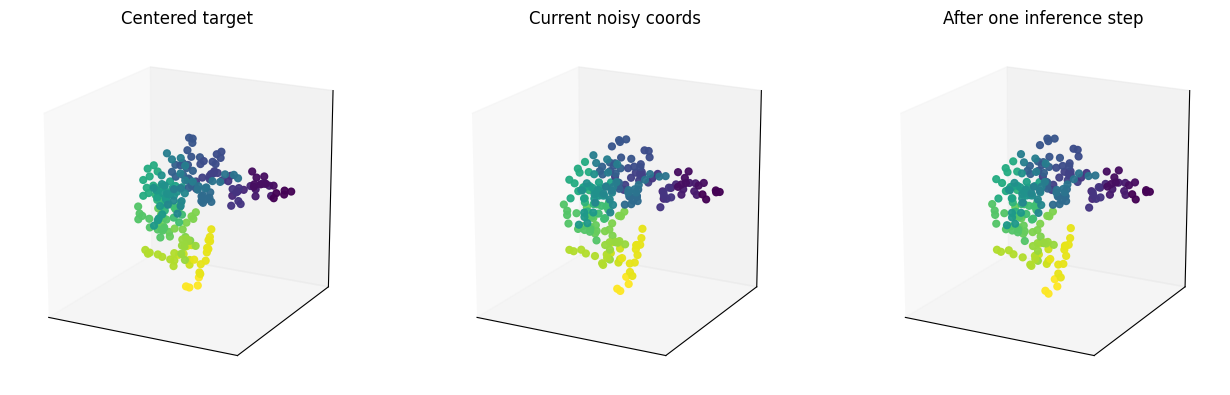

In [210]:
visual_atom_mask = coordinate_atom_mask[0]
target_points = centered_target[0, visual_atom_mask].detach().cpu().numpy()
current_points = current_atom_coords[0, visual_atom_mask].detach().cpu().numpy()
one_step_points = one_step_atom_coords[0, visual_atom_mask].detach().cpu().numpy()
residue_colors = safe_atom_to_token[0, visual_atom_mask].detach().cpu().numpy()
all_visual_points = np.concatenate([target_points, current_points, one_step_points], axis=0)
plot_center = all_visual_points.mean(axis=0)
plot_radius = max(float(np.abs(all_visual_points - plot_center).max()), 1.0)
plot_min = plot_center - plot_radius
plot_max = plot_center + plot_radius
fig = plt.figure(figsize=(13, 4))
for panel, title, points in [
    (1, 'Centered target', target_points),
    (2, 'Current noisy coords', current_points),
    (3, 'After one inference step', one_step_points),
]:
    ax = fig.add_subplot(1, 3, panel, projection='3d')
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], c=residue_colors, cmap='viridis', s=24, alpha=0.95, depthshade=False)
    ax.set_title(title)
    ax.set_xlim(plot_min[0], plot_max[0])
    ax.set_ylim(plot_min[1], plot_max[1])
    ax.set_zlim(plot_min[2], plot_max[2])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_box_aspect([1, 1, 1])
    ax.view_init(elev=18, azim=-62)
plt.tight_layout()


## Conclusion

We've now shown one walkthrough through our diffusion denoiser, how that is used for training, and how it follows the path used to predict structure. At this point if we put [3a_train_foldingcore.ipynb](3a_train_foldingcore.ipynb) and this notebook together, we have a full walkthrough of how the folding model predicts the structure. The predicted coordinates and folding-core features continue into the separate downstream confidence head in [3c_train_confidencehead.ipynb](3c_train_confidencehead.ipynb). 